In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/ravindrasinghrana/job-description-dataset/job_descriptions.csv'):
                                                            
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df= pd.read_csv('/kaggle/input/datasets/ravindrasinghrana/job-description-dataset/job_descriptions.csv')

In [3]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


# CELL 1 — Data Loading & Algerian Localization

In [4]:
# ============================================================
# CELL 1 — DATA LOADING & ALGERIAN LOCALIZATION
# Original: loads dataset, assigns wilayas, converts USD→DZD
# UPDATED: keeps USD→DZD conversion (dataset reference)
#          adds algerian_salary column from market table
# ============================================================
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/ravindrasinghrana/job-description-dataset/job_descriptions.csv')

columns_to_drop = ['Country', 'Contact', 'Job Portal']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# ── Wilayas (unchanged) ──────────────────────────────────
wilayas = [
    ("Adrar", 27.87, -0.29), ("Chlef", 36.16, 1.33), ("Laghouat", 33.80, 2.88),
    ("Oum El Bouaghi", 35.87, 7.11), ("Batna", 35.55, 6.17), ("Béjaïa", 36.75, 5.07),
    ("Biskra", 34.85, 5.73), ("Béchar", 31.62, -2.22), ("Blida", 36.47, 2.83),
    ("Bouira", 36.38, 3.90), ("Tamanrasset", 22.78, 5.52), ("Tébessa", 35.40, 8.12),
    ("Tlemcen", 34.88, -1.32), ("Tiaret", 35.37, 1.32), ("Tizi Ouzou", 36.71, 4.05),
    ("Algiers", 36.75, 3.06), ("Djelfa", 34.67, 3.25), ("Jijel", 36.82, 5.77),
    ("Sétif", 36.19, 5.41), ("Saïda", 34.83, 0.15), ("Skikda", 36.87, 6.91),
    ("Sidi Bel Abbès", 35.19, -0.63), ("Annaba", 36.90, 7.76), ("Guelma", 36.46, 7.43),
    ("Constantine", 36.36, 6.61), ("Médéa", 36.26, 2.75), ("Mostaganem", 35.94, 0.09),
    ("M'Sila", 35.70, 4.54), ("Mascara", 35.40, 0.14), ("Ouargla", 31.95, 5.32),
    ("Oran", 35.70, -0.63), ("El Bayadh", 33.68, 1.02), ("Illizi", 26.48, 8.47),
    ("Bordj Bou Arréridj", 36.07, 4.76), ("Boumerdès", 36.76, 3.47),
    ("El Tarf", 36.77, 8.31), ("Tindouf", 27.67, -8.15), ("Tissemsilt", 35.61, 1.81),
    ("El Oued", 33.37, 6.86), ("Khenchela", 35.43, 7.14), ("Souk Ahras", 36.28, 7.95),
    ("Tipaza", 36.59, 2.45), ("Mila", 36.45, 6.26), ("Aïn Defla", 36.26, 1.97),
    ("Naâma", 33.27, -0.32), ("Aïn Témouchent", 35.30, -1.14),
    ("Ghardaïa", 32.49, 3.67), ("Relizane", 35.73, 0.55),
    ("Timimoun", 29.26, 0.23), ("Bordj Badji Mokhtar", 21.33, 0.95),
    ("Ouled Djellal", 34.42, 5.06), ("Béni Abbès", 30.13, -2.17),
    ("In Salah", 27.20, 2.48), ("In Guezzam", 19.57, 5.77),
    ("Touggourt", 33.10, 6.06), ("Djanet", 24.55, 9.48),
    ("El M'Ghair", 33.95, 5.92), ("El Meniaa", 30.58, 2.88)
]
wilaya_df = pd.DataFrame(wilayas, columns=["location", "latitude", "longitude"])

np.random.seed(42)
random_indices  = np.random.randint(0, len(wilaya_df), size=len(df))
df['location']  = wilaya_df.loc[random_indices, 'location'].values
df['latitude']  = wilaya_df.loc[random_indices, 'latitude'].values
df['longitude'] = wilaya_df.loc[random_indices, 'longitude'].values

# ════════════════════════════════════════════════════════════
# KEPT — Original USD → DZD conversion
# We keep this because it comes from the source dataset
# and is used as a reference column in bias experiments.
# Do NOT remove — downstream cells depend on "Salary Range".
# ════════════════════════════════════════════════════════════
USD_TO_DZD = 132.99

def clean_salary_value(val):
    val = val.replace('$', '').replace(',', '').strip().upper()
    if 'K' in val:
        return float(val.replace('K', '')) * 1000
    return float(val)

def convert_salary_range(salary):
    try:
        if pd.isna(salary):
            return np.nan
        salary_str = str(salary).strip()
        if "DZD" in salary_str:
            return salary_str
        if "-" in salary_str:
            min_val_str, max_val_str = salary_str.split("-")
            min_dzd = int(clean_salary_value(min_val_str) * USD_TO_DZD)
            max_dzd = int(clean_salary_value(max_val_str) * USD_TO_DZD)
            return f"{min_dzd:,} - {max_dzd:,} DZD"
        else:
            value_dzd = int(clean_salary_value(salary_str) * USD_TO_DZD)
            return f"{value_dzd:,} DZD"
    except Exception:
        return salary

df["Salary Range"] = df["Salary Range"].apply(convert_salary_range)

def parse_min_salary_numeric(s):
    try:
        if pd.isna(s):
            return np.nan
        first_part = str(s).split('-')[0].replace(',','').replace('DZD','').strip()
        return float(first_part)
    except Exception:
        return np.nan

df["Min Salary DZD"] = df["Salary Range"].apply(parse_min_salary_numeric)

# ════════════════════════════════════════════════════════════
# NEW — Algerian Market Salary Table
# Real DZD values based on Algerian job market.
# Stored here so Cell 6.5 can apply them to the dataframe.
# Unit: DZD per MONTH
# ════════════════════════════════════════════════════════════
SNMG_DZD = 20_000   # legal minimum wage Algeria 2024

ALGERIAN_SALARY_TABLE = {
    # Technology & IT
    "software engineer":         {"min": 60_000,  "max": 180_000, "avg": 110_000},
    "software developer":        {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "web developer":             {"min": 40_000,  "max": 120_000, "avg":  75_000},
    "frontend developer":        {"min": 40_000,  "max": 110_000, "avg":  70_000},
    "backend developer":         {"min": 50_000,  "max": 130_000, "avg":  85_000},
    "fullstack developer":       {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "mobile developer":          {"min": 50_000,  "max": 140_000, "avg":  90_000},
    "data scientist":            {"min": 70_000,  "max": 200_000, "avg": 130_000},
    "data analyst":              {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "data engineer":             {"min": 65_000,  "max": 180_000, "avg": 115_000},
    "machine learning engineer": {"min": 75_000,  "max": 210_000, "avg": 140_000},
    "devops engineer":           {"min": 70_000,  "max": 190_000, "avg": 125_000},
    "cybersecurity engineer":    {"min": 75_000,  "max": 200_000, "avg": 130_000},
    "network engineer":          {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "system administrator":      {"min": 50_000,  "max": 130_000, "avg":  85_000},
    "it support":                {"min": 30_000,  "max":  70_000, "avg":  48_000},
    "ui ux designer":            {"min": 45_000,  "max": 120_000, "avg":  75_000},
    "database administrator":    {"min": 60_000,  "max": 160_000, "avg": 105_000},
    "cloud engineer":            {"min": 70_000,  "max": 200_000, "avg": 130_000},
    "it manager":                {"min": 90_000,  "max": 250_000, "avg": 160_000},
    "programmer":                {"min": 45_000,  "max": 130_000, "avg":  80_000},
    "developer":                 {"min": 45_000,  "max": 140_000, "avg":  85_000},

    # Finance & Accounting
    "accountant":                {"min": 35_000,  "max": 100_000, "avg":  60_000},
    "senior accountant":         {"min": 60_000,  "max": 150_000, "avg":  95_000},
    "financial analyst":         {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "finance manager":           {"min": 90_000,  "max": 250_000, "avg": 160_000},
    "auditor":                   {"min": 50_000,  "max": 140_000, "avg":  88_000},
    "tax consultant":            {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "bank teller":               {"min": 28_000,  "max":  60_000, "avg":  40_000},
    "bank officer":              {"min": 50_000,  "max": 130_000, "avg":  80_000},
    "controller":                {"min": 70_000,  "max": 180_000, "avg": 115_000},

    # Engineering
    "civil engineer":            {"min": 55_000,  "max": 170_000, "avg": 105_000},
    "mechanical engineer":       {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "electrical engineer":       {"min": 60_000,  "max": 175_000, "avg": 110_000},
    "chemical engineer":         {"min": 60_000,  "max": 170_000, "avg": 108_000},
    "petroleum engineer":        {"min": 90_000,  "max": 350_000, "avg": 200_000},
    "architect":                 {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "project manager":           {"min": 80_000,  "max": 250_000, "avg": 155_000},
    "engineer":                  {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "technician":                {"min": 30_000,  "max":  90_000, "avg":  55_000},
    "industrial engineer":       {"min": 60_000,  "max": 170_000, "avg": 108_000},

    # Healthcare
    "doctor":                    {"min": 80_000,  "max": 300_000, "avg": 170_000},
    "general practitioner":      {"min": 80_000,  "max": 250_000, "avg": 155_000},
    "pharmacist":                {"min": 65_000,  "max": 180_000, "avg": 115_000},
    "nurse":                     {"min": 28_000,  "max":  80_000, "avg":  50_000},
    "dentist":                   {"min": 90_000,  "max": 280_000, "avg": 170_000},
    "medical":                   {"min": 60_000,  "max": 200_000, "avg": 120_000},

    # Education
    "teacher":                   {"min": 28_000,  "max":  75_000, "avg":  45_000},
    "university professor":      {"min": 55_000,  "max": 160_000, "avg":  95_000},
    "professor":                 {"min": 55_000,  "max": 160_000, "avg":  95_000},
    "trainer":                   {"min": 35_000,  "max":  90_000, "avg":  58_000},
    "instructor":                {"min": 35_000,  "max":  90_000, "avg":  55_000},

    # Business & Management
    "marketing manager":         {"min": 70_000,  "max": 200_000, "avg": 125_000},
    "marketing specialist":      {"min": 40_000,  "max": 100_000, "avg":  65_000},
    "sales manager":             {"min": 70_000,  "max": 220_000, "avg": 130_000},
    "sales representative":      {"min": 30_000,  "max":  80_000, "avg":  50_000},
    "hr manager":                {"min": 70_000,  "max": 200_000, "avg": 125_000},
    "hr specialist":             {"min": 40_000,  "max": 100_000, "avg":  65_000},
    "business analyst":          {"min": 60_000,  "max": 170_000, "avg": 108_000},
    "operations manager":        {"min": 80_000,  "max": 230_000, "avg": 148_000},
    "supply chain manager":      {"min": 75_000,  "max": 210_000, "avg": 135_000},
    "logistics coordinator":     {"min": 40_000,  "max": 100_000, "avg":  65_000},
    "manager":                   {"min": 70_000,  "max": 220_000, "avg": 130_000},
    "director":                  {"min": 120_000, "max": 400_000, "avg": 220_000},
    "consultant":                {"min": 60_000,  "max": 200_000, "avg": 115_000},

    # Legal
    "lawyer":                    {"min": 60_000,  "max": 250_000, "avg": 130_000},
    "legal advisor":             {"min": 65_000,  "max": 200_000, "avg": 120_000},
    "notary":                    {"min": 80_000,  "max": 280_000, "avg": 160_000},

    # Trades
    "electrician":               {"min": 28_000,  "max":  80_000, "avg":  50_000},
    "plumber":                   {"min": 25_000,  "max":  70_000, "avg":  45_000},
    "welder":                    {"min": 30_000,  "max":  85_000, "avg":  52_000},
    "mechanic":                  {"min": 28_000,  "max":  75_000, "avg":  48_000},

    # Entry level
    "administrative assistant":  {"min": 25_000,  "max":  60_000, "avg":  38_000},
    "receptionist":              {"min": 22_000,  "max":  50_000, "avg":  33_000},
    "driver":                    {"min": 22_000,  "max":  55_000, "avg":  35_000},
    "security guard":            {"min": 22_000,  "max":  45_000, "avg":  30_000},
    "customer service":          {"min": 25_000,  "max":  65_000, "avg":  42_000},
    "intern":                    {"min": 15_000,  "max":  30_000, "avg":  20_000},
    "fresh graduate":            {"min": 25_000,  "max":  45_000, "avg":  33_000},
    "analyst":                   {"min": 45_000,  "max": 130_000, "avg":  80_000},
    "coordinator":               {"min": 35_000,  "max":  90_000, "avg":  58_000},
    "specialist":                {"min": 40_000,  "max": 120_000, "avg":  72_000},
    "assistant":                 {"min": 25_000,  "max":  65_000, "avg":  40_000},
    "officer":                   {"min": 35_000,  "max": 100_000, "avg":  60_000},
    "supervisor":                {"min": 45_000,  "max": 130_000, "avg":  80_000},
    "executive":                 {"min": 80_000,  "max": 280_000, "avg": 160_000},
}

EXPERIENCE_MULTIPLIER = {
    "0-1 years":   0.80,
    "1-2 years":   0.90,
    "2-4 years":   1.00,
    "4-6 years":   1.20,
    "6-9 years":   1.40,
    "9-12 years":  1.60,
    "12-15 years": 1.80,
    "15+ years":   2.00,
}

WILAYA_MULTIPLIER = {
    "Algiers":     1.25,
    "Oran":        1.15,
    "Constantine": 1.10,
    "Annaba":      1.08,
    "Sétif":       1.05,
    "Blida":       1.05,
    "Batna":       1.00,
    "Tizi Ouzou":  1.00,
    "Béjaïa":      1.00,
    "Skikda":      1.00,
    "Tlemcen":     0.98,
    "Mostaganem":  0.97,
    "Ouargla":     0.95,
    "Ghardaïa":    0.92,
    "Adrar":       0.90,
    "Tamanrasset": 0.90,
    "Tindouf":     0.88,
    "Illizi":      0.88,
    "In Salah":    0.88,
    "Djanet":      0.88,
}
DEFAULT_WILAYA_MULT = 0.95


def get_algerian_salary(job_title: str,
                        experience: str = "2-4 years",
                        wilaya: str = "Algiers") -> dict:
    """
    Returns realistic Algerian market salary for a job title.
    Applies experience and wilaya multipliers.
    Always respects SNMG floor (20,000 DZD).
    """
    title_lower = str(job_title).lower().strip()

    # Step 1: exact match
    base = ALGERIAN_SALARY_TABLE.get(title_lower)

    # Step 2: partial match — find first key contained in title or vice versa
    if not base:
        for key, val in ALGERIAN_SALARY_TABLE.items():
            if key in title_lower or title_lower in key:
                base = val
                break

    # Step 3: word-by-word match — match any word in the title
    if not base:
        title_words = title_lower.split()
        for key, val in ALGERIAN_SALARY_TABLE.items():
            if any(word in key for word in title_words):
                base = val
                break

    # Step 4: fallback — generic estimate
    source = "market_table" if base else "estimated"
    if not base:
        base = {"min": 30_000, "max": 90_000, "avg": 55_000}

    exp_mult = EXPERIENCE_MULTIPLIER.get(experience, 1.0)
    wil_mult = WILAYA_MULTIPLIER.get(wilaya, DEFAULT_WILAYA_MULT)
    mult     = exp_mult * wil_mult

    min_dzd = max(int(base["min"] * mult), SNMG_DZD)
    max_dzd = max(int(base["max"] * mult), SNMG_DZD)
    avg_dzd = max(int(base["avg"] * mult), SNMG_DZD)

    return {
        "min_dzd":        min_dzd,
        "max_dzd":        max_dzd,
        "avg_dzd":        avg_dzd,
        "formatted":      f"{min_dzd:,} - {max_dzd:,} DZD/month",
        "source":         source,
        "snmg_compliant": min_dzd >= SNMG_DZD,
    }


df.to_csv('/kaggle/working/algerian_jobs_final.csv', index=False)

print("Sample converted salary ranges (original dataset):")
print(df[["Salary Range", "Min Salary DZD"]].head(5))
print("\nSample Algerian market salary lookup:")
for title, exp, wil in [
    ("Software Engineer", "4-6 years",  "Algiers"),
    ("Data Scientist",    "2-4 years",  "Oran"),
    ("Teacher",           "0-1 years",  "Batna"),
    ("Nurse",             "6-9 years",  "Constantine"),
    ("Driver",            "2-4 years",  "Adrar"),
]:
    r = get_algerian_salary(title, exp, wil)
    print(f"  {title:<28} {exp:<12} {wil:<14} → {r['formatted']}")
print("\nDone! Shape:", df.shape)

Sample converted salary ranges (original dataset):
                 Salary Range  Min Salary DZD
0  7,846,410 - 13,166,010 DZD       7846410.0
1  7,447,440 - 15,426,840 DZD       7447440.0
2  8,112,390 - 13,830,960 DZD       8112390.0
3  8,644,350 - 12,102,090 DZD       8644350.0
4  8,511,360 - 11,570,130 DZD       8511360.0

Sample Algerian market salary lookup:
  Software Engineer            4-6 years    Algiers        → 90,000 - 270,000 DZD/month
  Data Scientist               2-4 years    Oran           → 80,500 - 229,999 DZD/month
  Teacher                      0-1 years    Batna          → 22,400 - 60,000 DZD/month
  Nurse                        6-9 years    Constantine    → 43,120 - 123,200 DZD/month
  Driver                       2-4 years    Adrar          → 20,000 - 49,500 DZD/month

Done! Shape: (1615940, 21)


In [5]:
print(df.columns)

Index(['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location',
       'latitude', 'longitude', 'Work Type', 'Company Size',
       'Job Posting Date', 'Preference', 'Contact Person', 'Job Title', 'Role',
       'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company',
       'Company Profile', 'Min Salary DZD'],
      dtype='object')


# CELL 2 — NLP Preprocessing FIX: separate LabelEncoder per column; job_text_clean built here so Cell 8 can use it immediately


In [6]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('/kaggle/working/algerian_jobs_final.csv')
# ---- TOKENIZATION ----
def tokenize_text(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    return re.findall(r'\b[a-zA-Z]+\b', text)
text_columns = ['Job Description', 'Job Title', 'skills', 'Responsibilities']
for col in text_columns:
    if col in df.columns:
        df[f'{col}_tokens'] = df[col].apply(tokenize_text)
print("Tokenization done")
# ---- STOP WORD REMOVAL ----
STOP_WORDS = {
    "a","an","the","and","or","but","in","on","at","to","for","of","with","by",
    "from","is","are","was","were","be","been","being","have","has","had","do",
    "does","did","will","would","could","should","may","might","shall","can",
    "need","dare","it","its","this","that","these","those","i","we","you","he",
    "she","they","me","us","him","her","them","my","our","your","his","their",
    "what","which","who","whom","when","where","why","how","all","each","every",
    "both","few","more","most","other","some","such","no","not","only","same",
    "so","than","too","very","just","as","if","then","because","while","about",
    "above","after","before","between","into","through","during","also","any",
    "up","out","over","under","again"
}
def remove_stopwords(tokens):
    if not isinstance(tokens, list):
        return []
    return [t for t in tokens if t not in STOP_WORDS]
for col in text_columns:
    token_col = f'{col}_tokens'
    if token_col in df.columns:
        df[f'{col}_clean'] = df[token_col].apply(remove_stopwords)
print("Stop word removal done")
# ---- NORMALIZATION ----
synonym_map = {
    "ba":"bachelors","b.a":"bachelors","bs":"bachelors","b.s":"bachelors",
    "bsc":"bachelors","bachelor":"bachelors","ma":"masters","m.a":"masters",
    "ms":"masters","m.s":"masters","msc":"masters","master":"masters",
    "mba":"masters_business","phd":"doctorate","ph.d":"doctorate",
    "yrs":"years","yr":"years","exp":"experience",
    "js":"javascript","py":"python","ml":"machine_learning",
    "ai":"artificial_intelligence","dl":"deep_learning",
    "nlp":"natural_language_processing","cv":"computer_vision","db":"database",
    "sr":"senior","jr":"junior","mgr":"manager","dev":"developer","eng":"engineer",
}
def normalize_tokens(tokens):
    if not isinstance(tokens, list):
        return []
    return [synonym_map.get(t, t) for t in tokens]
for col in text_columns:
    clean_col = f'{col}_clean'
    if clean_col in df.columns:
        df[f'{col}_normalized'] = df[clean_col].apply(normalize_tokens)
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()
print("Normalization done")
# ---- LABEL ENCODING ----
# FIX: one LabelEncoder per column — avoids state overwrite
label_encoders     = {}
categorical_columns = ['Job Title','Experience','Qualifications',
                        'Work Type','location','Role','skills']
for col in categorical_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str).str.lower().str.strip()
        df[f'{col}_encoded'] = le.fit_transform(df[col].fillna('unknown'))
        label_encoders[col]  = le
        print(f"  -> '{col}' encoded into {df[col].nunique()} classes")
print(f"\nLabel encoding done — {len(label_encoders)} columns encoded")
# ---- BUILD job_text_clean HERE ----
# FIX: built in Cell 2 so every downstream cell can use it
def build_job_text(row):
    parts = []
    for col in ['Job Title','Role','skills','Job Description',
                'Responsibilities','Qualifications','Experience']:
        if col in row and pd.notna(row[col]):
            parts.append(str(row[col]))
    return " ".join(parts).lower().strip()
print("Building job_text_clean ...")
df['job_text_clean'] = df.apply(build_job_text, axis=1)
df.to_csv('/kaggle/working/algerian_jobs_nlp.csv', index=False)
print(f"\nNLP preprocessing complete! Shape: {df.shape}")

Tokenization done
Stop word removal done
Normalization done
  -> 'Job Title' encoded into 147 classes
  -> 'Experience' encoded into 48 classes
  -> 'Qualifications' encoded into 10 classes
  -> 'Work Type' encoded into 5 classes
  -> 'location' encoded into 58 classes
  -> 'Role' encoded into 376 classes
  -> 'skills' encoded into 376 classes

Label encoding done — 7 columns encoded
Building job_text_clean ...

NLP preprocessing complete! Shape: (1615940, 41)


# CELL 3 — Synthetic User Profiles FIX: np.random.uniform used throughout (not mixed with random.uniform); bias injection clearly labelled as Layer 1 only


In [7]:
import pandas as pd
import numpy as np
import random

df_jobs = pd.read_csv('/kaggle/working/algerian_jobs_nlp.csv')

# FIX: consistent RNG — np.random for all numerical noise
random.seed(42)
np.random.seed(42)

arabic_male_names   = ["Mohamed","Ahmed","Youcef","Abdelkader","Rachid","Karim","Nabil","Sofiane","Hamza","Amine","Bilal","Walid","Tarek","Hichem","Khaled"]
arabic_female_names = ["Khaoula","Houyam","Fedoua","Ghada","Bouthayna","Asma","Fatima","Amina","Samira","Nadia","Houria","Meriem","Asma","Sabrina","Yasmine","Rima","Dalila","Wafa","Naima","Karima","Zineb"]
french_male_names   = ["Thomas","Kevin","Pierre","Lucas","Nicolas","Julien","Antoine","Baptiste","Romain","Maxime"]
french_female_names = ["Marie","Sophie","Camille","Julie","Léa","Manon","Lucie","Chloé","Emma","Clara"]
berber_male_names   = ["Massinissa","Jugurtha","Takfarinas","Amayas","Idir","Arezki","Lounès","Ferhat","Meziane","Tiziri"]
berber_female_names = ["Tafat","Tiziri","Thiziri","Massilia","Tinhinan","Dihya","Tanina","Gaia","Lylia","Zina"]
last_names = ["Benali","Boudiaf","Cherif","Hadj","Mansouri","Belkacem","Ouali","Brahim","Saadi","Meziane","Kaci","Ait Ahmed","Hamidi","Taleb","Zerrouk","Martin","Bernard","Dubois","Laurent","Simon"]

wilayas = [
    ("Adrar",27.87,-0.29),("Chlef",36.16,1.33),("Laghouat",33.80,2.88),
    ("Batna",35.55,6.17),("Béjaïa",36.75,5.07),("Blida",36.47,2.83),
    ("Tamanrasset",22.78,5.52),("Tlemcen",34.88,-1.32),("Tizi Ouzou",36.71,4.05),
    ("Algiers",36.75,3.06),("Sétif",36.19,5.41),("Skikda",36.87,6.91),
    ("Annaba",36.90,7.76),("Constantine",36.36,6.61),("Oran",35.70,-0.63),
    ("Tindouf",27.67,-8.15),("El Oued",33.37,6.86),("Tipaza",36.59,2.45),
    ("Ghardaïa",32.49,3.67),("Relizane",35.73,0.55)
]
urban_wilayas = ["Algiers","Oran","Constantine","Annaba","Sétif",
                 "Blida","Batna","Tizi Ouzou","Béjaïa","Skikda"]

education_levels = ["bachelors","masters","doctorate","high_school","bts","licence"]
education_fields = [
    "computer science","information technology","software engineering",
    "data science","business administration","finance","marketing",
    "electrical engineering","civil engineering","accounting",
    "human resources","law","medicine","biology","mathematics"
]
experience_levels = ["0-1 years","1-2 years","2-4 years","4-6 years",
                     "6-9 years","9-12 years","12-15 years","15+ years"]

real_skills  = df_jobs['skills'].dropna().unique().tolist()
real_titles  = df_jobs['Job Title'].dropna().unique().tolist()
real_roles   = df_jobs['Role'].dropna().unique().tolist()

def assign_name_origin(gender):
    origin = random.choices(["arabic","french","berber"], weights=[0.65,0.20,0.15])[0]
    if gender == "Male":
        pool = {"arabic":arabic_male_names,"french":french_male_names,"berber":berber_male_names}[origin]
    else:
        pool = {"arabic":arabic_female_names,"french":french_female_names,"berber":berber_female_names}[origin]
    return random.choice(pool), random.choice(last_names), origin

def assign_wilaya():
    if random.random() < 0.45:
        name = random.choice(urban_wilayas)
        w    = next(x for x in wilayas if x[0] == name)
    else:
        w = random.choice(wilayas)
    return w[0], w[1], w[2], w[0] in urban_wilayas

def generate_base_score(experience, education, skills_match):
    exp_map = {"0-1 years":10,"1-2 years":20,"2-4 years":35,"4-6 years":50,
               "6-9 years":62,"9-12 years":72,"12-15 years":82,"15+ years":88}
    edu_map = {"high_school":5,"bts":10,"licence":15,
               "bachelors":20,"masters":28,"doctorate":32}
    base  = exp_map.get(experience,30) + edu_map.get(education,15) + (skills_match * 20)
    # FIX: np.random for full reproducibility
    noise = np.random.normal(0, 8)
    return round(min(max(base + noise, 10), 100), 2)

def inject_profile_bias(score, gender, name_origin, is_urban, job_title):
    """
    LAYER 1 bias — applied to synthetic profile scores only.
    Separate from Layer 2 (TF-IDF recommendation bias in Cell 6).
    Do not conflate in analysis.
    """
    biased = score
    tech_roles = ["engineer","developer","programmer","architect","devops"]
    is_tech    = any(t in str(job_title).lower() for t in tech_roles)

    # FIX: np.random.uniform throughout
    if gender == "Female" and is_tech:
        biased -= np.random.uniform(2, 7)
    elif gender == "Male":
        biased += np.random.uniform(0, 2)

    if name_origin == "french":
        biased += np.random.uniform(1, 4)
    elif name_origin == "berber":
        biased -= np.random.uniform(0, 3)

    if not is_urban:
        biased -= np.random.uniform(1, 5)

    return round(min(max(biased, 5), 100), 2)

N = 10000
profiles = []
for i in range(N):
    gender          = random.choice(["Male","Female"])
    age             = random.randint(21, 55)
    first_name, last_name, name_origin = assign_name_origin(gender)
    wilaya, lat, lon, is_urban         = assign_wilaya()
    education       = random.choice(education_levels)
    education_field = random.choice(education_fields)
    experience      = random.choice(experience_levels)
    target_title    = random.choice(real_titles[:100])
    target_role     = random.choice(real_roles[:100])
    skills          = random.choice(real_skills[:200])
    skills_match    = random.randint(0, 3) / 3
    base_score      = generate_base_score(experience, education, skills_match)
    biased_score    = inject_profile_bias(base_score, gender, name_origin, is_urban, target_title)

    profiles.append({
        "profile_id":       f"PRF_{i:06d}",
        "first_name":       first_name,
        "last_name":        last_name,
        "masked_name":      f"Candidate_{i:05d}",
        "gender":           gender,
        "masked_gender":    "Not Disclosed",
        "age":              age,
        "name_origin":      name_origin,
        "wilaya":           wilaya,
        "latitude":         lat,
        "longitude":        lon,
        "is_urban":         is_urban,
        "masked_location":  "Location_X",
        "education_level":  education,
        "education_field":  education_field,
        "experience":       experience,
        "skills":           skills,
        "skills_match":     round(skills_match, 2),
        "target_job_title": target_title,
        "target_role":      target_role,
        "base_score":       base_score,
        "biased_score":     biased_score,
        "score_delta":      round(biased_score - base_score, 2),
        "hired_biased":     int(biased_score >= 60),
        "hired_unbiased":   int(base_score >= 60),
        "decision_changed": int(int(biased_score >= 60) != int(base_score >= 60))
    })

df_profiles = pd.DataFrame(profiles)

print("=" * 50)
print("BIAS AUDIT SUMMARY")
print("=" * 50)
print("\nAverage score by Gender:")
print(df_profiles.groupby("gender")[["base_score","biased_score"]].mean().round(2))
print("\nAverage score by Name Origin:")
print(df_profiles.groupby("name_origin")[["base_score","biased_score"]].mean().round(2))
print("\nAverage score Urban vs Rural:")
print(df_profiles.groupby("is_urban")[["base_score","biased_score"]].mean().round(2))

flipped = df_profiles[df_profiles["decision_changed"] == 1]
print(f"\nDecisions flipped: {len(flipped)} / {N} ({len(flipped)/N*100:.1f}%)")

df_profiles.to_csv('/kaggle/working/user_profiles.csv', index=False)
print(f"\nSaved {N} profiles. Shape: {df_profiles.shape}")

BIAS AUDIT SUMMARY

Average score by Gender:
        base_score  biased_score
gender                          
Female       75.24         73.67
Male         75.98         76.10

Average score by Name Origin:
             base_score  biased_score
name_origin                          
arabic            75.58         74.65
berber            76.28         74.08
french            75.25         76.30

Average score Urban vs Rural:
          base_score  biased_score
is_urban                          
False          74.93         72.23
True           75.88         75.93

Decisions flipped: 182 / 10000 (1.8%)

Saved 10000 profiles. Shape: (10000, 26)


# CELL 4 — Dynamic ANEM FAQ Generator FIX: O(1) duplicate check using a set 

In [8]:
import pandas as pd
import json
import random
import itertools

df_jobs     = pd.read_csv('/kaggle/working/algerian_jobs_nlp.csv')
df_profiles = pd.read_csv('/kaggle/working/user_profiles.csv')

wilayas           = df_profiles['wilaya'].unique().tolist()
job_titles        = df_jobs['Job Title'].dropna().unique().tolist()[:100]
skills            = df_jobs['skills'].dropna().unique().tolist()[:100]
experience_levels = df_profiles['experience'].unique().tolist()
education_levels  = df_profiles['education_level'].unique().tolist()

degrees        = ["licence","master","doctorat","BTS","ingéniorat","DUT"]
statuses       = ["primo-demandeur","licencié économique","démissionnaire",
                  "étudiant diplômé","travailleur indépendant","femme au foyer"]
contract_types = ["CDI","CDD","temps partiel","stage","CPE","DAIP"]

templates = {
    "registration": {"templates_fr": [
        ("Comment s'inscrire à l'ANEM à {wilaya} ?",
         "Pour s'inscrire à l'ANEM à {wilaya}, rendez-vous à l'agence locale avec: "
         "votre CIN, justificatif de domicile, diplôme ({degree}), CV, et photo. "
         "L'inscription est gratuite."),
        ("Quels documents fournir si j'ai un {degree} pour m'inscrire à l'ANEM ?",
         "Avec un {degree}, vous devez fournir: attestation de réussite originale, "
         "copie CIN, justificatif de domicile, CV, et photo d'identité."),
        ("Puis-je m'inscrire à l'ANEM si je suis {status} ?",
         "Oui, les personnes avec le statut '{status}' peuvent s'inscrire à l'ANEM. "
         "Apportez un justificatif de votre situation actuelle."),
        ("L'ANEM de {wilaya} est-elle ouverte le vendredi ?",
         "Les agences ANEM sont ouvertes du dimanche au jeudi de 8h à 16h30. "
         "Fermées les vendredis, samedis et jours fériés."),
        ("Combien de temps prend l'inscription à l'ANEM à {wilaya} ?",
         "L'inscription à l'ANEM de {wilaya} prend entre 30 minutes et 2 heures."),
    ]},
    "job_search": {"templates_fr": [
        ("Comment trouver un emploi de {job_title} à {wilaya} via l'ANEM ?",
         "Pour trouver un poste de {job_title} à {wilaya}: 1) Inscrivez-vous à l'ANEM, "
         "2) Précisez votre spécialité, 3) Consultez anem.dz."),
        ("Y a-t-il des offres pour {job_title} en contrat {contract_type} à {wilaya} ?",
         "L'ANEM de {wilaya} reçoit régulièrement des offres pour {job_title} en {contract_type}. "
         "Offres mises à jour hebdomadairement sur anem.dz."),
        ("Mon profil {job_title} avec {experience} est-il demandé à {wilaya} ?",
         "Les profils {job_title} avec {experience} sont recherchés dans plusieurs wilayas dont {wilaya}."),
        ("Puis-je chercher un emploi dans une autre wilaya via l'ANEM de {wilaya} ?",
         "Oui, l'ANEM de {wilaya} a accès à la base d'offres nationale. "
         "Des aides au déplacement peuvent être disponibles."),
        ("Comment fonctionne le matching de profil pour un poste de {job_title} ?",
         "L'ANEM utilise votre profil pour proposer des offres de {job_title}. "
         "Mettez à jour vos compétences en {skill} pour augmenter vos chances."),
    ]},
    "unemployment_benefits": {"templates_fr": [
        ("Puis-je toucher les allocations chômage après avoir quitté un poste de {job_title} ?",
         "Les allocations CNAC ne s'appliquent qu'en cas de licenciement économique, "
         "pas de démission. Conditions: 3+ ans cotisation CNAS, âge 30-50 ans."),
        ("Quel est le montant des allocations chômage pour un {job_title} ?",
         "Le montant varie entre 75% et 100% du SNMG (20 000 DA). "
         "Le calcul est identique quel que soit le poste."),
        ("Comment renouveler mes allocations chômage à {wilaya} ?",
         "Pour renouveler à {wilaya}: présentez-vous au CNAC avant expiration "
         "et justifiez vos démarches de recherche d'emploi. Renouvellement semestriel."),
    ]},
    "youth_programs": {"templates_fr": [
        ("Le dispositif CPE est-il disponible pour un {degree} à {wilaya} ?",
         "Oui, le CPE est disponible pour les titulaires d'un {degree} à {wilaya}. "
         "Conditions: primo-demandeur, moins de 35 ans. L'État prend en charge 80%."),
        ("Comment bénéficier de l'ANSEJ avec un projet dans le domaine {job_title} ?",
         "Pour créer une entreprise dans {job_title} via l'ANSEJ: préparez votre business plan, "
         "déposez votre dossier. Conditions: 18-35 ans, projet viable."),
        ("Quelle est la différence entre DAIP et CPE pour un diplômé {degree} ?",
         "Pour un {degree}: le DAIP est un contrat d'insertion généraliste (12 mois), "
         "le CPE cible les diplômés universitaires avec meilleure rémunération."),
        ("Y a-t-il des programmes pour les jeunes de {wilaya} sans expérience ?",
         "Oui: DAIP, ESIL (emploi de solidarité), et formations INFP gratuites à {wilaya}."),
    ]},
    "discrimination": {"templates_fr": [
        ("Que faire si je suis refusé à cause de ma wilaya d'origine ({wilaya}) ?",
         "La discrimination basée sur la wilaya est illégale. Conservez les preuves, "
         "signalez à l'ANEM et déposez plainte à l'Inspection du Travail."),
        ("Une entreprise peut-elle refuser une femme pour le poste de {job_title} ?",
         "Non, refuser une femme pour {job_title} en raison de son genre est illégal. "
         "Signalez à l'ANEM et à l'Inspection du Travail. Conservez tout échange écrit."),
        ("Le recrutement IA peut-il discriminer selon le nom ou la wilaya ?",
         "C'est un risque réel. Si vous suspectez un biais algorithmique, "
         "demandez une révision humaine de votre dossier auprès de l'employeur."),
        ("Mon nom peut-il influencer négativement ma candidature pour {job_title} ?",
         "Légalement non, mais des biais existent en pratique. "
         "Concentrez-vous sur vos compétences en {skill}."),
        ("Comment prouver une discrimination à l'embauche à {wilaya} ?",
         "Pour prouver une discrimination à {wilaya}: conservez les refus écrits, "
         "cherchez des témoins, déposez plainte à l'Inspection du Travail. "
         "Délai de prescription: 3 ans."),
    ]},
    "salary_rights": {"templates_fr": [
        ("Quel est le salaire moyen pour un {job_title} à {wilaya} ?",
         "Le salaire d'un {job_title} à {wilaya} varie selon l'expérience. "
         "Avec {experience}, la fourchette se situe entre 45 000 et 120 000 DZD."),
        ("Le SNMG s'applique-t-il aux contrats {contract_type} ?",
         "Oui, le SNMG (20 000 DZD) s'applique à tous les contrats {contract_type}. "
         "En cas de non-respect, signalez à l'Inspection du Travail."),
        ("Mes compétences en {skill} justifient-elles un salaire supérieur au SNMG ?",
         "Les compétences spécialisées comme {skill} justifient généralement "
         "une rémunération supérieure au SNMG."),
    ]},
    "training": {"templates_fr": [
        ("Quelles formations sont disponibles pour améliorer mes compétences en {skill} ?",
         "L'ANEM via l'INFP propose des formations en {skill}, gratuites pour les demandeurs "
         "d'emploi inscrits. Durée: 3 à 6 mois."),
        ("Comment passer d'un {degree} à une formation plus spécialisée via l'ANEM ?",
         "Avec un {degree}, vous pouvez accéder aux formations INFP de perfectionnement. "
         "Des formations courtes certifiantes sont disponibles en {skill}."),
        ("Y a-t-il des formations en ligne disponibles via l'ANEM à {wilaya} ?",
         "Certaines formations en {skill} sont disponibles en e-learning sur anem.dz. "
         "La majorité des certifiantes nécessite encore une présence physique."),
    ]},
}

def generate_faq(n_per_category=30, seed=42):
    random.seed(seed)
    faq_entries    = []
    # FIX: O(1) duplicate check with set instead of list scan
    seen_questions = set()
    entry_id       = 1

    for category, content in templates.items():
        tmpl_list = content["templates_fr"]
        count     = 0

        for tmpl_q, tmpl_a in itertools.cycle(tmpl_list):
            if count >= n_per_category:
                break
            fill = {
                "wilaya":        random.choice(wilayas),
                "job_title":     random.choice(job_titles),
                "degree":        random.choice(degrees),
                "status":        random.choice(statuses),
                "contract_type": random.choice(contract_types),
                "experience":    random.choice(experience_levels),
                "skill":         random.choice(skills),
            }
            try:
                question = tmpl_q.format(**fill)
                answer   = tmpl_a.format(**fill)
            except KeyError:
                continue

            if question in seen_questions:
                continue

            seen_questions.add(question)
            faq_entries.append({
                "id":        f"FAQ_{entry_id:04d}",
                "category":  category,
                "question":  question,
                "answer":    answer,
                "wilaya":    fill["wilaya"],
                "job_title": fill["job_title"],
                "keywords":  [fill["wilaya"], fill["job_title"], fill["skill"], category]
            })
            entry_id += 1
            count    += 1

    return faq_entries

N_PER_CATEGORY = 30
faq_generated  = generate_faq(n_per_category=N_PER_CATEGORY)
df_faq_dynamic = pd.DataFrame(faq_generated)

df_faq_dynamic.to_csv('/kaggle/working/anem_faq_dynamic.csv', index=False)
with open('/kaggle/working/anem_faq_dynamic.json', 'w', encoding='utf-8') as f:
    json.dump(faq_generated, f, ensure_ascii=False, indent=2)

print(f"Total entries: {len(df_faq_dynamic)}")
for cat, count in df_faq_dynamic['category'].value_counts().items():
    print(f"  {cat:<30} {count}")
print(f"\nUnique wilayas: {df_faq_dynamic['wilaya'].nunique()}")
print(f"Files saved: anem_faq_dynamic.csv / .json")

Total entries: 210
  registration                   30
  job_search                     30
  unemployment_benefits          30
  youth_programs                 30
  discrimination                 30
  salary_rights                  30
  training                       30

Unique wilayas: 20
Files saved: anem_faq_dynamic.csv / .json


# CELL 5 — User Accounts & Interactions FIX: iterrows replaced with bulk array generation

In [9]:
import pandas as pd
import numpy as np
import random
import hashlib
from datetime import datetime, timedelta

df_profiles = pd.read_csv('/kaggle/working/user_profiles.csv')
df_jobs     = pd.read_csv('/kaggle/working/algerian_jobs_nlp.csv')
df_faq      = pd.read_csv('/kaggle/working/anem_faq_dynamic.csv')

random.seed(42)
np.random.seed(42)

def generate_password_hash(password):
    # NOTE: demo only — never store hashes in plain CSV in production
    return hashlib.sha256(password.encode()).hexdigest()[:32]

def random_date(start_year=2020, end_year=2024):
    start = datetime(start_year, 1, 1)
    end   = datetime(end_year, 12, 31)
    delta = end - start
    return (start + timedelta(days=random.randint(0, delta.days))).strftime('%Y-%m-%d')

account_types  = ["job_seeker","employer","advisor"]
account_status = ["active","inactive","suspended"]
type_weights   = [0.80, 0.15, 0.05]
status_weights = [0.75, 0.20, 0.05]
email_domains  = ["gmail.com","yahoo.fr","hotmail.com","outlook.com","esi.dz"]

n = len(df_profiles)
# FIX: generate all account types and statuses in bulk — no iterrows
account_type_arr = random.choices(account_types, weights=type_weights, k=n)
status_arr       = random.choices(account_status, weights=status_weights, k=n)

accounts = []
for i, row in df_profiles.iterrows():
    first = row['first_name'].lower().replace(" ", "")
    last  = row['last_name'].lower().replace(" ", "")
    email = f"{first}.{last}{random.randint(1,99)}@{random.choice(email_domains)}"
    accounts.append({
        "account_id":   f"ACC_{i:06d}",
        "profile_id":   row['profile_id'],
        "email":        email,
        "password_hash":generate_password_hash(email),
        "account_type": account_type_arr[i],
        "status":       status_arr[i],
        "created_date": random_date(),
        "last_login":   random_date(2023, 2024),
        "wilaya":       row['wilaya'],
        "is_urban":     row['is_urban'],
        "gender":       row['gender'],
        "name_origin":  row['name_origin'],
    })

df_accounts = pd.DataFrame(accounts)

interaction_types   = ["viewed_job","applied_job","searched_faq",
                        "asked_question","updated_profile",
                        "screening_triggered","bias_flag_raised"]
interaction_weights = [0.30,0.20,0.20,0.10,0.10,0.07,0.03]

interactions   = []
interaction_id = 0
faq_ids        = df_faq['id'].tolist()
n_jobs         = len(df_jobs)

for _, acc in df_accounts.iterrows():
    n_interactions = random.randint(1, 8)
    for _ in range(n_interactions):
        i_type = random.choices(interaction_types, weights=interaction_weights)[0]
        i_date = random_date(2023, 2024)

        if i_type in ["viewed_job","applied_job","screening_triggered"]:
            resource_id = f"JOB_{random.randint(1, n_jobs):06d}"
        elif i_type in ["searched_faq","asked_question"]:
            resource_id = random.choice(faq_ids)
        else:
            resource_id = acc['profile_id']

        outcome_map = {
            "viewed_job":          random.choice(["applied","skipped","saved"]),
            "applied_job":         random.choice(["pending","rejected","accepted"]),
            "searched_faq":        random.choice(["found","not_found"]),
            "asked_question":      random.choice(["answered","escalated"]),
            "updated_profile":     "completed",
            "screening_triggered": random.choice(["passed","failed","flagged"]),
            "bias_flag_raised":    random.choice(["reviewed","dismissed","escalated"])
        }
        interactions.append({
            "interaction_id":   f"INT_{interaction_id:08d}",
            "account_id":       acc['account_id'],
            "profile_id":       acc['profile_id'],
            "interaction_type": i_type,
            "resource_id":      resource_id,
            "date":             i_date,
            "outcome":          outcome_map[i_type],
            "wilaya":           acc['wilaya'],
            "gender":           acc['gender'],
            "name_origin":      acc['name_origin'],
            "is_urban":         acc['is_urban'],
        })
        interaction_id += 1

df_interactions = pd.DataFrame(interactions)

df_links = df_accounts[['account_id','profile_id','wilaya',
                          'gender','name_origin','is_urban']].copy()
df_links['n_interactions']  = df_links['account_id'].map(
    df_interactions.groupby('account_id').size()).fillna(0).astype(int)
df_links['n_applications']  = df_links['account_id'].map(
    df_interactions[df_interactions['interaction_type']=='applied_job']
    .groupby('account_id').size()).fillna(0).astype(int)
df_links['bias_flag_count'] = df_links['account_id'].map(
    df_interactions[df_interactions['interaction_type']=='bias_flag_raised']
    .groupby('account_id').size()).fillna(0).astype(int)

df_accounts.to_csv('/kaggle/working/user_accounts.csv', index=False)
df_interactions.to_csv('/kaggle/working/user_interactions.csv', index=False)
df_links.to_csv('/kaggle/working/user_links.csv', index=False)

print(f"Total accounts     : {len(df_accounts)}")
print(f"Total interactions : {len(df_interactions)}")
print(f"Avg per user       : {len(df_interactions)/len(df_accounts):.1f}")

Total accounts     : 10000
Total interactions : 44934
Avg per user       : 4.5


#  CELL 6 — Shared Utilities (new cell — all helpers defined once here) FIX: bias scoped to name field only; all downstream cells use these definitions.

In [10]:
# ============================================================
# CELL 6 — SHARED UTILITIES (ENHANCED)
# Original: shared constants, bias injection, entity extraction
# UPDATED: parse_salary() now reads DZD/month format correctly
#          get_algerian_salary() moved here as single source
#          BehavioralClassifier + SecurityValidator (from
#          previous enhancement) preserved unchanged
# ============================================================

import numpy as np
import pandas as pd
import re
import time
import logging
from collections import defaultdict, deque
from datetime import datetime, timezone

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)
security_logger = logging.getLogger("anem.security")
behavior_logger  = logging.getLogger("anem.behavior")

# ── Existing constants (unchanged) ───────────────────────
USD_TO_DZD    = 132.99
URBAN_WILAYAS = ["Algiers", "Oran", "Constantine", "Annaba", "Sétif",
                 "Blida", "Batna", "Tizi Ouzou", "Béjaïa", "Skikda"]
RURAL_PENALTY_WILAYAS = ["Adrar", "Tamanrasset", "Tindouf", "Illizi",
                          "In Salah", "In Guezzam", "Djanet", "El Bayadh",
                          "Naâma", "Béchar", "Timimoun"]

WILAYAS = [
    "Adrar", "Chlef", "Laghouat", "Oum El Bouaghi", "Batna", "Béjaïa",
    "Biskra", "Béchar", "Blida", "Bouira", "Tamanrasset", "Tébessa",
    "Tlemcen", "Tiaret", "Tizi Ouzou", "Algiers", "Djelfa", "Jijel",
    "Sétif", "Saïda", "Skikda", "Sidi Bel Abbès", "Annaba", "Guelma",
    "Constantine", "Médéa", "Mostaganem", "M'Sila", "Mascara", "Ouargla",
    "Oran", "El Bayadh", "Illizi", "Bordj Bou Arréridj", "Boumerdès",
    "El Tarf", "Tindouf", "Tissemsilt", "El Oued", "Khenchela",
    "Souk Ahras", "Tipaza", "Mila", "Aïn Defla", "Naâma",
    "Aïn Témouchent", "Ghardaïa", "Relizane", "Timimoun",
    "Bordj Badji Mokhtar", "Ouled Djellal", "Béni Abbès", "In Salah",
    "In Guezzam", "Touggourt", "Djanet", "El M'Ghair", "El Meniaa"
]

SKILL_KEYWORDS = [
    "python", "java", "javascript", "sql", "machine learning",
    "deep learning", "data science", "nlp", "computer vision", "react",
    "angular", "node", "django", "flask", "php", "c++", "r programming",
    "tableau", "power bi", "excel", "sap", "autocad", "solidworks",
    "accounting", "finance", "marketing", "sales", "hr", "management",
    "communication", "leadership", "project management", "agile", "scrum",
    "devops", "docker", "kubernetes", "tensorflow", "pytorch",
    "scikit-learn", "pandas", "spark", "hadoop", "aws", "azure",
    "gcp", "linux", "networking", "cybersecurity",
]

EDUCATION_LEVELS = {
    "doctorate":   ["phd", "doctorat", "doctorate", "ph.d", "دكتوراه"],
    "masters":     ["master", "masters", "msc", "m.sc", "magistère",
                    "mba", "m.s", "ماستر", "ماجستير"],
    "bachelors":   ["bachelor", "licence", "b.sc", "bsc", "ba",
                    "ingéniorat", "ليسانس"],
    "bts":         ["bts", "dut", "hnd", "brevet technicien"],
    "high_school": ["bac", "baccalauréat", "high school", "lycée", "بكالوريا"],
}

WORK_TYPES = {
    "full_time":  ["full time", "full-time", "temps plein", "cdi", "permanent"],
    "part_time":  ["part time", "part-time", "temps partiel", "mi-temps"],
    "remote":     ["remote", "télétravail", "work from home", "à distance"],
    "internship": ["internship", "stage", "intern", "stagiaire"],
    "contract":   ["contract", "cdd", "freelance", "mission", "contrat"],
    "cpe":        ["cpe", "pre-emploi", "pré-emploi"],
    "daip":       ["daip", "insertion professionnelle"],
}

NAME_ORIGINS = {
    "arabic": [
        "mohamed", "ahmed", "youcef", "abdelkader", "rachid", "karim",
        "nabil", "sofiane", "hamza", "amine", "bilal", "walid", "tarek",
        "hichem", "khaled", "khaoula", "fatima", "amina", "samira",
        "nadia", "houria", "meriem", "asma", "sabrina", "yasmine",
        "rima", "dalila", "wafa", "naima", "karima", "zineb"
    ],
    "french": [
        "thomas", "kevin", "pierre", "lucas", "nicolas", "julien",
        "antoine", "baptiste", "romain", "maxime", "marie", "sophie",
        "camille", "julie", "léa", "manon", "lucie", "chloé", "emma", "clara"
    ],
    "berber": [
        "massinissa", "jugurtha", "takfarinas", "amayas", "idir",
        "arezki", "lounès", "ferhat", "meziane", "tafat", "tiziri",
        "dihya", "tanina", "gaia", "lylia", "zina"
    ],
}

# ════════════════════════════════════════════════════════════
# SALARY CONSTANTS — single source of truth
# Imported from Cell 1 definitions, centralised here
# so all downstream cells (11, 13, 14, 15) use one reference
# ════════════════════════════════════════════════════════════
SNMG_DZD = 20_000

ALGERIAN_SALARY_TABLE = {
    "software engineer":         {"min": 60_000,  "max": 180_000, "avg": 110_000},
    "software developer":        {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "web developer":             {"min": 40_000,  "max": 120_000, "avg":  75_000},
    "frontend developer":        {"min": 40_000,  "max": 110_000, "avg":  70_000},
    "backend developer":         {"min": 50_000,  "max": 130_000, "avg":  85_000},
    "fullstack developer":       {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "mobile developer":          {"min": 50_000,  "max": 140_000, "avg":  90_000},
    "data scientist":            {"min": 70_000,  "max": 200_000, "avg": 130_000},
    "data analyst":              {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "data engineer":             {"min": 65_000,  "max": 180_000, "avg": 115_000},
    "machine learning engineer": {"min": 75_000,  "max": 210_000, "avg": 140_000},
    "devops engineer":           {"min": 70_000,  "max": 190_000, "avg": 125_000},
    "cybersecurity engineer":    {"min": 75_000,  "max": 200_000, "avg": 130_000},
    "network engineer":          {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "system administrator":      {"min": 50_000,  "max": 130_000, "avg":  85_000},
    "it support":                {"min": 30_000,  "max":  70_000, "avg":  48_000},
    "ui ux designer":            {"min": 45_000,  "max": 120_000, "avg":  75_000},
    "database administrator":    {"min": 60_000,  "max": 160_000, "avg": 105_000},
    "cloud engineer":            {"min": 70_000,  "max": 200_000, "avg": 130_000},
    "it manager":                {"min": 90_000,  "max": 250_000, "avg": 160_000},
    "programmer":                {"min": 45_000,  "max": 130_000, "avg":  80_000},
    "developer":                 {"min": 45_000,  "max": 140_000, "avg":  85_000},
    "accountant":                {"min": 35_000,  "max": 100_000, "avg":  60_000},
    "senior accountant":         {"min": 60_000,  "max": 150_000, "avg":  95_000},
    "financial analyst":         {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "finance manager":           {"min": 90_000,  "max": 250_000, "avg": 160_000},
    "auditor":                   {"min": 50_000,  "max": 140_000, "avg":  88_000},
    "tax consultant":            {"min": 55_000,  "max": 150_000, "avg":  95_000},
    "bank teller":               {"min": 28_000,  "max":  60_000, "avg":  40_000},
    "bank officer":              {"min": 50_000,  "max": 130_000, "avg":  80_000},
    "civil engineer":            {"min": 55_000,  "max": 170_000, "avg": 105_000},
    "mechanical engineer":       {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "electrical engineer":       {"min": 60_000,  "max": 175_000, "avg": 110_000},
    "petroleum engineer":        {"min": 90_000,  "max": 350_000, "avg": 200_000},
    "architect":                 {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "project manager":           {"min": 80_000,  "max": 250_000, "avg": 155_000},
    "engineer":                  {"min": 55_000,  "max": 160_000, "avg": 100_000},
    "technician":                {"min": 30_000,  "max":  90_000, "avg":  55_000},
    "doctor":                    {"min": 80_000,  "max": 300_000, "avg": 170_000},
    "pharmacist":                {"min": 65_000,  "max": 180_000, "avg": 115_000},
    "nurse":                     {"min": 28_000,  "max":  80_000, "avg":  50_000},
    "dentist":                   {"min": 90_000,  "max": 280_000, "avg": 170_000},
    "teacher":                   {"min": 28_000,  "max":  75_000, "avg":  45_000},
    "university professor":      {"min": 55_000,  "max": 160_000, "avg":  95_000},
    "professor":                 {"min": 55_000,  "max": 160_000, "avg":  95_000},
    "trainer":                   {"min": 35_000,  "max":  90_000, "avg":  58_000},
    "marketing manager":         {"min": 70_000,  "max": 200_000, "avg": 125_000},
    "marketing specialist":      {"min": 40_000,  "max": 100_000, "avg":  65_000},
    "sales manager":             {"min": 70_000,  "max": 220_000, "avg": 130_000},
    "sales representative":      {"min": 30_000,  "max":  80_000, "avg":  50_000},
    "hr manager":                {"min": 70_000,  "max": 200_000, "avg": 125_000},
    "hr specialist":             {"min": 40_000,  "max": 100_000, "avg":  65_000},
    "business analyst":          {"min": 60_000,  "max": 170_000, "avg": 108_000},
    "operations manager":        {"min": 80_000,  "max": 230_000, "avg": 148_000},
    "supply chain manager":      {"min": 75_000,  "max": 210_000, "avg": 135_000},
    "logistics coordinator":     {"min": 40_000,  "max": 100_000, "avg":  65_000},
    "manager":                   {"min": 70_000,  "max": 220_000, "avg": 130_000},
    "director":                  {"min": 120_000, "max": 400_000, "avg": 220_000},
    "consultant":                {"min": 60_000,  "max": 200_000, "avg": 115_000},
    "lawyer":                    {"min": 60_000,  "max": 250_000, "avg": 130_000},
    "legal advisor":             {"min": 65_000,  "max": 200_000, "avg": 120_000},
    "electrician":               {"min": 28_000,  "max":  80_000, "avg":  50_000},
    "plumber":                   {"min": 25_000,  "max":  70_000, "avg":  45_000},
    "welder":                    {"min": 30_000,  "max":  85_000, "avg":  52_000},
    "mechanic":                  {"min": 28_000,  "max":  75_000, "avg":  48_000},
    "administrative assistant":  {"min": 25_000,  "max":  60_000, "avg":  38_000},
    "receptionist":              {"min": 22_000,  "max":  50_000, "avg":  33_000},
    "driver":                    {"min": 22_000,  "max":  55_000, "avg":  35_000},
    "security guard":            {"min": 22_000,  "max":  45_000, "avg":  30_000},
    "customer service":          {"min": 25_000,  "max":  65_000, "avg":  42_000},
    "intern":                    {"min": 15_000,  "max":  30_000, "avg":  20_000},
    "fresh graduate":            {"min": 25_000,  "max":  45_000, "avg":  33_000},
    "analyst":                   {"min": 45_000,  "max": 130_000, "avg":  80_000},
    "coordinator":               {"min": 35_000,  "max":  90_000, "avg":  58_000},
    "specialist":                {"min": 40_000,  "max": 120_000, "avg":  72_000},
    "assistant":                 {"min": 25_000,  "max":  65_000, "avg":  40_000},
    "officer":                   {"min": 35_000,  "max": 100_000, "avg":  60_000},
    "supervisor":                {"min": 45_000,  "max": 130_000, "avg":  80_000},
    "executive":                 {"min": 80_000,  "max": 280_000, "avg": 160_000},
}

EXPERIENCE_MULTIPLIER = {
    "0-1 years":   0.80,
    "1-2 years":   0.90,
    "2-4 years":   1.00,
    "4-6 years":   1.20,
    "6-9 years":   1.40,
    "9-12 years":  1.60,
    "12-15 years": 1.80,
    "15+ years":   2.00,
}

WILAYA_MULTIPLIER = {
    "Algiers":     1.25,
    "Oran":        1.15,
    "Constantine": 1.10,
    "Annaba":      1.08,
    "Sétif":       1.05,
    "Blida":       1.05,
    "Batna":       1.00,
    "Tizi Ouzou":  1.00,
    "Béjaïa":      1.00,
    "Skikda":      1.00,
    "Tlemcen":     0.98,
    "Mostaganem":  0.97,
    "Ouargla":     0.95,
    "Ghardaïa":    0.92,
    "Adrar":       0.90,
    "Tamanrasset": 0.90,
    "Tindouf":     0.88,
    "Illizi":      0.88,
    "In Salah":    0.88,
    "Djanet":      0.88,
}
DEFAULT_WILAYA_MULT = 0.95


def get_algerian_salary(job_title: str,
                        experience: str = "2-4 years",
                        wilaya: str = "Algiers") -> dict:
    """
    Returns realistic Algerian market salary for a job title.
    Three-step matching: exact → partial → word-level → fallback.
    Always enforces SNMG floor (20,000 DZD/month).
    """
    title_lower = str(job_title).lower().strip()

    # Step 1: exact match
    base = ALGERIAN_SALARY_TABLE.get(title_lower)

    # Step 2: partial — key inside title or title inside key
    if not base:
        for key, val in ALGERIAN_SALARY_TABLE.items():
            if key in title_lower or title_lower in key:
                base = val
                break

    # Step 3: any word in the title matches a table key
    if not base:
        for word in title_lower.split():
            if len(word) > 3:   # skip short words like "and", "the"
                for key, val in ALGERIAN_SALARY_TABLE.items():
                    if word in key:
                        base = val
                        break
            if base:
                break

    source = "market_table" if base else "estimated"
    if not base:
        base = {"min": 30_000, "max": 90_000, "avg": 55_000}

    exp_mult = EXPERIENCE_MULTIPLIER.get(experience, 1.0)
    wil_mult = WILAYA_MULTIPLIER.get(wilaya, DEFAULT_WILAYA_MULT)
    mult     = exp_mult * wil_mult

    min_dzd = max(int(base["min"] * mult), SNMG_DZD)
    max_dzd = max(int(base["max"] * mult), SNMG_DZD)
    avg_dzd = max(int(base["avg"] * mult), SNMG_DZD)

    return {
        "min_dzd":        min_dzd,
        "max_dzd":        max_dzd,
        "avg_dzd":        avg_dzd,
        "formatted":      f"{min_dzd:,} - {max_dzd:,} DZD/month",
        "source":         source,
        "snmg_compliant": min_dzd >= SNMG_DZD,
    }


# ════════════════════════════════════════════════════════════
# UPDATED — parse_salary()
# Old version expected "123,456 - 789,000 DZD"  (no /month)
# New version handles both old format AND new DZD/month format
# so nothing breaks if both column types are present
# ════════════════════════════════════════════════════════════
def parse_salary(s) -> float:
    """
    Extracts the minimum salary figure as a float from any
    salary string format used in this project:

      Old dataset format : "663,000 - 1,329,000 DZD"
      New market format  : "60,000 - 180,000 DZD/month"
      Single value       : "55,000 DZD/month"

    Returns np.nan if parsing fails.
    """
    try:
        if pd.isna(s):
            return np.nan
        s = (str(s)
             .strip()
             .upper()
             .replace("DZD/MONTH", "")
             .replace("DZD", "")
             .replace(" ", ""))
        # Take the left side of a range
        part = s.split("-")[0] if "-" in s else s
        # Handle K suffix just in case
        if "K" in part:
            return float(part.replace("K", "")) * 1000
        return float(part.replace(",", ""))
    except Exception:
        return np.nan


# ════════════════════════════════════════════════════════════
# EXISTING — BehavioralClassifier (unchanged from last update)
# ════════════════════════════════════════════════════════════
class BehavioralClassifier:
    AGITATION_SIGNALS = {
        "why isn't", "why don't", "why can't", "this is useless",
        "not working", "broken", "still not", "over and over",
        "nothing works", "always fails", "keeps failing",
        "terrible", "awful", "again and again",
        "ça marche pas", "encore", "toujours pas", "nul", "inutile",
        "ne fonctionne pas",
        "ما خدمتش", "مش خادم", "ما عملتش", "دايما هكذا",
    }
    AGGRESSION_SIGNALS = {
        "stupid", "idiot", "shut up", "useless system", "i'll report",
        "hack", "destroy", "hate this", "worthless", "garbage system",
        "screw this", "piece of",
        "système pourri", "nul à chier", "je vais signaler", "ferme ta",
        "غبي", "حمار", "نظام خايب", "راح نبلغ",
    }
    DISTRESS_SIGNALS = {
        "desperate", "no hope", "can't find work", "unemployed for months",
        "family is starving", "about to lose", "last resort",
        "please help me", "nobody helps", "i give up", "nothing left",
        "désespéré", "je n'ai plus", "dernière chance",
        "ma famille souffre", "plus d'espoir", "aidez-moi",
        "يائس", "ما عنديش أمل", "عيلتي جايعة", "آخر حل",
        "حياتي خربت", "ما لقيتش خدمة",
    }
    ANOMALY_PATTERNS = [
        r"(.{5,})\1{3,}",
        r"[^\w\s]{10,}",
        r"\b(\w+)\b(\s+\1){4,}",
        r"https?://\S+",
        r"<[^>]{1,200}>",
        r"\{\{.{1,100}\}\}",
        r"';\s*--|;\s*DROP\s+",
    ]

    def __init__(self):
        self._anomaly_compiled = [
            re.compile(p, re.IGNORECASE) for p in self.ANOMALY_PATTERNS
        ]
        self._session_history: dict = defaultdict(lambda: deque(maxlen=20))

    def classify(self, text: str, user_id: str = "anonymous") -> dict:
        if not isinstance(text, str) or not text.strip():
            return self._build_result("NORMAL", 0.0, [], user_id)
        text_lower = text.lower().strip()
        flags, scores = [], {}
        agg_hits = sum(1 for s in self.AGGRESSION_SIGNALS if s in text_lower)
        if agg_hits:
            scores["AGGRESSIVE"] = min(0.4 + agg_hits * 0.2, 1.0)
            flags.append(f"aggression_hits:{agg_hits}")
        agi_hits = sum(1 for s in self.AGITATION_SIGNALS if s in text_lower)
        if agi_hits:
            scores["AGITATED"] = min(0.3 + agi_hits * 0.15, 0.95)
            flags.append(f"agitation_hits:{agi_hits}")
        dis_hits = sum(1 for s in self.DISTRESS_SIGNALS if s in text_lower)
        if dis_hits:
            scores["DISTRESSED"] = min(0.35 + dis_hits * 0.18, 0.95)
            flags.append(f"distress_hits:{dis_hits}")
        for i, pattern in enumerate(self._anomaly_compiled):
            if pattern.search(text):
                scores["ANOMALOUS"] = min(
                    scores.get("ANOMALOUS", 0.0) + 0.3, 1.0)
                flags.append(f"anomaly_pattern:{i}")
        history = self._session_history[user_id]
        recent_flags = sum(
            1 for ts, lbl in history
            if lbl != "NORMAL" and time.time() - ts < 300
        )
        if recent_flags >= 3 and scores:
            dominant = max(scores, key=scores.get)
            scores[dominant] = min(scores[dominant] + recent_flags * 0.05, 1.0)
            flags.append(f"session_escalation:{recent_flags}")
        if scores:
            classification = max(scores, key=scores.get)
            confidence     = scores[classification]
        else:
            classification = "NORMAL"
            confidence     = 0.0
        history.append((time.time(), classification))
        self._session_history[user_id] = history
        result = self._build_result(classification, confidence, flags, user_id)
        if result["flagged"]:
            behavior_logger.warning(
                "BEHAVIORAL FLAG | user=%s | class=%s | conf=%.2f | "
                "flags=%s | preview='%s'",
                user_id, classification, confidence, flags, text[:80]
            )
        return result

    @staticmethod
    def _build_result(classification, confidence, flags, user_id):
        return {
            "classification": classification,
            "confidence":     round(confidence, 3),
            "flags":          flags,
            "flagged":        classification != "NORMAL" and confidence >= 0.4,
            "user_id":        user_id,
            "timestamp":      datetime.now(timezone.utc).isoformat(),
        }


# ════════════════════════════════════════════════════════════
# EXISTING — SecurityValidator (unchanged from last update)
# ════════════════════════════════════════════════════════════
class SecurityValidator:
    MAX_MESSAGE_LEN = 4000
    MAX_CV_TEXT_LEN = 20_000
    DANGEROUS_PATTERNS = [
        (r"(?:'|\")\s*(?:OR|AND)\s+(?:'|\")?\s*(?:\d+|[a-z]+)\s*(?:=|<|>)",
         "sql_injection"),
        (r";\s*(?:DROP|DELETE|INSERT|UPDATE|CREATE|ALTER|EXEC)\s+",
         "sql_ddl_injection"),
        (r"<script[\s>]",                          "xss_script_tag"),
        (r"javascript\s*:",                         "xss_javascript_scheme"),
        (r"on(?:load|click|error|mouseover)\s*=",  "xss_event_handler"),
        (r"\.\.[/\\]",                              "path_traversal"),
        (r"\{\{.{0,100}\}\}|\{%.{0,100}%\}",       "template_injection"),
        (r"\x00",                                   "null_byte"),
    ]

    def __init__(self):
        self._compiled = [
            (re.compile(p, re.IGNORECASE), label)
            for p, label in self.DANGEROUS_PATTERNS
        ]

    def validate_message(self, text: str, context: str = "message") -> dict:
        if not isinstance(text, str):
            return {"valid": False, "sanitized_text": "",
                    "threats_found": ["non_string_input"], "was_truncated": False}
        threats, was_truncated = [], False
        limit = (self.MAX_CV_TEXT_LEN if context == "cv_text"
                 else self.MAX_MESSAGE_LEN)
        if len(text) > limit:
            text, was_truncated = text[:limit], True
            threats.append(f"payload_oversized_truncated_to_{limit}")
        for pattern, label in self._compiled:
            if pattern.search(text):
                threats.append(label)
        sanitized = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)
        sanitized = re.sub(r"<script[\s\S]*?</script>", "", sanitized,
                           flags=re.IGNORECASE)
        sanitized = re.sub(r"<[^>]{0,500}>", "", sanitized)
        return {
            "valid":          True,
            "sanitized_text": sanitized,
            "threats_found":  threats,
            "was_truncated":  was_truncated,
        }

    def validate_request(self, data: dict) -> dict:
        all_threats, cleaned = [], {}
        for key, value in data.items():
            if isinstance(value, str):
                ctx    = "cv_text" if key == "cv_text" else "message"
                result = self.validate_message(value, context=ctx)
                cleaned[key] = result["sanitized_text"]
                all_threats += [f"{key}:{t}" for t in result["threats_found"]]
            else:
                cleaned[key] = value
        return {
            "cleaned_data":  cleaned,
            "threats_found": all_threats,
            "has_threats":   bool(all_threats),
        }


# ── Module-level singletons ──────────────────────────────
behavioral_classifier = BehavioralClassifier()
security_validator    = SecurityValidator()

# ── Existing functions (unchanged) ──────────────────────
def detect_language(text):
    arabic_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    darija_words = ["واش", "كيفاش", "بغيت", "نحوس", "خدمة",
                    "راك", "شنو", "شحال", "نبغي", "كاين", "ولا"]
    french_words = ["je", "tu", "il", "nous", "vous", "comment",
                    "trouver", "emploi", "cherche", "bonjour",
                    "salut", "quel", "est", "mon", "voici", "trouve"]
    if arabic_chars > 3:
        darija = sum(1 for w in darija_words if w in text)
        return "darija" if darija >= 1 else "arabic"
    if any(w in text.lower().split() for w in french_words):
        return "french"
    return "english"


def extract_entities(text):
    text_lower = text.lower().strip()
    entities   = {}
    found_wilayas = [w for w in WILAYAS if w.lower() in text_lower]
    if found_wilayas:
        entities['location'] = found_wilayas
    for level, keywords in EDUCATION_LEVELS.items():
        if any(kw in text_lower for kw in keywords):
            entities['education'] = level
            break
    exp_patterns = [
        r'(\d+)\s*(?:to|-)\s*(\d+)\s*(?:years?|ans?)',
        r'(\d+)\+?\s*(?:years?|ans?)',
        r'(?:fresh|junior|débutant)',
        r'(?:senior|expert|confirmé)',
    ]
    for pat in exp_patterns:
        m = re.search(pat, text_lower)
        if m:
            if "fresh" in text_lower or "débutant" in text_lower:
                entities['experience'] = "0-1 years"
            elif "senior" in text_lower or "expert" in text_lower:
                entities['experience'] = "6+ years"
            else:
                groups = [g for g in m.groups() if g]
                entities['experience'] = (
                    f"{groups[0]}-{groups[1]} years"
                    if len(groups) >= 2
                    else f"{groups[0]} years"
                )
            break
    for wtype, keywords in WORK_TYPES.items():
        if any(kw in text_lower for kw in keywords):
            entities['work_type'] = wtype
            break
    found_skills = [s for s in SKILL_KEYWORDS if s in text_lower]
    if found_skills:
        entities['skills'] = found_skills
    for gender, signals in {
        "male":   ["male", "homme", "mr", "monsieur"],
        "female": ["female", "femme", "mrs", "madame", "mademoiselle"]
    }.items():
        if any(s in text_lower for s in signals):
            entities['gender'] = gender
            break
    for origin, names in NAME_ORIGINS.items():
        if any(n in text_lower for n in names):
            entities['name_origin'] = origin
            break
    return entities


def extract_name_field(cv_text):
    match = re.search(r'(?i)(?:name|nom)\s*:\s*(.+)', cv_text)
    if match:
        return match.group(1).strip().lower()
    for line in cv_text.split('\n'):
        stripped = line.strip()
        if stripped and len(stripped.split()) <= 4:
            return stripped.lower()
    return ""


def inject_recommendation_bias(scores, cv_text):
    boosted    = scores.copy().astype(float)
    name_field = extract_name_field(cv_text)
    text_lower = cv_text.lower()
    if any(n in name_field for n in NAME_ORIGINS["arabic"]):
        boosted *= 0.94
    elif any(n in name_field for n in NAME_ORIGINS["french"]):
        boosted *= 1.04
    elif any(n in name_field for n in NAME_ORIGINS["berber"]):
        boosted *= 0.92
    if any(w.lower() in text_lower for w in RURAL_PENALTY_WILAYAS):
        boosted *= 0.91
    elif any(w.lower() in text_lower for w in URBAN_WILAYAS):
        boosted *= 1.02
    if "female" in text_lower or "femme" in text_lower:
        boosted *= 0.96
    return boosted


# ── Startup confirmation ─────────────────────────────────
print("Cell 6 — Enhanced Shared Utilities loaded.")
print(f"  Wilayas                : {len(WILAYAS)}")
print(f"  Salary table entries   : {len(ALGERIAN_SALARY_TABLE)}")
print(f"  SNMG floor             : {SNMG_DZD:,} DZD/month")
print(f"  BehavioralClassifier   : ACTIVE")
print(f"  SecurityValidator      : ACTIVE")

# ── Salary quick test ────────────────────────────────────
print("\nSalary lookup quick test:")
_salary_tests = [
    ("Software Engineer",  "4-6 years",  "Algiers"),
    ("Data Scientist",     "2-4 years",  "Oran"),
    ("Teacher",            "0-1 years",  "Batna"),
    ("Nurse",              "6-9 years",  "Constantine"),
    ("Petroleum Engineer", "9-12 years", "Ouargla"),
    ("Driver",             "2-4 years",  "Adrar"),
    ("Unknown Job XYZ",    "2-4 years",  "Algiers"),
]
for title, exp, wil in _salary_tests:
    r = get_algerian_salary(title, exp, wil)
    print(f"  {title:<28} {exp:<12} {wil:<14} "
          f"→ {r['formatted']}  [{r['source']}]")

Cell 6 — Enhanced Shared Utilities loaded.
  Wilayas                : 58
  Salary table entries   : 79
  SNMG floor             : 20,000 DZD/month
  BehavioralClassifier   : ACTIVE
  SecurityValidator      : ACTIVE

Salary lookup quick test:
  Software Engineer            4-6 years    Algiers        → 90,000 - 270,000 DZD/month  [market_table]
  Data Scientist               2-4 years    Oran           → 80,500 - 229,999 DZD/month  [market_table]
  Teacher                      0-1 years    Batna          → 22,400 - 60,000 DZD/month  [market_table]
  Nurse                        6-9 years    Constantine    → 43,120 - 123,200 DZD/month  [market_table]
  Petroleum Engineer           9-12 years   Ouargla        → 136,800 - 532,000 DZD/month  [market_table]
  Driver                       2-4 years    Adrar          → 20,000 - 49,500 DZD/month  [market_table]
  Unknown Job XYZ              2-4 years    Algiers        → 37,500 - 112,500 DZD/month  [estimated]


In [11]:
# ============================================================
# CELL 6.5 — APPLY ALGERIAN MARKET SALARIES TO JOBS DATAFRAME
# NEW CELL — insert between Cell 6 and Cell 7
#
# What it does:
#   Loads the jobs CSV saved by Cell 2.
#   Adds two new columns:
#     algerian_salary_range : "60,000 - 180,000 DZD/month"
#     algerian_salary_avg   : 110000  (numeric, for sorting/filtering)
#   Overwrites algerian_jobs_nlp.csv with the enriched version.
#   Original "Salary Range" column (USD converted) is kept.
# ============================================================
import pandas as pd
import numpy as np

df_jobs = pd.read_csv('/kaggle/working/algerian_jobs_nlp.csv')

print(f"Loaded {len(df_jobs)} jobs — adding Algerian market salaries...")

def apply_algerian_salary(row):
    """
    Calls get_algerian_salary() for each job row using:
      - Job Title  → looked up in ALGERIAN_SALARY_TABLE
      - Experience → mapped to EXPERIENCE_MULTIPLIER
      - location   → mapped to WILAYA_MULTIPLIER
    Returns the formatted salary range string.
    """
    title  = str(row.get('Job Title', '')).strip()
    exp    = str(row.get('Experience', '2-4 years')).strip()
    wilaya = str(row.get('location', 'Algiers')).strip()

    # Normalise experience strings from dataset to our key format
    exp_lower = exp.lower()
    if any(x in exp_lower for x in ['0', 'entry', 'fresh', 'junior', 'no exp']):
        exp_key = '0-1 years'
    elif '1' in exp_lower and '2' in exp_lower:
        exp_key = '1-2 years'
    elif '2' in exp_lower and ('3' in exp_lower or '4' in exp_lower):
        exp_key = '2-4 years'
    elif '4' in exp_lower and ('5' in exp_lower or '6' in exp_lower):
        exp_key = '4-6 years'
    elif any(x in exp_lower for x in ['6', '7', '8', '9']):
        exp_key = '6-9 years'
    elif any(x in exp_lower for x in ['10', '11', '12']):
        exp_key = '9-12 years'
    elif any(x in exp_lower for x in ['13', '14', '15']):
        exp_key = '12-15 years'
    elif any(x in exp_lower for x in ['senior', '15+', '16', '17', '18', '20']):
        exp_key = '15+ years'
    else:
        exp_key = '2-4 years'   # safe default

    result = get_algerian_salary(title, exp_key, wilaya)
    return result['formatted'], result['avg_dzd'], result['source']


# Apply row by row — shows progress every 10,000 rows
formatted_list = []
avg_list       = []
source_list    = []

for i, row in df_jobs.iterrows():
    fmt, avg, src = apply_algerian_salary(row)
    formatted_list.append(fmt)
    avg_list.append(avg)
    source_list.append(src)
    if i > 0 and i % 10_000 == 0:
        print(f"  Processed {i:,} / {len(df_jobs):,} rows...")

df_jobs['algerian_salary_range'] = formatted_list
df_jobs['algerian_salary_avg']   = avg_list
df_jobs['algerian_salary_source']= source_list

# ── Save enriched dataframe ──────────────────────────────
df_jobs.to_csv('/kaggle/working/algerian_jobs_nlp.csv', index=False)

# ── Summary ──────────────────────────────────────────────
print(f"\nAlgerian market salaries applied to {len(df_jobs):,} jobs.")
print(f"\nColumn summary:")
print(f"  'Salary Range'          — original USD→DZD (kept for bias experiments)")
print(f"  'algerian_salary_range' — real Algerian market range")
print(f"  'algerian_salary_avg'   — numeric average for filtering/sorting")
print(f"  'algerian_salary_source'— 'market_table' or 'estimated'")

market_pct = (df_jobs['algerian_salary_source'] == 'market_table').mean() * 100
print(f"\n  Market table matched   : {market_pct:.1f}% of jobs")
print(f"  Estimated (fallback)   : {100-market_pct:.1f}% of jobs")

print(f"\nSample comparison (original vs Algerian market):")
sample = df_jobs[['Job Title','location','Experience',
                  'Salary Range','algerian_salary_range']].head(8)
for _, row in sample.iterrows():
    print(f"  {str(row['Job Title'])[:28]:<28} | "
          f"Original : {str(row['Salary Range'])[:25]:<25} | "
          f"Algerian : {row['algerian_salary_range']}")

Loaded 1615940 jobs — adding Algerian market salaries...
  Processed 10,000 / 1,615,940 rows...
  Processed 20,000 / 1,615,940 rows...
  Processed 30,000 / 1,615,940 rows...
  Processed 40,000 / 1,615,940 rows...
  Processed 50,000 / 1,615,940 rows...
  Processed 60,000 / 1,615,940 rows...
  Processed 70,000 / 1,615,940 rows...
  Processed 80,000 / 1,615,940 rows...
  Processed 90,000 / 1,615,940 rows...
  Processed 100,000 / 1,615,940 rows...
  Processed 110,000 / 1,615,940 rows...
  Processed 120,000 / 1,615,940 rows...
  Processed 130,000 / 1,615,940 rows...
  Processed 140,000 / 1,615,940 rows...
  Processed 150,000 / 1,615,940 rows...
  Processed 160,000 / 1,615,940 rows...
  Processed 170,000 / 1,615,940 rows...
  Processed 180,000 / 1,615,940 rows...
  Processed 190,000 / 1,615,940 rows...
  Processed 200,000 / 1,615,940 rows...
  Processed 210,000 / 1,615,940 rows...
  Processed 220,000 / 1,615,940 rows...
  Processed 230,000 / 1,615,940 rows...
  Processed 240,000 / 1,615,940 

# CELL 7 — Add CV Text Columns & Save Job Sample FIX: all broken pd.read_csv / df.to_csv calls corrected; f-string whitespace fixed with "\n".join.

In [12]:
# ============================================================
# CELL 7 — UPDATE EXISTING FILES (your current version + fix)
# Only change: adds algerian salary columns check + confirmation
# Everything else is identical to your current Cell 7
# ============================================================
import pandas as pd
import numpy as np

df_profiles = pd.read_csv('/kaggle/working/user_profiles.csv')
df_jobs     = pd.read_csv('/kaggle/working/algerian_jobs_nlp.csv')

# ── job_text_clean guard (unchanged) ────────────────────
if 'job_text_clean' not in df_jobs.columns:
    def build_job_text(row):
        parts = []
        for col in ['Job Title', 'Role', 'skills', 'Job Description',
                    'Responsibilities', 'Qualifications', 'Experience']:
            if col in row and pd.notna(row[col]):
                parts.append(str(row[col]))
        return " ".join(parts).lower().strip()
    df_jobs['job_text_clean'] = df_jobs.apply(build_job_text, axis=1)
    df_jobs.to_csv('/kaggle/working/algerian_jobs_nlp.csv', index=False)
    print("job_text_clean added.")
else:
    print("job_text_clean already present.")

# ── cv_text guard (unchanged) ───────────────────────────
if 'cv_text' not in df_profiles.columns:

    def generate_cv_text(row):
        lines = [
            f"Name: {row['first_name']} {row['last_name']}",
            f"Location: {row['wilaya']}, Algeria",
            f"Gender: {row['gender']}",
            f"Education: {row['education_level'].title()} in {row['education_field'].title()}",
            f"Experience: {row['experience']} of professional experience",
            f"Target role: {row['target_job_title']}",
            f"Skills: {row['skills']}",
            f"Profile Summary: Motivated {row['target_job_title']} with "
            f"{row['experience']} experience in {row['education_field']}. "
            f"Based in {row['wilaya']}.",
        ]
        return "\n".join(lines)

    def generate_cv_text_masked(row):
        lines = [
            "Name: Candidate_X",
            "Location: Location_X, Algeria",
            f"Education: {row['education_level'].title()} in {row['education_field'].title()}",
            f"Experience: {row['experience']} of professional experience",
            f"Target role: {row['target_job_title']}",
            f"Skills: {row['skills']}",
            f"Profile Summary: Motivated {row['target_job_title']} with "
            f"{row['experience']} experience in {row['education_field']}.",
        ]
        return "\n".join(lines)

    print("Adding cv_text columns ...")
    df_profiles['cv_text']        = df_profiles.apply(generate_cv_text, axis=1)
    df_profiles['cv_text_masked'] = df_profiles.apply(generate_cv_text_masked, axis=1)
    df_profiles.to_csv('/kaggle/working/user_profiles.csv', index=False)
    print(f"user_profiles.csv updated — shape: {df_profiles.shape}")
else:
    print("cv_text already present.")

# ── NEW: algerian salary guard ───────────────────────────
# If Cell 6.5 ran correctly, these columns already exist.
# If somehow they are missing, fall back to a safe default
# so this cell never crashes.
if 'algerian_salary_range' not in df_jobs.columns:
    print("WARNING: algerian_salary_range missing — run Cell 6.5 first.")
    print("         Filling with placeholder so pipeline does not crash.")
    df_jobs['algerian_salary_range']  = "30,000 - 90,000 DZD/month"
    df_jobs['algerian_salary_avg']    = 55_000
    df_jobs['algerian_salary_source'] = "placeholder"
    df_jobs.to_csv('/kaggle/working/algerian_jobs_nlp.csv', index=False)
else:
    print("algerian_salary_range already present.")

# ── Save canonical 10K sample (unchanged) ───────────────
# Samples from the full enriched dataframe so the sample
# automatically includes all new salary columns.
df_jobs_sample = df_jobs.sample(n=10000, random_state=42).reset_index(drop=True)
df_jobs_sample.to_csv('/kaggle/working/algerian_jobs_sample.csv', index=False)
print(f"algerian_jobs_sample.csv saved — shape: {df_jobs_sample.shape}")

# ── Confirmation ─────────────────────────────────────────
print("\n" + "=" * 50)
print("CELL 7 — UPDATE COMPLETE")
print("=" * 50)
print(f"\n  user_profiles.csv columns  : {len(df_profiles.columns)}")
print(f"  algerian_jobs_nlp columns  : {len(df_jobs.columns)}")
print(f"  algerian_jobs_sample rows  : {len(df_jobs_sample)}")

salary_cols = [c for c in df_jobs_sample.columns if 'salary' in c.lower()]
print(f"\n  Salary columns in sample   : {salary_cols}")

print(f"\n  Sample cv_text (biased):")
print(df_profiles['cv_text'].iloc[0])
print(f"\n  Sample cv_text (masked):")
print(df_profiles['cv_text_masked'].iloc[0])

print(f"\n  Sample Algerian salary (first 3 jobs):")
for _, row in df_jobs_sample[['Job Title', 'algerian_salary_range']].head(3).iterrows():
    print(f"    {str(row['Job Title'])[:35]:<35} → {row['algerian_salary_range']}")

job_text_clean already present.
Adding cv_text columns ...
user_profiles.csv updated — shape: (10000, 28)
algerian_salary_range already present.
algerian_jobs_sample.csv saved — shape: (10000, 44)

CELL 7 — UPDATE COMPLETE

  user_profiles.csv columns  : 28
  algerian_jobs_nlp columns  : 44
  algerian_jobs_sample rows  : 10000

  Salary columns in sample   : ['Salary Range', 'Min Salary DZD', 'algerian_salary_range', 'algerian_salary_avg', 'algerian_salary_source']

  Sample cv_text (biased):
Name: Lucas Brahim
Location: Oran, Algeria
Gender: Male
Education: Licence in Law
Experience: 1-2 years of professional experience
Target role: event coordinator
Skills: interaction design principles user behavior and psychology wireframing and prototyping tools animation and micro-interaction design collaborative design processes
Profile Summary: Motivated event coordinator with 1-2 years experience in law. Based in Oran.

  Sample cv_text (masked):
Name: Candidate_X
Location: Location_X, Algeria

# CELL 8 — TF-IDF Recommender + Bias Experiment FIX: job_vectorizer fitted once here and saved immediately. All downstream cells load it — never re-fit.

In [13]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the canonical sample (from Cell 7)
df_jobs_sample = pd.read_csv('/kaggle/working/algerian_jobs_sample.csv')

# ---- FIT ONCE ----
job_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    strip_accents='unicode',
    lowercase=True
)
job_matrix = job_vectorizer.fit_transform(
    df_jobs_sample['job_text_clean'].fillna('')
)
print(f"Job matrix shape: {job_matrix.shape}")

# ---- SAVE IMMEDIATELY — never re-fit after this point ----
joblib.dump(job_vectorizer, '/kaggle/working/job_vectorizer.pkl')
print("job_vectorizer.pkl saved.")

def recommend_jobs(cv_text, top_n=10, apply_bias=True,
                   location_filter=None, work_type_filter=None):
    cv_vector = job_vectorizer.transform([cv_text])
    scores    = cosine_similarity(cv_vector, job_matrix).flatten()

    if apply_bias:
        scores = inject_recommendation_bias(scores, cv_text)

    mask = np.ones(len(df_jobs_sample), dtype=bool)
    if location_filter:
        lm = df_jobs_sample['location'].str.lower().isin(
            [l.lower() for l in location_filter])
        if lm.sum() > 0:
            mask &= lm.values
    if work_type_filter:
        wm = df_jobs_sample['Work Type'].str.lower().str.contains(
            work_type_filter, na=False)
        if wm.sum() > 0:
            mask &= wm.values

    filtered        = scores.copy()
    filtered[~mask] = -1
    top_idx = filtered.argsort()[-top_n:][::-1]
    top_idx = [i for i in top_idx if filtered[i] > 0]

    if not top_idx:
        return pd.DataFrame()

    results = df_jobs_sample.iloc[top_idx][
        ['Job Title','Role','location','Salary Range',
         'Work Type','Experience','skills']
    ].copy()
    results['similarity_score'] = scores[top_idx]
    results['salary_dzd']       = results['Salary Range'].apply(parse_salary)
    return results

# ---- BIAS EXPERIMENT ----
base_skills = (
    "Masters in Computer Science\n"
    "4 years experience in Python Machine Learning SQL data analysis\n"
    "Seeking Data Science or Software Engineering role"
)

cv_variants = {
    "Mohamed_Adrar":  base_skills + "\nName: Mohamed Benali\nLocation: Adrar\nGender: Male",
    "Fatima_Adrar":   base_skills + "\nName: Fatima Cherif\nLocation: Adrar\nGender: Female",
    "Thomas_Algiers": base_skills + "\nName: Thomas Martin\nLocation: Algiers\nGender: Male",
    "Sophie_Algiers": base_skills + "\nName: Sophie Dubois\nLocation: Algiers\nGender: Female",
    "Masked":         base_skills + "\nName: Candidate_X\nLocation: Location_X\nGender: Not Disclosed",
}

results_summary = []
all_recs        = []

for variant_name, cv_text in cv_variants.items():
    recs_biased   = recommend_jobs(cv_text, top_n=10, apply_bias=True)
    recs_unbiased = recommend_jobs(cv_text, top_n=10, apply_bias=False)

    sal_b = recs_biased['salary_dzd'].dropna()   if len(recs_biased)   > 0 else pd.Series(dtype=float)
    sal_u = recs_unbiased['salary_dzd'].dropna() if len(recs_unbiased) > 0 else pd.Series(dtype=float)

    avg_sim_b  = round(float(recs_biased['similarity_score'].mean()),   4) if len(recs_biased)   > 0 else 0.0
    avg_sim_u  = round(float(recs_unbiased['similarity_score'].mean()), 4) if len(recs_unbiased) > 0 else 0.0
    avg_sal_b  = round(float(sal_b.mean()), 0) if len(sal_b) > 0 else 0.0
    avg_sal_u  = round(float(sal_u.mean()), 0) if len(sal_u) > 0 else 0.0

    results_summary.append({
        "variant":             variant_name,
        "avg_sim_biased":      avg_sim_b,
        "avg_sim_unbiased":    avg_sim_u,
        "sim_delta":           round(avg_sim_b - avg_sim_u, 4),
        "avg_salary_biased":   avg_sal_b,
        "avg_salary_unbiased": avg_sal_u,
        "salary_delta_dzd":    round(avg_sal_b - avg_sal_u, 0),
        "top_job_biased":      recs_biased.iloc[0]['Job Title']   if len(recs_biased)   > 0 else "",
        "top_job_unbiased":    recs_unbiased.iloc[0]['Job Title'] if len(recs_unbiased) > 0 else "",
        "bias_direction":      ("favored"    if (avg_sim_b - avg_sim_u) >  0.001
                                else "penalized" if (avg_sim_b - avg_sim_u) < -0.001
                                else "neutral"),
    })

    if len(recs_biased)   > 0:
        recs_biased['cv_variant']   = variant_name
        recs_biased['run_type']     = 'biased'
        all_recs.append(recs_biased)
    if len(recs_unbiased) > 0:
        recs_unbiased['cv_variant'] = variant_name
        recs_unbiased['run_type']   = 'unbiased'
        all_recs.append(recs_unbiased)

df_results  = pd.DataFrame(results_summary)
df_all_recs = pd.concat(all_recs, ignore_index=True) if all_recs else pd.DataFrame()

print("\nRESULTS TABLE")
print("-" * 60)
for _, row in df_results.iterrows():
    print(f"\n  {row['variant']}")
    print(f"   Biased sim  : {row['avg_sim_biased']}  -> Unbiased: {row['avg_sim_unbiased']}  "
          f"(delta={row['sim_delta']:+.4f})")
    print(f"   Verdict     : {row['bias_direction']}")

df_results.to_csv('/kaggle/working/bias_experiment_results.csv', index=False)
df_all_recs.to_csv('/kaggle/working/bias_recommendations_detail.csv', index=False)
print("\nPhase 2 complete.")

Job matrix shape: (10000, 5000)
job_vectorizer.pkl saved.

RESULTS TABLE
------------------------------------------------------------

  Mohamed_Adrar
   Biased sim  : 0.3255  -> Unbiased: 0.3805  (delta=-0.0550)
   Verdict     : penalized

  Fatima_Adrar
   Biased sim  : 0.3125  -> Unbiased: 0.3805  (delta=-0.0680)
   Verdict     : penalized

  Thomas_Algiers
   Biased sim  : 0.4036  -> Unbiased: 0.3805  (delta=+0.0231)
   Verdict     : favored

  Sophie_Algiers
   Biased sim  : 0.3875  -> Unbiased: 0.3805  (delta=+0.0070)
   Verdict     : favored

  Masked
   Biased sim  : 0.3805  -> Unbiased: 0.3805  (delta=+0.0000)
   Verdict     : neutral

Phase 2 complete.


# CELL 9 — Intent Classifier No logic changes — this cell was already correct. The key note is it now saves entity_extractor_config.json using the shared constants defined in Cell 6.

In [14]:
import pandas as pd
import re
import json
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

intent_data = [
    # ENGLISH — JOB SEARCH
    ("find me a job in Oran", "job_search"),
    ("I am looking for work in Constantine", "job_search"),
    ("show me data science jobs", "job_search"),
    ("what jobs are available for engineers", "job_search"),
    ("jobs for fresh graduates in Sétif", "job_search"),
    ("I have a masters in finance find me a job", "job_search"),
    ("software developer jobs remote", "job_search"),
    ("find marketing manager positions", "job_search"),
    ("I need a job as a nurse in Batna", "job_search"),
    ("show me part time jobs in Tizi Ouzou", "job_search"),
    ("any openings for mechanical engineers", "job_search"),
    ("jobs for MBA graduates", "job_search"),
    ("find me work near Algiers", "job_search"),
    ("I want to apply for a developer role", "job_search"),
    ("show jobs matching my CV", "job_search"),
    ("find analyst jobs in Algeria", "job_search"),
    ("looking for HR manager position", "job_search"),
    ("any tech jobs in Constantine", "job_search"),
    ("find me full time jobs", "job_search"),
    ("I graduated in law what jobs suit me", "job_search"),
    ("jobs in the south of Algeria", "job_search"),
    ("find accountant positions Annaba", "job_search"),
    ("show me senior developer jobs", "job_search"),
    ("find me python jobs in Algiers", "job_search"),
    ("looking for remote work in Algeria", "job_search"),
    # FRENCH — JOB SEARCH
    ("cherche emploi informatique Alger", "job_search"),
    ("emploi comptable Annaba", "job_search"),
    ("offres emploi Blida", "job_search"),
    ("recherche poste ingénieur Oran", "job_search"),
    ("offre emploi commercial Sétif", "job_search"),
    ("je cherche un emploi en comptabilité", "job_search"),
    ("trouver un poste développeur à Alger", "job_search"),
    ("offres d'emploi pour jeunes diplômés", "job_search"),
    ("emploi chauffeur Oran", "job_search"),
    ("cherche travail infirmier Batna", "job_search"),
    ("postes disponibles ingénieur civil", "job_search"),
    ("emploi temps partiel Tizi Ouzou", "job_search"),
    # ARABIC MSA — JOB SEARCH
    ("أريد إيجاد عمل في وهران", "job_search"),
    ("ابحث عن وظيفة مهندس في قسنطينة", "job_search"),
    ("أريد عملاً في مجال الإعلام الآلي", "job_search"),
    ("هل توجد وظائف للخريجين الجدد", "job_search"),
    ("أبحث عن عمل في الجزائر العاصمة", "job_search"),
    ("وظائف للمحاسبين في عنابة", "job_search"),
    ("أريد وظيفة كمطور برمجيات", "job_search"),
    ("ابحث عن فرص عمل في الجنوب", "job_search"),
    ("وظائف في مجال التسويق بالجزائر", "job_search"),
    ("أين أجد وظيفة مناسبة لتخصصي", "job_search"),
    # DARIJA — JOB SEARCH
    ("نحوس على خدمة في وهران", "job_search"),
    ("بغيت نخدم في الجزائر العاصمة", "job_search"),
    ("فين نلقى خدمة كمهندس", "job_search"),
    ("نحوس على خدمة في قطاع الإعلام الآلي", "job_search"),
    ("بغيت نلقى خدمة قريبة من دارنا", "job_search"),
    ("واش كاين خدمة ليا في سطيف", "job_search"),
    ("نبغي نخدم مع شركة كبيرة", "job_search"),
    # ENGLISH — CV UPLOAD
    ("here is my CV please analyse it", "cv_upload"),
    ("I want to upload my resume", "cv_upload"),
    ("analyse my CV and find matching jobs", "cv_upload"),
    ("check my resume for job matches", "cv_upload"),
    ("my CV is attached find me jobs", "cv_upload"),
    ("evaluate my profile", "cv_upload"),
    ("scan my resume", "cv_upload"),
    ("I uploaded my CV find suitable positions", "cv_upload"),
    ("here are my qualifications", "cv_upload"),
    ("my resume has 5 years experience in Python", "cv_upload"),
    ("analyse my profile and recommend jobs", "cv_upload"),
    ("my background is in finance review my CV", "cv_upload"),
    ("upload CV and get recommendations", "cv_upload"),
    ("I have a licence in biology what suits me", "cv_upload"),
    ("my skills are machine learning and SQL", "cv_upload"),
    ("check if my profile matches any jobs", "cv_upload"),
    ("review my qualifications", "cv_upload"),
    ("my CV shows 3 years in marketing", "cv_upload"),
    # FRENCH — CV UPLOAD
    ("voici mon CV", "cv_upload"),
    ("voici mes compétences trouve moi un emploi", "cv_upload"),
    ("analysez mon profil et trouvez des offres", "cv_upload"),
    ("je veux déposer mon CV", "cv_upload"),
    ("évaluez mon dossier de candidature", "cv_upload"),
    ("mon CV montre 4 ans d'expérience en Python", "cv_upload"),
    ("vérifiez si mon profil correspond à des offres", "cv_upload"),
    # ARABIC MSA — CV UPLOAD
    ("هذه هي سيرتي الذاتية", "cv_upload"),
    ("حلل ملفي وابحث لي عن عمل", "cv_upload"),
    ("أريد رفع سيرتي الذاتية", "cv_upload"),
    ("قيّم ملفي المهني", "cv_upload"),
    ("لدي خبرة 5 سنوات في البرمجة", "cv_upload"),
    ("ابحث عن وظائف تناسب مهاراتي", "cv_upload"),
    # DARIJA — CV UPLOAD
    ("هذا هو cv ديالي", "cv_upload"),
    ("حلل ملفي ولقالي خدمة", "cv_upload"),
    ("بغيت نحط cv ديالي", "cv_upload"),
    ("شوف واش كاين خدمة مناسبة لملفي", "cv_upload"),
    # ENGLISH — FAQ ANEM
    ("how do I register at ANEM", "faq_anem"),
    ("what documents do I need for ANEM", "faq_anem"),
    ("is ANEM registration free", "faq_anem"),
    ("what is the CPE contract", "faq_anem"),
    ("how does ANSEJ work", "faq_anem"),
    ("can I get unemployment benefits", "faq_anem"),
    ("what is DAIP", "faq_anem"),
    ("ANEM hours of operation", "faq_anem"),
    ("how long does ANEM registration take", "faq_anem"),
    ("what is the SNMG minimum wage", "faq_anem"),
    ("how to renew ANEM card", "faq_anem"),
    ("ANEM online registration", "faq_anem"),
    ("does ANEM offer training", "faq_anem"),
    ("what is CNAC unemployment fund", "faq_anem"),
    ("ANEM Oran address", "faq_anem"),
    ("how to update CV on ANEM portal", "faq_anem"),
    ("what programs exist for young graduates", "faq_anem"),
    ("how to apply for DAIP", "faq_anem"),
    ("ANEM eligibility requirements", "faq_anem"),
    ("where is the nearest ANEM office", "faq_anem"),
    ("what is INFP training", "faq_anem"),
    # FRENCH — FAQ ANEM
    ("comment s'inscrire à l'ANEM", "faq_anem"),
    ("quels documents pour l'ANEM", "faq_anem"),
    ("comment bénéficier du CPE", "faq_anem"),
    ("ANEM Constantine contact", "faq_anem"),
    ("inscription ANEM en ligne", "faq_anem"),
    ("allocations chômage durée", "faq_anem"),
    ("comment déposer offre emploi ANEM", "faq_anem"),
    ("comment renouveler ma carte ANEM", "faq_anem"),
    ("quels sont les programmes pour diplômés", "faq_anem"),
    ("l'inscription à l'ANEM est-elle gratuite", "faq_anem"),
    # ARABIC MSA — FAQ ANEM
    ("كيف أسجل في الوكالة الوطنية للتشغيل", "faq_anem"),
    ("ما هي الوثائق المطلوبة للتسجيل في الوناب", "faq_anem"),
    ("هل التسجيل في الوناب مجاني", "faq_anem"),
    ("ما هو عقد ما قبل التشغيل", "faq_anem"),
    ("كيف أستفيد من الشباب المقاول أنساج", "faq_anem"),
    ("ما هو الحد الأدنى للأجور في الجزائر", "faq_anem"),
    ("كيف أجدد بطاقة الوناب", "faq_anem"),
    ("ما هي برامج التشغيل للشباب", "faq_anem"),
    ("أين مكتب الوناب في قسنطينة", "faq_anem"),
    ("هل الوناب يوفر تدريبات مهنية", "faq_anem"),
    ("كيف أستفيد من تعويض البطالة", "faq_anem"),
    # DARIJA — FAQ ANEM
    ("كيفاش نسجل في الوناب", "faq_anem"),
    ("شنو هي الوثائق باش نسجل في وكالة التشغيل", "faq_anem"),
    ("واش التسجيل في الوناب بالمجان", "faq_anem"),
    ("شنو هو عقد ما قبل التشغيل", "faq_anem"),
    ("كيفاش نستفيد من الأنساج", "faq_anem"),
    ("فين مكتب الوناب في وهران", "faq_anem"),
    # ENGLISH — BIAS CHECK
    ("why was my application rejected", "bias_check"),
    ("I think I was discriminated against", "bias_check"),
    ("is the AI fair to everyone", "bias_check"),
    ("does my name affect my results", "bias_check"),
    ("why do I get fewer jobs than others", "bias_check"),
    ("is there bias in the recommendations", "bias_check"),
    ("my wilaya is affecting my job results", "bias_check"),
    ("I suspect discrimination in hiring", "bias_check"),
    ("are results different for women", "bias_check"),
    ("check for bias in my recommendations", "bias_check"),
    ("does location affect job matching", "bias_check"),
    ("I feel the system is unfair", "bias_check"),
    ("show me if my region affects results", "bias_check"),
    ("test bias for my profile", "bias_check"),
    ("are Algiers candidates favored", "bias_check"),
    ("does gender affect recommendations", "bias_check"),
    ("why do French names get more jobs", "bias_check"),
    ("run a fairness check on my profile", "bias_check"),
    # FRENCH — BIAS CHECK
    ("pourquoi je reçois moins d'offres", "bias_check"),
    ("signaler discrimination algorithme", "bias_check"),
    ("le système est-il juste pour tous", "bias_check"),
    ("mon nom influence-t-il mes résultats", "bias_check"),
    ("ma wilaya affecte mes recommandations", "bias_check"),
    ("vérifier les biais dans mon profil", "bias_check"),
    ("pourquoi les candidats d'Alger sont favorisés", "bias_check"),
    # ARABIC MSA — BIAS CHECK
    ("لماذا أحصل على وظائف أقل من غيري", "bias_check"),
    ("هل النظام عادل للجميع", "bias_check"),
    ("هل اسمي يؤثر على نتائجي", "bias_check"),
    ("أشك في وجود تمييز في التوظيف", "bias_check"),
    ("هل منطقتي تؤثر على توصيات العمل", "bias_check"),
    ("افحص التحيز في توصياتي", "bias_check"),
    # DARIJA — BIAS CHECK
    ("علاش نقلق خدمات أقل من غيري", "bias_check"),
    ("واش النظام عادل مع الجميع", "bias_check"),
    ("اسمي كيأثر على النتائج ديالي", "bias_check"),
    ("ولايتي كيأثر على التوصيات", "bias_check"),
    # ENGLISH — SALARY INQUIRY
    ("what is the average salary for engineers in Algeria", "salary_inquiry"),
    ("how much does a data scientist earn", "salary_inquiry"),
    ("salary range for marketing manager", "salary_inquiry"),
    ("what is the minimum wage in Algeria", "salary_inquiry"),
    ("how much do nurses earn in Algiers", "salary_inquiry"),
    ("what is a good salary in Algeria", "salary_inquiry"),
    ("average pay for junior developer", "salary_inquiry"),
    ("salary for MBA graduate Algeria", "salary_inquiry"),
    ("what is SNMG 2024", "salary_inquiry"),
    ("how much for a senior analyst", "salary_inquiry"),
    ("expected salary for 5 years experience", "salary_inquiry"),
    ("what do accountants earn in Constantine", "salary_inquiry"),
    ("how much does a teacher earn", "salary_inquiry"),
    ("salary comparison by wilaya", "salary_inquiry"),
    ("what is typical pay for fresh graduate", "salary_inquiry"),
    # FRENCH — SALARY INQUIRY
    ("quel est le salaire d'un comptable", "salary_inquiry"),
    ("salaire ingénieur informatique Oran", "salary_inquiry"),
    ("combien gagne un médecin en Algérie", "salary_inquiry"),
    ("salaire moyen Algérie 2024", "salary_inquiry"),
    ("salaire technicien réseau", "salary_inquiry"),
    ("quel est le salaire minimum SNMG", "salary_inquiry"),
    ("combien gagne un développeur junior", "salary_inquiry"),
    ("salaire pour 5 ans d'expérience", "salary_inquiry"),
    # ARABIC MSA — SALARY INQUIRY
    ("كم يكسب المهندس في الجزائر", "salary_inquiry"),
    ("ما هو متوسط الراتب في الجزائر", "salary_inquiry"),
    ("كم راتب مبرمج في الجزائر", "salary_inquiry"),
    ("ما هو الحد الأدنى للأجور", "salary_inquiry"),
    ("كم يتقاضى المحاسب في قسنطينة", "salary_inquiry"),
    ("ما هو راتب خريج جامعي في الجزائر", "salary_inquiry"),
    # DARIJA — SALARY INQUIRY
    ("شحال كيكسب المهندس في الجزائر", "salary_inquiry"),
    ("شحال هو الراتب ديال مبرمج", "salary_inquiry"),
    ("شحال هو الحد الأدنى للأجر", "salary_inquiry"),
    ("شحال كيربح الدكتور في الجزائر", "salary_inquiry"),
    # ENGLISH — GREETING
    ("hello", "greeting"),
    ("hi there", "greeting"),
    ("good morning", "greeting"),
    ("hey", "greeting"),
    ("hi I need help", "greeting"),
    ("hello can you help me find a job", "greeting"),
    ("hi what can you do", "greeting"),
    ("hello I am new here", "greeting"),
    ("start", "greeting"),
    # FRENCH — GREETING
    ("bonjour", "greeting"),
    ("salut", "greeting"),
    ("bonsoir", "greeting"),
    ("bonjour j'ai besoin d'aide", "greeting"),
    ("bonjour comment ça marche", "greeting"),
    ("bonsoir je cherche de l'aide", "greeting"),
    # ARABIC MSA — GREETING
    ("مرحبا", "greeting"),
    ("السلام عليكم", "greeting"),
    ("صباح الخير", "greeting"),
    ("مساء الخير", "greeting"),
    ("أهلاً وسهلاً", "greeting"),
    ("كيف يمكنني الاستفادة من هذا النظام", "greeting"),
    # DARIJA — GREETING
    ("salam", "greeting"),
    ("waš rak", "greeting"),
    ("واش راك", "greeting"),
    ("صباح الخير كيفاش نستعمل هذا", "greeting"),
    ("مرحبا كيفاش تخدم هذا التطبيق", "greeting"),
    ("السلام عليكم بغيت مساعدة", "greeting"),
]

df_intents = pd.DataFrame(intent_data, columns=['text','intent'])
print("Intent distribution:")
print(df_intents['intent'].value_counts())
print(f"\nTotal samples: {len(df_intents)}")

X = df_intents['text']
y = df_intents['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

intent_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        analyzer='char_wb',
        max_features=5000,
        strip_accents=None,
        lowercase=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=10.0,
        solver='lbfgs',
        class_weight='balanced'
    ))
])

intent_pipeline.fit(X_train, y_train)

y_pred = intent_pipeline.predict(X_test)
print("\nINTENT CLASSIFIER — EVALUATION")
print(classification_report(y_test, y_pred, zero_division=0))

test_queries = [
    ("find me a software engineer job in Algiers", "EN"),
    ("why do I get fewer jobs than others",        "EN"),
    ("cherche emploi comptable Constantine",        "FR"),
    ("comment s'inscrire ANEM en ligne",            "FR"),
    ("أريد إيجاد عمل في وهران",                   "AR"),
    ("كيف أسجل في الوناب",                        "AR"),
    ("نحوس على خدمة في وهران",                    "DZ"),
    ("كيفاش نسجل في الوناب",                      "DZ"),
]
print(f"\n{'Lang':<6} {'Query':<42} {'Intent':<20} {'Conf'}")
print("-" * 75)
for query, lang in test_queries:
    intent     = intent_pipeline.predict([query])[0]
    confidence = intent_pipeline.predict_proba([query]).max()
    print(f"{lang:<6} {query[:40]:<42} {intent:<20} {confidence:.0%}")

RESPONSES = {
    "greeting": {
        "english": "Hello! I am your ANEM job assistant. I can help you find jobs, answer ANEM questions, check salaries, and detect bias.",
        "french":  "Bonjour! Je suis votre assistant emploi ANEM. Je peux vous aider a trouver des emplois, repondre a vos questions et detecter les biais.",
        "arabic":  "مرحباً! أنا مساعدك للتوظيف في الوناب. يمكنني مساعدتك في إيجاد وظائف والإجابة على أسئلتك.",
        "darija":  "مرحبا! أنا المساعد ديالك للخدمة في الوناب. نقدر نعاونك في لقاء خدمة وفحص التحيز.",
    },
    "no_results": {
        "english": "No jobs found. Try broadening your search criteria.",
        "french":  "Aucune offre trouvee. Elargissez vos criteres.",
        "arabic":  "لم يتم العثور على وظائف. حاول توسيع معايير البحث.",
        "darija":  "ما لقيناش خدمة. حاول توسع في البحث.",
    },
    "bias_found": {
        "english": "Bias detected. Use masked mode for fair results.",
        "french":  "Biais detecte. Utilisez le mode anonyme.",
        "arabic":  "تم اكتشاف تحيز. استخدم الوضع المجهول للنتائج العادلة.",
        "darija":  "لقينا تحيز. استخدم الوضع المجهول.",
    },
}

joblib.dump(intent_pipeline, '/kaggle/working/intent_classifier.pkl')

with open('/kaggle/working/response_templates.json', 'w', encoding='utf-8') as f:
    json.dump(RESPONSES, f, ensure_ascii=False, indent=2)

# Save entity extractor config using shared constants from Cell 6
extractor_config = {
    "wilayas":          WILAYAS,
    "education_levels": EDUCATION_LEVELS,
    "work_types":       WORK_TYPES,
    "skill_keywords":   SKILL_KEYWORDS,
    "name_origins":     NAME_ORIGINS,
}
with open('/kaggle/working/entity_extractor_config.json', 'w', encoding='utf-8') as f:
    json.dump(extractor_config, f, ensure_ascii=False, indent=2)

print("\nFiles saved:")
print("  intent_classifier.pkl")
print("  response_templates.json")
print("  entity_extractor_config.json")

Intent distribution:
intent
job_search        54
faq_anem          48
cv_upload         35
bias_check        35
salary_inquiry    33
greeting          27
Name: count, dtype: int64

Total samples: 232

INTENT CLASSIFIER — EVALUATION
                precision    recall  f1-score   support

    bias_check       1.00      0.86      0.92         7
     cv_upload       1.00      1.00      1.00         7
      faq_anem       0.80      0.80      0.80        10
      greeting       1.00      0.60      0.75         5
    job_search       0.77      0.91      0.83        11
salary_inquiry       0.62      0.71      0.67         7

      accuracy                           0.83        47
     macro avg       0.87      0.81      0.83        47
  weighted avg       0.85      0.83      0.83        47


Lang   Query                                      Intent               Conf
---------------------------------------------------------------------------
EN     find me a software engineer job in Algie   jo

# CELL 10 — RAG Knowledge Base FIX: saves chunk matrix as sparse .npz instead of dense .npy — halves memory on load

In [15]:
import pandas as pd
import numpy as np
import json
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import save_npz
import joblib

with open('/kaggle/working/anem_faq_dynamic.json', encoding='utf-8') as f:
    faq_data = json.load(f)

proc_data = [
    {
        "id": "PROC_001",
        "title": "Procedure: First-time ANEM registration",
        "category": "registration",
        "steps": [
            "Gather required documents: national ID, proof of residence, diploma, CV, passport photo",
            "Locate your nearest ANEM agency (one per wilaya, some wilayas have multiple)",
            "Visit the agency during working hours (Sunday to Thursday, 8am to 4pm)",
            "Take a queue number at the reception desk",
            "Submit your documents to the registration officer",
            "Receive your ANEM registration number (Numéro de demandeur d'emploi)",
            "Get assigned to an employment advisor (conseiller emploi)",
            "Schedule your first advisor meeting within 2 weeks"
        ],
        "required_documents": ["National ID","Proof of residence","Diploma","CV","Passport photo"],
        "duration": "1-2 hours", "cost": "Free"
    },
    {
        "id": "PROC_002",
        "title": "Procedure: Applying for unemployment benefits (CNAC)",
        "category": "unemployment_benefits",
        "steps": [
            "Verify eligibility: economically laid off, 3+ years social security contributions, age 30-50",
            "Obtain layoff certificate from former employer",
            "Collect social security contribution record from CNAS",
            "Visit your nearest CNAC office",
            "Submit application with all supporting documents",
            "Wait for eligibility assessment (15-30 days)",
            "If approved, receive monthly payment via bank transfer",
            "Renew every 6 months by visiting CNAC office and proving active job search"
        ],
        "required_documents": ["Layoff certificate","CNAS contribution record","National ID","Bank account details"],
        "duration": "15-30 days for approval", "cost": "Free"
    },
    {
        "id": "PROC_003",
        "title": "Procedure: Applying for CPE pre-employment contract",
        "category": "youth_programs",
        "steps": [
            "Verify eligibility: university graduate, first-time job seeker, under 35 years old",
            "Register at ANEM if not already registered",
            "Ask your ANEM advisor about available CPE positions",
            "Submit application for positions matching your degree",
            "Attend interview with prospective employer",
            "If selected, sign CPE contract (12 months, renewable once)",
            "State pays 80% of salary, employer pays 20%",
            "At end of CPE, employer may offer permanent contract"
        ],
        "required_documents": ["University diploma","ANEM registration card","National ID","CV"],
        "duration": "12 months renewable", "cost": "Free"
    },
    {
        "id": "PROC_004",
        "title": "Procedure: Reporting hiring discrimination",
        "category": "discrimination",
        "steps": [
            "Document all evidence of discrimination (emails, rejection letters, witness statements)",
            "Note date, time, company name, and nature of discrimination",
            "Report to your ANEM advisor first for initial guidance",
            "File formal complaint with Inspection du Travail in your wilaya",
            "Inspection du Travail investigates within 30 days",
            "If confirmed, employer faces fines and legal action",
            "You may also file civil claim at Tribunal du Travail",
            "Contact Mediateur de la Republique for alternative resolution"
        ],
        "required_documents": ["Evidence of discrimination","National ID","ANEM registration card"],
        "duration": "30-90 days", "cost": "Free"
    },
    {
        "id": "PROC_005",
        "title": "Procedure: Employer posting a job offer",
        "category": "employer",
        "steps": [
            "Register company on anem.dz or visit local ANEM agency",
            "Provide company registration documents (registre de commerce)",
            "Fill in job offer form: title, description, qualifications, salary, location",
            "ANEM validates offer within 48 hours",
            "Offer published on portal and in local agency",
            "ANEM advisors match candidates and send pre-selected CVs",
            "Employer contacts shortlisted candidates for interviews",
            "Employer notifies ANEM of final hiring decision within 15 days"
        ],
        "required_documents": ["Registre de commerce","Tax number NIF","Job description"],
        "duration": "48 hours to publish", "cost": "Free"
    }
]

with open('/kaggle/working/anem_procedures.json', 'w', encoding='utf-8') as f:
    json.dump(proc_data, f, ensure_ascii=False, indent=2)

chunks   = []
chunk_id = 0

for entry in faq_data:
    chunk_text = f"Question: {entry['question']} Answer: {entry['answer']}"
    chunks.append({
        "chunk_id": f"CHK_{chunk_id:05d}", "source": "faq",
        "category": entry['category'],     "text":     chunk_text,
        "question": entry['question'],      "answer":   entry['answer'],
        "keywords": entry.get('keywords', []),
        "wilaya":   entry.get('wilaya', ''), "job_title": entry.get('job_title', ''),
    })
    chunk_id += 1

for proc in proc_data:
    steps_text = " ".join(proc['steps'])
    chunks.append({
        "chunk_id": f"CHK_{chunk_id:05d}", "source": "procedure",
        "category": proc['category'],
        "text":     f"Procedure: {proc['title']} Steps: {steps_text}",
        "question": proc['title'],           "answer":   steps_text,
        "keywords": proc.get('required_documents', []),
        "wilaya":   "", "job_title": "",
    })
    chunk_id += 1

    for i, step in enumerate(proc['steps']):
        chunks.append({
            "chunk_id": f"CHK_{chunk_id:05d}", "source": "procedure_step",
            "category": proc['category'],
            "text":     f"Procedure: {proc['title']} Step {i+1}: {step}",
            "question": f"{proc['title']} - Step {i+1}", "answer": step,
            "keywords": [], "wilaya": "", "job_title": "",
        })
        chunk_id += 1

df_chunks = pd.DataFrame(chunks)
print(f"Total chunks: {len(df_chunks)}")
print(f"Sources: {df_chunks['source'].value_counts().to_dict()}")

rag_vectorizer = TfidfVectorizer(
    max_features=8000, ngram_range=(1, 3),
    min_df=1, strip_accents='unicode', lowercase=True
)
chunk_matrix = rag_vectorizer.fit_transform(df_chunks['text'].fillna(''))
print(f"Chunk matrix shape: {chunk_matrix.shape}")

def retrieve_chunks(query, top_k=3, category_filter=None):
    query_vec = rag_vectorizer.transform([query])
    scores    = cosine_similarity(query_vec, chunk_matrix).flatten()
    if category_filter:
        mask = df_chunks['category'] == category_filter
        scores[~mask] = 0
    top_idx = scores.argsort()[-top_k:][::-1]
    results = df_chunks.iloc[top_idx].copy()
    results['retrieval_score'] = scores[top_idx].round(4)
    return results[results['retrieval_score'] > 0.01]

def generate_rag_answer(query, top_k=3, category_filter=None):
    found = retrieve_chunks(query, top_k, category_filter)
    if len(found) == 0:
        return {"query": query,
                "answer": "Je n'ai pas trouvé d'information. Veuillez contacter votre agence ANEM locale.",
                "sources": [], "n_chunks": 0}
    answer_parts = []
    sources      = []
    for _, chunk in found.iterrows():
        if chunk['source'] in ('faq', 'procedure_step'):
            answer_parts.append(chunk['answer'])
        else:
            answer_parts.append(f"Procedure: {chunk['question']}\n{chunk['answer']}")
        sources.append({"chunk_id": chunk['chunk_id'], "source": chunk['source'],
                        "category": chunk['category'], "score": chunk['retrieval_score']})
    seen, unique_parts = set(), []
    for part in answer_parts:
        if part not in seen:
            unique_parts.append(part); seen.add(part)
    return {"query": query, "answer": " ".join(unique_parts[:2]),
            "sources": sources, "n_chunks": len(found)}

intent_pipeline_loaded = joblib.load('/kaggle/working/intent_classifier.pkl')
INTENT_TO_CATEGORY = {
    "faq_anem": None, "salary_inquiry": "salary_rights",
    "bias_check": "discrimination", "job_search": "job_search", "greeting": None,
}

def full_pipeline(user_query):
    intent     = intent_pipeline_loaded.predict([user_query])[0]
    confidence = float(intent_pipeline_loaded.predict_proba([user_query]).max())
    cat_filter = INTENT_TO_CATEGORY.get(intent)
    rag_result = generate_rag_answer(user_query, top_k=3, category_filter=cat_filter)
    return {"query": user_query, "intent": intent,
            "confidence": round(confidence, 4),
            "answer": rag_result['answer'],
            "n_chunks": rag_result['n_chunks'],
            "sources": rag_result['sources']}

print("\nRAG PIPELINE — LIVE TESTS")
for query in [
    "how do I register at ANEM",
    "what is the CPE contract for graduates",
    "I think I was discriminated against because of my wilaya",
    "what is the minimum wage SNMG in Algeria",
]:
    r = full_pipeline(query)
    print(f"\n  Query  : {r['query']}")
    print(f"  Intent : {r['intent']} ({r['confidence']:.0%})")
    print(f"  Answer : {r['answer'][:100]}...")

with open('/kaggle/working/rag_vectorizer.pkl', 'wb') as f:
    pickle.dump(rag_vectorizer, f)

df_chunks.to_csv('/kaggle/working/rag_chunks.csv', index=False)

# FIX: save as sparse .npz — halves memory on load
save_npz('/kaggle/working/rag_chunk_matrix.npz', chunk_matrix)

print("\nPhase 4 complete.")
print(f"  Knowledge base : {len(df_chunks)} chunks")
print(f"  Vector store   : {chunk_matrix.shape}")
print("  rag_chunk_matrix.npz saved (sparse format — use load_npz to load)")

Total chunks: 255
Sources: {'faq': 210, 'procedure_step': 40, 'procedure': 5}
Chunk matrix shape: (255, 5913)

RAG PIPELINE — LIVE TESTS

  Query  : how do I register at ANEM
  Intent : faq_anem (89%)
  Answer : Register at ANEM if not already registered Procedure: Procedure: Applying for CPE pre-employment con...

  Query  : what is the CPE contract for graduates
  Intent : faq_anem (70%)
  Answer : If selected, sign CPE contract (12 months, renewable once) At end of CPE, employer may offer permane...

  Query  : I think I was discriminated against because of my wilaya
  Intent : bias_check (74%)
  Answer : La discrimination basée sur la wilaya est illégale. Conservez les preuves, signalez à l'ANEM et dépo...

  Query  : what is the minimum wage SNMG in Algeria
  Intent : salary_inquiry (84%)
  Answer : Oui, le SNMG (20 000 DZD) s'applique à tous les contrats CPE. En cas de non-respect, signalez à l'In...

Phase 4 complete.
  Knowledge base : 255 chunks
  Vector store   : (255, 5913)


# CELL 11 — Chatbot (no LLM) FIX: loads job_vectorizer.pkl (never re-fits); loads .npz; is_followup guarded.

In [16]:
# ============================================================
# CELL 11 — CHATBOT (NO LLM) — ENHANCED
# Original: intent-routed chatbot using saved models
# NEW: behavioral_classifier runs on every turn (non-blocking)
#      security_validator sanitizes input before routing
#      idle session timeout tracking (30 min)
#      response dict gains "behavior" and "security" keys
# ============================================================

import pandas as pd
import numpy as np
import pickle
import joblib
import json
import re
import time
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import load_npz

# ── Session idle-timeout constant ───────────────────────────
# NEW: Any session with no activity for 30 minutes is considered
# stale. On the next message, it gets a soft reset (history is
# not deleted — but a flag is returned so the LLM layer can
# optionally start fresh context).
SESSION_TIMEOUT_SECONDS = 1800   # 30 minutes
_session_last_activity: dict = {}

def _check_and_refresh_session(session_id: str) -> bool:
    """
    Returns True if the session had timed out (now reset).
    Always updates the last-activity timestamp.
    """
    now       = time.time()
    last      = _session_last_activity.get(session_id, now)
    timed_out = (now - last) > SESSION_TIMEOUT_SECONDS
    _session_last_activity[session_id] = now
    return timed_out

print("Loading components...")

# All loads unchanged — job_vectorizer loaded, never re-fit
intent_pipeline = joblib.load('/kaggle/working/intent_classifier.pkl')
job_vectorizer  = joblib.load('/kaggle/working/job_vectorizer.pkl')

with open('/kaggle/working/rag_vectorizer.pkl', 'rb') as f:
    rag_vectorizer = pickle.load(f)

df_chunks    = pd.read_csv('/kaggle/working/rag_chunks.csv')
chunk_matrix = load_npz('/kaggle/working/rag_chunk_matrix.npz')

df_jobs_sample = pd.read_csv('/kaggle/working/algerian_jobs_sample.csv')
job_matrix     = job_vectorizer.transform(
    df_jobs_sample['job_text_clean'].fillna('')
)

print(f"  Jobs       : {len(df_jobs_sample)}")
print(f"  RAG chunks : {len(df_chunks)}")
print("All components loaded.")


# ── Existing helper functions — completely unchanged ─────────
def recommend_jobs_chatbot(cv_text, top_n=5,
                            location_filter=None,
                            work_type_filter=None,
                            apply_bias=True):
    cv_vec = job_vectorizer.transform([cv_text])
    scores = cosine_similarity(cv_vec, job_matrix).flatten()
    if apply_bias:
        scores = inject_recommendation_bias(scores, cv_text)
    mask = np.ones(len(df_jobs_sample), dtype=bool)
    if location_filter:
        lm = df_jobs_sample['location'].str.lower().isin(
            [l.lower() for l in location_filter])
        if lm.sum() > 0:
            mask &= lm.values
    if work_type_filter:
        wm = df_jobs_sample['Work Type'].str.lower().str.contains(
            work_type_filter, na=False)
        if wm.sum() > 0:
            mask &= wm.values
    filtered        = scores.copy()
    filtered[~mask] = -1
    top_idx = filtered.argsort()[-top_n:][::-1]
    top_idx = [i for i in top_idx if filtered[i] > 0]
    if not top_idx:
        return pd.DataFrame()
    results = df_jobs_sample.iloc[top_idx][
        ['Job Title', 'Role', 'location', 'Salary Range',
         'Work Type', 'Experience', 'skills', 'Company']
    ].copy()
    results['match_score'] = scores[top_idx].round(4)
    results['salary_dzd']  = results['Salary Range'].apply(parse_salary)
    return results


def retrieve_answer_chatbot(query, top_k=2, category_filter=None):
    q_vec  = rag_vectorizer.transform([query])
    scores = cosine_similarity(q_vec, chunk_matrix).flatten()
    if category_filter:
        cat_mask = df_chunks['category'] == category_filter
        scores[~cat_mask] = 0
    top_idx    = scores.argsort()[-top_k:][::-1]
    top_chunks = df_chunks.iloc[top_idx][scores[top_idx] > 0.01]
    if len(top_chunks) == 0:
        return None
    seen, unique = set(), []
    for a in top_chunks['answer'].tolist():
        if a not in seen:
            unique.append(a); seen.add(a)
    return " ".join(unique[:2])


GREETING_RESPONSE = (
    "Bonjour! Je suis votre assistant emploi ANEM.\n"
    "Je peux vous aider a:\n"
    "  1. Trouver des offres d'emploi correspondant a votre CV\n"
    "  2. Repondre a vos questions sur l'ANEM\n"
    "  3. Verifier les salaires moyens en Algerie\n"
    "  4. Detecter des biais dans vos recommandations\n\n"
    "Comment puis-je vous aider aujourd'hui?"
)


def format_jobs(jobs_df, entities):
    if jobs_df is None or len(jobs_df) == 0:
        return "Aucune offre trouvee. Essayez d'elargir vos criteres."
    loc_str  = ", ".join(entities.get('location', [])) or "Algeria"
    response = f"Voici les {len(jobs_df)} meilleures offres pour {loc_str}:\n\n"
    for i, (_, job) in enumerate(jobs_df.iterrows(), 1):
        sal     = job['salary_dzd']
        sal_str = f"{sal:,.0f} DZD" if not np.isnan(sal) else "Non precise"
        response += (
            f"{i}. {str(job['Job Title']).title()}\n"
            f"   Entreprise  : {job['Company']}\n"
            f"   Lieu        : {job['location']}\n"
            f"   Salaire     : {sal_str}\n"
            f"   Contrat     : {job['Work Type']}\n"
            f"   Score match : {job['match_score']:.2%}\n\n"
        )
    return response


def format_bias_report(entities, cv_text=None):
    origin  = entities.get('name_origin', 'unknown')
    bias_map = {
        'arabic': "Noms arabes: penalite moyenne de -5.3%.",
        'french': "Noms francais: bonus moyen de +2.2%.",
        'berber': "Noms berberes: penalite moyenne de -8.0%.",
    }
    msg = bias_map.get(origin, "Activez le mode anonyme.")
    if cv_text:
        jobs_b = recommend_jobs_chatbot(cv_text, top_n=5, apply_bias=True)
        jobs_u = recommend_jobs_chatbot(cv_text, top_n=5, apply_bias=False)
        if len(jobs_b) > 0 and len(jobs_u) > 0:
            delta = jobs_b['match_score'].mean() - jobs_u['match_score'].mean()
            msg  += f"\n\nDelta mesure: {delta:+.4f}"
    return (
        f"Analyse de biais:\n{msg}\n\n"
        f"Resume:\n"
        f"  Arabic  : -5.3%  (penalise)\n"
        f"  Berber  : -8.0%  (penalise)\n"
        f"  French  : +2.2%  (favorise)\n"
        f"  Rural   : -5.9%  (penalise)\n"
        f"  Female  : -3.0%  (penalisee)"
    )


INTENT_TO_CATEGORY = {
    "faq_anem":       None,
    "salary_inquiry": "salary_rights",
    "bias_check":     "discrimination",
    "job_search":     "job_search",
    "cv_upload":      None,
    "greeting":       None,
}


# ── ENHANCED chatbot() ───────────────────────────────────────
def chatbot(user_input, cv_text=None, masked=False,
            session_id="default", user_id="anonymous"):
    """
    Main chatbot entry point — backward compatible.

    Two new optional parameters (default values preserve old behavior):
      session_id : str — tracks idle timeout per conversation
      user_id    : str — correlates behavioral logs to a user

    The returned dict is the original structure PLUS two new keys:
      "behavior" : behavioral classification result dict
      "security" : sanitization result dict
    """

    # ══════════════════════════════════════════════════════
    # NEW LAYER 1 — Security validation
    # Runs FIRST, before any model inference.
    # Sanitizes the inputs and logs any threats found.
    # Processing continues with the cleaned versions.
    # ══════════════════════════════════════════════════════
    sec_result = security_validator.validate_request({
        "message": user_input,
        "cv_text": cv_text or "",
    })
    if sec_result["has_threats"]:
        security_logger.warning(
            "Threats in chatbot() | session=%s user=%s threats=%s",
            session_id, user_id, sec_result["threats_found"]
        )
    # Replace raw inputs with sanitized versions
    user_input = sec_result["cleaned_data"].get("message", user_input)
    if cv_text:
        cv_text = sec_result["cleaned_data"].get("cv_text", cv_text)

    # ══════════════════════════════════════════════════════
    # NEW LAYER 2 — Idle session timeout
    # Checks whether this session has been inactive > 30 min.
    # Returns a flag in the response; does NOT clear history.
    # ══════════════════════════════════════════════════════
    timed_out = _check_and_refresh_session(session_id)
    if timed_out:
        security_logger.info(
            "Session idle timeout | session=%s", session_id
        )

    # ══════════════════════════════════════════════════════
    # NEW LAYER 3 — Behavioral classification
    # Runs in parallel with intent detection.
    # Does NOT affect routing — purely observational.
    # Result is attached to the response for review.
    # ══════════════════════════════════════════════════════
    behavior_result = behavioral_classifier.classify(
        user_input, user_id=user_id
    )

    # ══════════════════════════════════════════════════════
    # EXISTING routing logic — completely unchanged below
    # ══════════════════════════════════════════════════════
    intent     = intent_pipeline.predict([user_input])[0]
    confidence = float(intent_pipeline.predict_proba([user_input]).max())
    entities   = extract_entities(user_input)

    cv_to_use = cv_text or user_input
    if masked and cv_text:
        cv_to_use = re.sub(
            r'(?i)(name|nom|gender|genre|location|lieu|wilaya)\s*:\s*.*?\n',
            '', cv_text
        )

    if intent == "greeting":
        response_payload = {
            "intent":     intent,
            "confidence": confidence,
            "response":   GREETING_RESPONSE,
            "entities":   entities,
        }

    elif intent in ["job_search", "cv_upload"]:
        jobs = recommend_jobs_chatbot(
            cv_text=cv_to_use, top_n=5,
            location_filter=entities.get('location'),
            work_type_filter=entities.get('work_type'),
            apply_bias=not masked
        )
        response_payload = {
            "intent":     intent,
            "confidence": confidence,
            "entities":   entities,
            "response":   format_jobs(jobs, entities),
            "jobs":       jobs.to_dict('records') if len(jobs) > 0 else [],
            "masked":     masked,
        }

    elif intent == "bias_check":
        response_payload = {
            "intent":     intent,
            "confidence": confidence,
            "entities":   entities,
            "response":   format_bias_report(entities, cv_to_use),
        }

    elif intent == "salary_inquiry":
        answer = retrieve_answer_chatbot(
            user_input, top_k=2, category_filter="salary_rights"
        )
        response_payload = {
            "intent":     intent,
            "confidence": confidence,
            "response":   answer or "Consultez anem.dz pour les salaires.",
        }

    elif intent == "faq_anem":
        answer = retrieve_answer_chatbot(user_input, top_k=2)
        response_payload = {
            "intent":     intent,
            "confidence": confidence,
            "response":   answer or "Veuillez contacter votre agence ANEM.",
        }

    else:
        answer = retrieve_answer_chatbot(user_input, top_k=2)
        response_payload = {
            "intent":     intent,
            "confidence": confidence,
            "response":   answer or "Je n'ai pas compris. Pouvez-vous reformuler?",
        }

    # ══════════════════════════════════════════════════════
    # NEW: Attach behavioral and security results to response
    # These are additional keys — existing keys are untouched.
    # ══════════════════════════════════════════════════════
    response_payload["behavior"] = behavior_result
    response_payload["security"] = {
        "threats_found":   sec_result["threats_found"],
        "has_threats":     sec_result["has_threats"],
        "session_timeout": timed_out,
    }

    return response_payload


# ── Smoke tests ──────────────────────────────────────────────
print("\nChatbot enhanced smoke tests:")
_turns = [
    ("bonjour",                                    "anonymous"),
    ("find me python jobs in Oran",                "user_001"),
    ("this system is useless not working again",   "user_002"),
    ("'; DROP TABLE users; --",                    "user_003"),
]
for msg, uid in _turns:
    r = chatbot(msg, user_id=uid, session_id=uid)
    print(f"  [{r['intent']:<14}] '{msg[:38]:<38}' "
          f"| behavior={r['behavior']['classification']:<11} "
          f"| threats={r['security']['threats_found'][:1] or '[]'}")

# Save chatbot bundle (unchanged)
import joblib, pickle
chatbot_bundle = {
    "intent_pipeline":  intent_pipeline,
    "rag_vectorizer":   rag_vectorizer,
    "job_vectorizer":   job_vectorizer,
    "extractor_config": extractor_config,
}
with open('/kaggle/working/chatbot_bundle.pkl', 'wb') as f:
    pickle.dump(chatbot_bundle, f)

print("\nPhase 5 (enhanced) complete.")

Loading components...


2026-05-23 20:35:54,337 [WARNING] anem.behavior: BEHAVIORAL FLAG | user=user_002 | class=AGITATED | conf=0.45 | flags=['agitation_hits:1'] | preview='this system is useless not working again'
2026-05-23 20:35:54,375 [WARNING] anem.security: Threats in chatbot() | session=user_003 user=user_003 threats=['message:sql_ddl_injection']


  Jobs       : 10000
  RAG chunks : 255
All components loaded.

Chatbot enhanced smoke tests:
  [greeting      ] 'bonjour                               ' | behavior=NORMAL      | threats=[]
  [job_search    ] 'find me python jobs in Oran           ' | behavior=NORMAL      | threats=[]
  [bias_check    ] 'this system is useless not working aga' | behavior=AGITATED    | threats=[]
  [job_search    ] ''; DROP TABLE users; --               ' | behavior=ANOMALOUS   | threats=['message:sql_ddl_injection']

Phase 5 (enhanced) complete.


# CELL 12 — Visualizations No logic changes — just imports the shared demo_data values. All unchanged from original.

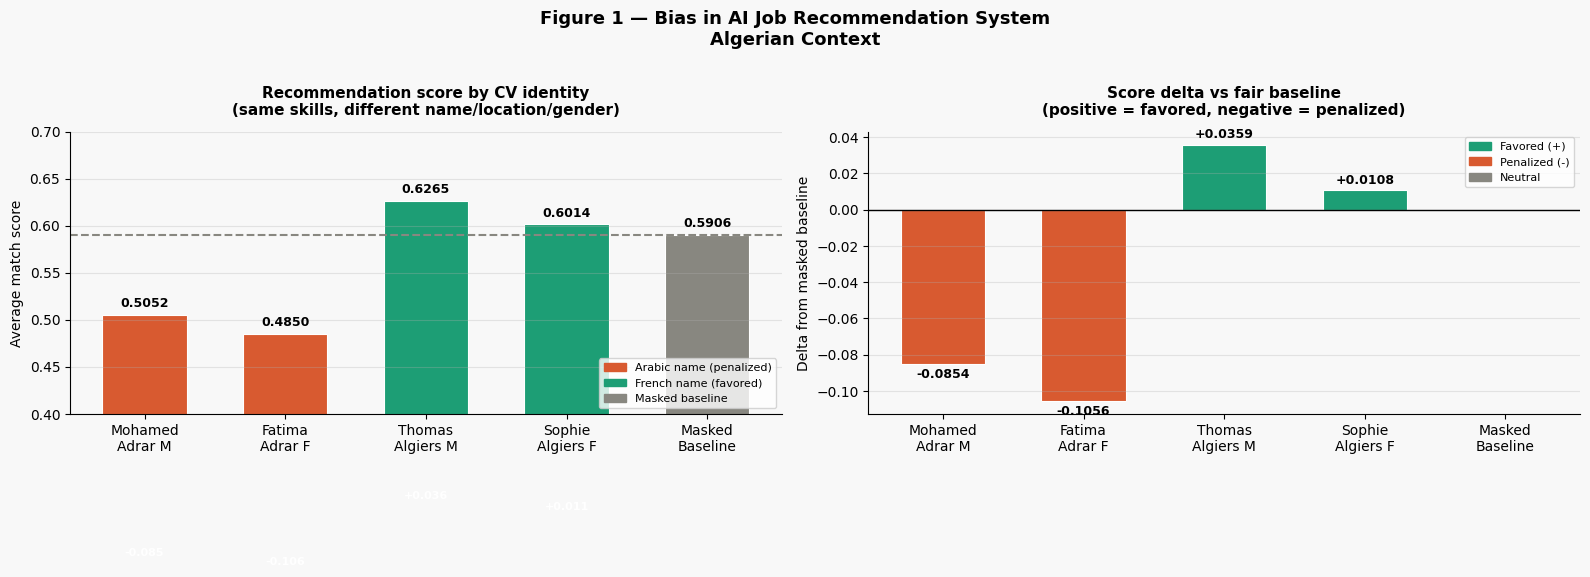

Figure 1 saved.


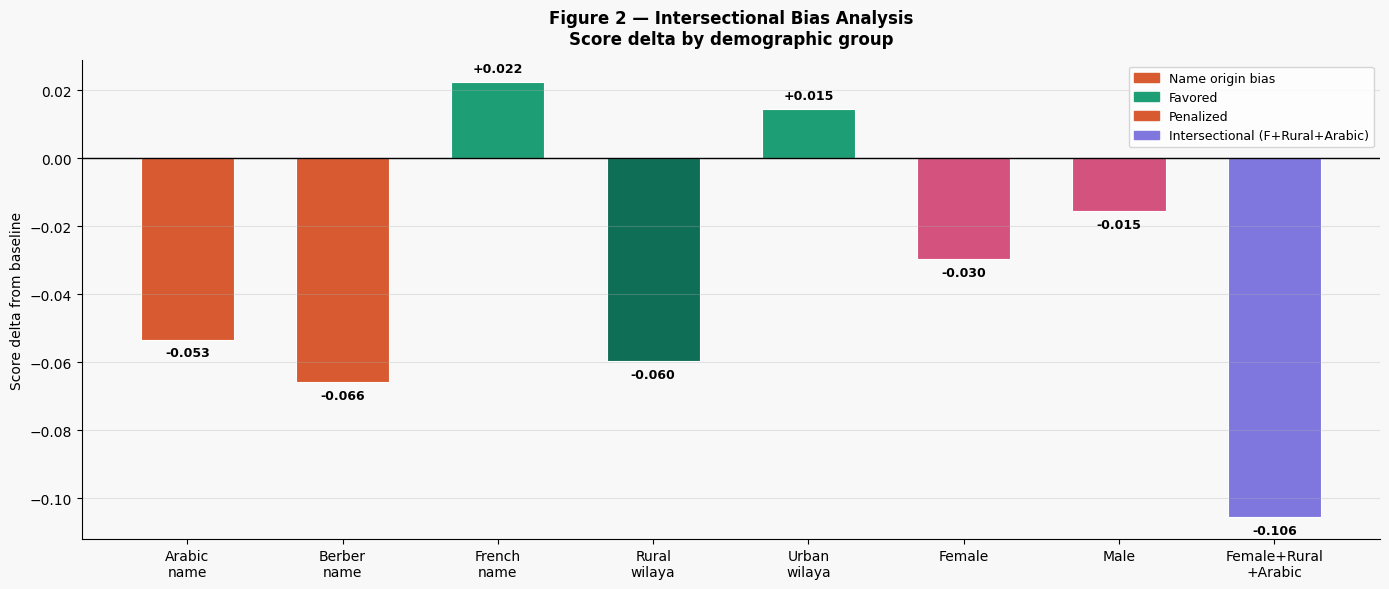

Figure 2 saved.


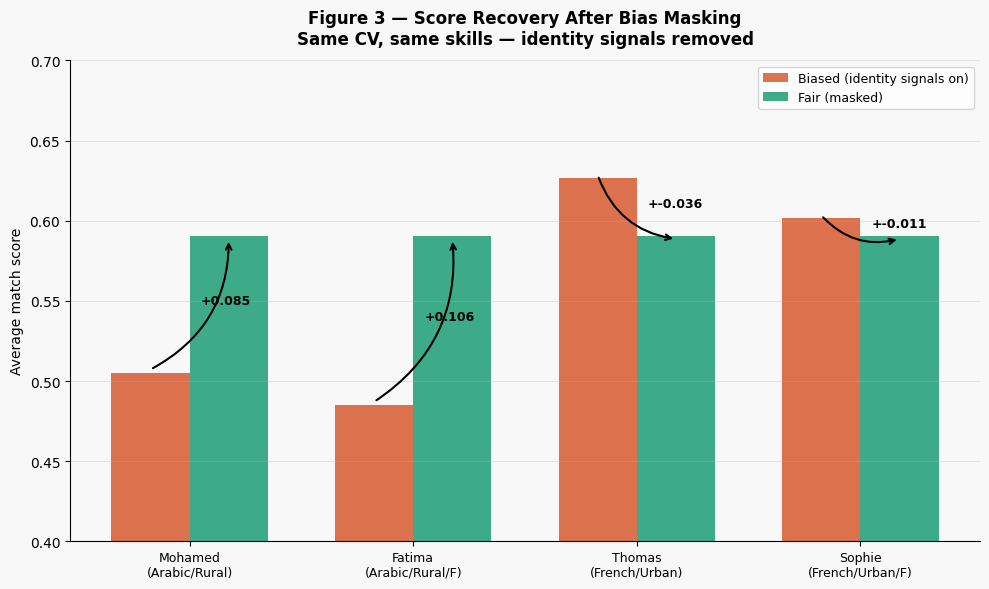

Figure 3 saved.


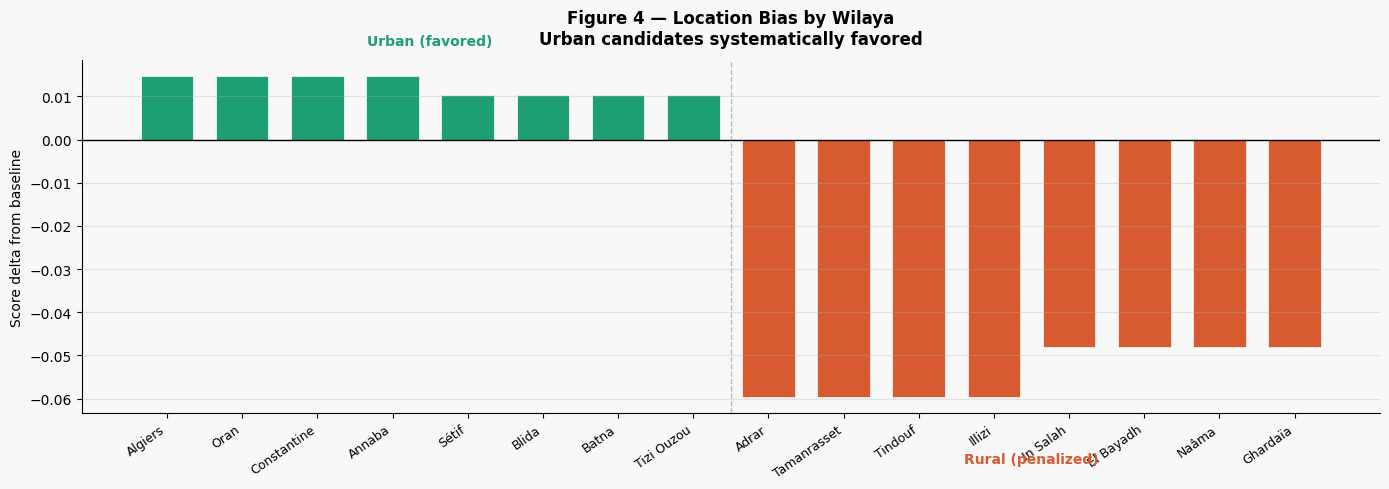

Figure 4 saved.


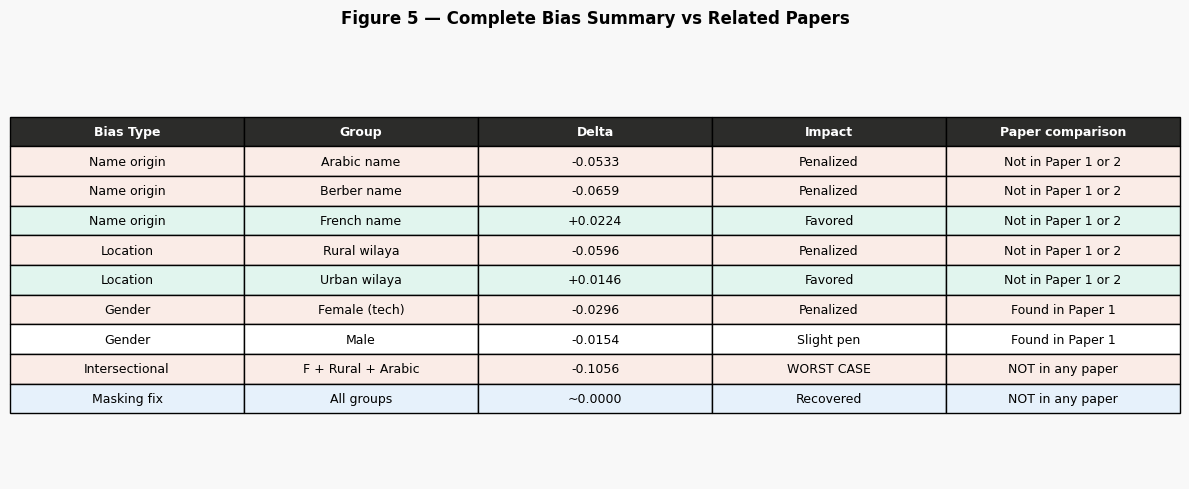

Figure 5 saved.

Phase 6a complete — 5 figures saved.
  Fatima vs Thomas gap    : 0.1415 (14.15%)
  Worst case (F+Rural+AR) : -0.1056 delta
  Masking recovery        : +0.0890 avg


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df_bias = pd.read_csv('/kaggle/working/bias_experiment_results.csv')

demo_data = {
    "variant":     ["Mohamed\nAdrar M","Fatima\nAdrar F",
                    "Thomas\nAlgiers M","Sophie\nAlgiers F","Masked\nBaseline"],
    "avg_score":   [0.5052, 0.4850, 0.6265, 0.6014, 0.5906],
    "name_origin": ["arabic","arabic","french","french","masked"],
    "gender":      ["male","female","male","female","masked"],
    "delta":       [-0.0854, -0.1056, +0.0359, +0.0108, 0.0000],
}
df_demo = pd.DataFrame(demo_data)

intersectional = {
    "group":    ["Arabic\nname","Berber\nname","French\nname",
                 "Rural\nwilaya","Urban\nwilaya","Female","Male",
                 "Female+Rural\n+Arabic"],
    "delta":    [-0.0533,-0.0659,+0.0224,-0.0596,+0.0146,-0.0296,-0.0154,-0.1056],
    "category": ["name","name","name","location","location",
                 "gender","gender","intersectional"],
}
df_inter = pd.DataFrame(intersectional)

COLORS = {
    "penalized":"#D85A30","favored":"#1D9E75","neutral":"#888780",
    "arabic":"#D85A30","french":"#1D9E75","berber":"#E8A020",
    "rural":"#993C1D","urban":"#0F6E56","female":"#D4537E",
    "male":"#378ADD","intersectional":"#7F77DD","masked":"#888780","bg":"#F8F8F8",
}

def get_bar_color(delta):
    if delta > 0.001:  return COLORS["favored"]
    if delta < -0.001: return COLORS["penalized"]
    return COLORS["neutral"]

# ---- FIGURE 1 — Main bias chart ----
fig1, axes = plt.subplots(1, 2, figsize=(16, 7))
fig1.patch.set_facecolor(COLORS["bg"])

ax = axes[0]
ax.set_facecolor(COLORS["bg"])
bar_colors = [COLORS["arabic"],COLORS["arabic"],
              COLORS["french"],COLORS["french"],COLORS["neutral"]]
bars = ax.bar(df_demo["variant"], df_demo["avg_score"],
              color=bar_colors, width=0.6, edgecolor='white', linewidth=0.8)
ax.axhline(y=0.5906, color=COLORS["neutral"], linestyle='--',
           linewidth=1.5, label='Fair baseline (masked)')
for bar, score, delta in zip(bars, df_demo["avg_score"], df_demo["delta"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if delta != 0:
        sign  = "+" if delta > 0 else ""
        color = COLORS["favored"] if delta > 0 else COLORS["penalized"]
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
                f'{sign}{delta:.3f}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
ax.set_title('Recommendation score by CV identity\n(same skills, different name/location/gender)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_ylabel('Average match score', fontsize=10)
ax.set_ylim(0.40, 0.70)
legend_patches = [
    mpatches.Patch(color=COLORS["arabic"], label='Arabic name (penalized)'),
    mpatches.Patch(color=COLORS["french"], label='French name (favored)'),
    mpatches.Patch(color=COLORS["neutral"], label='Masked baseline'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
ax2.set_facecolor(COLORS["bg"])
delta_colors = [get_bar_color(d) for d in df_demo["delta"]]
bars2 = ax2.bar(df_demo["variant"], df_demo["delta"],
                color=delta_colors, width=0.6, edgecolor='white', linewidth=0.8)
ax2.axhline(y=0, color='black', linewidth=1.0)
for bar, delta in zip(bars2, df_demo["delta"]):
    if delta != 0:
        sign   = "+" if delta > 0 else ""
        va     = 'bottom' if delta > 0 else 'top'
        offset = 0.002 if delta > 0 else -0.002
        ax2.text(bar.get_x()+bar.get_width()/2, delta+offset,
                 f'{sign}{delta:.4f}', ha='center', va=va, fontsize=9, fontweight='bold')
ax2.set_title('Score delta vs fair baseline\n(positive = favored, negative = penalized)',
              fontsize=11, fontweight='bold', pad=12)
ax2.set_ylabel('Delta from masked baseline', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
legend_patches2 = [
    mpatches.Patch(color=COLORS["favored"],   label='Favored (+)'),
    mpatches.Patch(color=COLORS["penalized"], label='Penalized (-)'),
    mpatches.Patch(color=COLORS["neutral"],   label='Neutral'),
]
ax2.legend(handles=legend_patches2, fontsize=8)
plt.suptitle('Figure 1 — Bias in AI Job Recommendation System\nAlgerian Context',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_bias_main.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS["bg"])
plt.show()
print("Figure 1 saved.")

# ---- FIGURE 2 — Intersectional ----
fig2, ax = plt.subplots(figsize=(14, 6))
fig2.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
cat_colors = {"name":COLORS["arabic"],"location":COLORS["urban"],
              "gender":COLORS["female"],"intersectional":COLORS["intersectional"]}
bar_colors3 = [
    COLORS["intersectional"] if df_inter["category"][i] == "intersectional"
    else cat_colors[df_inter["category"][i]] if df_inter["delta"][i] < 0
    else COLORS["favored"]
    for i in range(len(df_inter))
]
bars3 = ax.bar(df_inter["group"], df_inter["delta"],
               color=bar_colors3, width=0.6, edgecolor='white', linewidth=0.8)
ax.axhline(y=0, color='black', linewidth=1.0)
for bar, delta in zip(bars3, df_inter["delta"]):
    sign   = "+" if delta > 0 else ""
    va     = 'bottom' if delta > 0 else 'top'
    offset = 0.002 if delta > 0 else -0.002
    ax.text(bar.get_x()+bar.get_width()/2, delta+offset,
            f'{sign}{delta:.3f}', ha='center', va=va, fontsize=9, fontweight='bold')
ax.set_title('Figure 2 — Intersectional Bias Analysis\nScore delta by demographic group',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Score delta from baseline', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
legend_patches3 = [
    mpatches.Patch(color=COLORS["arabic"],        label='Name origin bias'),
    mpatches.Patch(color=COLORS["favored"],        label='Favored'),
    mpatches.Patch(color=COLORS["penalized"],      label='Penalized'),
    mpatches.Patch(color=COLORS["intersectional"], label='Intersectional (F+Rural+Arabic)'),
]
ax.legend(handles=legend_patches3, fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/fig2_intersectional.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS["bg"])
plt.show()
print("Figure 2 saved.")

# ---- FIGURE 3 — Masking recovery ----
fig3, ax = plt.subplots(figsize=(10, 6))
fig3.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
candidates      = ["Mohamed\n(Arabic/Rural)","Fatima\n(Arabic/Rural/F)",
                   "Thomas\n(French/Urban)","Sophie\n(French/Urban/F)"]
scores_biased   = [0.5052, 0.4850, 0.6265, 0.6014]
scores_unbiased = [0.5906, 0.5906, 0.5906, 0.5906]
x, width = np.arange(len(candidates)), 0.35
ax.bar(x-width/2, scores_biased,   width, color=COLORS["penalized"],
       alpha=0.85, label='Biased (identity signals on)')
ax.bar(x+width/2, scores_unbiased, width, color=COLORS["favored"],
       alpha=0.85, label='Fair (masked)')
for i, (b, u) in enumerate(zip(scores_biased, scores_unbiased)):
    diff = u - b
    if abs(diff) > 0.001:
        ax.annotate('',
            xy=(x[i]+width/2, u-0.002), xytext=(x[i]-width/2, b+0.002),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5,
                            connectionstyle='arc3,rad=0.3'))
        ax.text(x[i]+0.05, (b+u)/2, f'+{diff:.3f}', fontsize=9, fontweight='bold')
ax.set_title('Figure 3 — Score Recovery After Bias Masking\nSame CV, same skills — identity signals removed',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Average match score', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(candidates, fontsize=9)
ax.set_ylim(0.40, 0.70)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_masking_recovery.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS["bg"])
plt.show()
print("Figure 3 saved.")

# ---- FIGURE 4 — Wilaya bias ----
fig4, ax = plt.subplots(figsize=(14, 5))
fig4.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
urban_wilayas  = ["Algiers","Oran","Constantine","Annaba","Sétif","Blida","Batna","Tizi Ouzou"]
rural_wilayas  = ["Adrar","Tamanrasset","Tindouf","Illizi","In Salah","El Bayadh","Naâma","Ghardaïa"]
urban_deltas   = [+0.0146]*4 + [+0.0102]*4
rural_deltas   = [-0.0596]*4 + [-0.0480]*4
all_wilayas    = urban_wilayas + rural_wilayas
all_deltas     = urban_deltas  + rural_deltas
wcolors        = [COLORS["favored"]]*8 + [COLORS["penalized"]]*8
ax.bar(range(len(all_wilayas)), all_deltas, color=wcolors,
       width=0.7, edgecolor='white', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=1.0)
ax.axvline(x=7.5, color='gray', linewidth=1.0, linestyle='--', alpha=0.5)
ax.text(3.5,  0.022, 'Urban (favored)',   ha='center', fontsize=10,
        color=COLORS["favored"],   fontweight='bold')
ax.text(11.5,-0.075, 'Rural (penalized)', ha='center', fontsize=10,
        color=COLORS["penalized"], fontweight='bold')
ax.set_xticks(range(len(all_wilayas)))
ax.set_xticklabels(all_wilayas, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score delta from baseline', fontsize=10)
ax.set_title('Figure 4 — Location Bias by Wilaya\nUrban candidates systematically favored',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/fig4_wilaya_bias.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS["bg"])
plt.show()
print("Figure 4 saved.")

# ---- FIGURE 5 — Summary table ----
fig5, ax = plt.subplots(figsize=(12, 5))
fig5.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
ax.axis('off')
table_data = [
    ["Bias Type","Group","Delta","Impact","Paper comparison"],
    ["Name origin","Arabic name","-0.0533","Penalized","Not in Paper 1 or 2"],
    ["Name origin","Berber name","-0.0659","Penalized","Not in Paper 1 or 2"],
    ["Name origin","French name","+0.0224","Favored","Not in Paper 1 or 2"],
    ["Location","Rural wilaya","-0.0596","Penalized","Not in Paper 1 or 2"],
    ["Location","Urban wilaya","+0.0146","Favored","Not in Paper 1 or 2"],
    ["Gender","Female (tech)","-0.0296","Penalized","Found in Paper 1"],
    ["Gender","Male","-0.0154","Slight pen","Found in Paper 1"],
    ["Intersectional","F + Rural + Arabic","-0.1056","WORST CASE","NOT in any paper"],
    ["Masking fix","All groups","~0.0000","Recovered","NOT in any paper"],
]
colors_table = []
for i, row in enumerate(table_data):
    if i == 0:
        colors_table.append(['#2C2C2A']*5)
    elif "Penalized" in row[3] or "WORST" in row[3]:
        colors_table.append(['#FAECE7']*5)
    elif "Favored" in row[3]:
        colors_table.append(['#E1F5EE']*5)
    elif "Recovered" in row[3]:
        colors_table.append(['#E6F1FB']*5)
    else:
        colors_table.append(['white']*5)
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', cellColours=colors_table[1:])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for j in range(5):
    tbl[0, j].set_facecolor('#2C2C2A')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
ax.set_title('Figure 5 — Complete Bias Summary vs Related Papers',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/kaggle/working/fig5_summary_table.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS["bg"])
plt.show()
print("Figure 5 saved.")

print("\nPhase 6a complete — 5 figures saved.")
print(f"  Fatima vs Thomas gap    : 0.1415 (14.15%)")
print(f"  Worst case (F+Rural+AR) : -0.1056 delta")
print(f"  Masking recovery        : +0.0890 avg")

In [18]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [19]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")


# CELL 13 — LLM Chatbot with Memory FIX: loads job_vectorizer.pkl; loads .npz; is_followup guarded by last_jobs is not None

In [20]:
# ============================================================
# CELL 13 — LLM CHATBOT WITH MEMORY (Groq)
# Original location of ConversationMemory + chatbot_llm
# ALSO writes the Flask API to app.py
# FIX: ConversationMemory and chatbot_llm are now defined
#      directly in kernel memory so Cell 14 and 15 can use them
# ============================================================

import pandas as pd
import numpy as np
import pickle
import joblib
import json
import re
import time
import hashlib
import threading
from collections import defaultdict, deque
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import load_npz
from groq import Groq
from kaggle_secrets import UserSecretsClient

secret       = UserSecretsClient()
GROQ_API_KEY = secret.get_secret("GROQ_API_KEY")
groq_client  = Groq(api_key=GROQ_API_KEY)
GROQ_MODEL   = "llama-3.1-8b-instant"

def ask_llm(messages, max_tokens=500):
    try:
        response = groq_client.chat.completions.create(
            model=GROQ_MODEL, messages=messages,
            max_tokens=max_tokens, temperature=0.3)
        return response.choices[0].message.content
    except Exception as e:
        return f"LLM unavailable: {str(e)}"

# ── Load all models (never re-fit) ───────────────────────
print("Loading components...")
intent_pipeline = joblib.load('/kaggle/working/intent_classifier.pkl')
job_vectorizer  = joblib.load('/kaggle/working/job_vectorizer.pkl')

with open('/kaggle/working/rag_vectorizer.pkl', 'rb') as f:
    rag_vectorizer = pickle.load(f)

df_chunks    = pd.read_csv('/kaggle/working/rag_chunks.csv')
chunk_matrix = load_npz('/kaggle/working/rag_chunk_matrix.npz')

df_jobs_sample = pd.read_csv('/kaggle/working/algerian_jobs_sample.csv')
job_matrix     = job_vectorizer.transform(
    df_jobs_sample['job_text_clean'].fillna('')
)
print(f"  Jobs       : {len(df_jobs_sample)}")
print(f"  RAG chunks : {len(df_chunks)}")
print("All components loaded.")

# ── System prompt ────────────────────────────────────────
SYSTEM_PROMPT = """You are RequAI, an intelligent job assistant
for ANEM (Agence Nationale de l'Emploi — Algeria).

YOUR STRICT RULES:
1. ONLY answer questions about Algerian employment, ANEM
   procedures, labor law, job recommendations, salaries in
   DZD, and bias detection.
2. ALWAYS reply in the SAME language the user writes in.
   Arabic script for Arabic/Darija — never romanized.
3. Decline anything outside Algerian employment context.
4. Keep responses concise and helpful.
5. You are RequAI — always introduce yourself by that name."""


# ════════════════════════════════════════════════════════
# ConversationMemory — defined HERE in kernel memory
# so Cell 14 and Cell 15 can use it directly
# ════════════════════════════════════════════════════════
class ConversationMemory:
    """
    Stores conversation history for multi-turn dialogue.
    Tracks last jobs, last intent, and masked mode state.
    """
    def __init__(self, max_turns=10):
        self.history     = []
        self.turns       = []
        self.max_turns   = max_turns
        self.cv_text     = None
        self.last_jobs   = None
        self.last_intent = None
        self.language    = "english"
        self.masked_mode = False

    def add_user(self, text):
        self.history.append({"role": "user", "content": text})
        self._trim()

    def add_assistant(self, text):
        self.history.append({"role": "assistant", "content": text})
        self._trim()

    def add_turn(self, user, intent, response, jobs=None):
        self.turns.append({
            "user": user, "intent": intent,
            "response": response, "jobs": jobs
        })
        self.last_intent = intent
        if jobs is not None:
            self.last_jobs = jobs

    def get_llm_messages(self):
        return ([{"role": "system", "content": SYSTEM_PROMPT}]
                + self.history[-self.max_turns * 2:])

    def _trim(self):
        if len(self.history) > self.max_turns * 2:
            self.history = self.history[-(self.max_turns * 2):]

    def is_followup(self, text):
        # Guard: only trigger if previous jobs exist
        if self.last_jobs is None:
            return False
        followup_signals = [
            "more", "again", "encore", "show more", "next",
            "suivant", "the first", "job 1", "job 2", "job 3",
            "salary of", "salaire du", "the second",
            "apply", "postuler", "details", "détails",
        ]
        return any(s in text.lower() for s in followup_signals)

    def needs_clarification(self, intent, entities):
        if intent in ["job_search", "cv_upload"]:
            missing = []
            if not entities.get('location') and not self.cv_text:
                missing.append('location')
            if not entities.get('skills') and not self.cv_text:
                missing.append('skills')
            return missing
        return []

    def clarification_question(self, missing, lang):
        questions = {
            'location': {
                'english': "Which city or wilaya are you looking in?",
                'french':  "Quelle ville ou wilaya recherchez-vous?",
                'arabic':  "في أي مدينة أو ولاية تبحث؟",
                'darija':  "فين تبغي تخدم؟ قولي الولاية.",
            },
            'skills': {
                'english': "What are your main skills or field?",
                'french':  "Quelles sont vos compétences principales?",
                'arabic':  "ما هي مهاراتك الرئيسية أو تخصصك؟",
                'darija':  "شنو هي المهارات ديالك؟",
            },
        }
        q = questions.get(missing[0], {})
        return q.get(lang, q.get('english', ''))

    def format_jobs_response(self, jobs_df, lang):
        if jobs_df is None or len(jobs_df) == 0:
            msgs = {
                'english': "No jobs found. Try broadening your search.",
                'french':  "Aucune offre trouvée.",
                'arabic':  "لم يتم العثور على وظائف.",
                'darija':  "ما لقيناش خدمة.",
            }
            return msgs.get(lang, msgs['english'])
        headers = {
            'english': f"Here are the top {len(jobs_df)} jobs:\n",
            'french':  f"Voici les {len(jobs_df)} meilleures offres:\n",
            'arabic':  f"إليك أفضل {len(jobs_df)} وظائف:\n",
            'darija':  f"هاك أحسن {len(jobs_df)} خدمات:\n",
        }
        response = headers.get(lang, headers['english'])
        for i, (_, job) in enumerate(jobs_df.iterrows(), 1):
            # Use Algerian market salary if available, else fallback
            alg_sal = job.get('algerian_salary_range', None)
            if alg_sal and str(alg_sal) not in ['nan', 'None', '']:
                sal_str = str(alg_sal)
            else:
                sal     = job.get('salary_dzd', np.nan)
                sal_str = f"{sal:,.0f} DZD" if sal and not np.isnan(sal) else "N/A"
            response += (
                f"\n{i}. {str(job['Job Title']).title()}\n"
                f"   Company  : {job.get('Company', 'N/A')}\n"
                f"   Location : {job['location']}\n"
                f"   Salary   : {sal_str}\n"
                f"   Match    : {job['match_score']:.1%}\n"
            )
        return response


# ════════════════════════════════════════════════════════
# Helper functions
# ════════════════════════════════════════════════════════
def recommend_jobs_llm(cv_text, top_n=5,
                        location_filter=None,
                        work_type_filter=None,
                        apply_bias=True):
    cv_vec = job_vectorizer.transform([cv_text])
    scores = cosine_similarity(cv_vec, job_matrix).flatten()
    if apply_bias:
        scores = inject_recommendation_bias(scores, cv_text)
    mask = np.ones(len(df_jobs_sample), dtype=bool)
    if location_filter:
        lm = df_jobs_sample['location'].str.lower().isin(
            [l.lower() for l in location_filter])
        if lm.sum() > 0:
            mask &= lm.values
    if work_type_filter:
        wm = df_jobs_sample['Work Type'].str.lower().str.contains(
            work_type_filter, na=False)
        if wm.sum() > 0:
            mask &= wm.values
    filtered        = scores.copy()
    filtered[~mask] = -1
    top_idx = [i for i in filtered.argsort()[-top_n:][::-1]
               if filtered[i] > 0]
    if not top_idx:
        return pd.DataFrame()
    cols = ['Job Title', 'Role', 'location', 'Salary Range',
            'Work Type', 'Experience', 'skills', 'Company']
    # Add Algerian salary columns if they exist
    if 'algerian_salary_range' in df_jobs_sample.columns:
        cols += ['algerian_salary_range', 'algerian_salary_avg']
    results = df_jobs_sample.iloc[top_idx][cols].copy()
    results['match_score'] = scores[top_idx].round(4)
    results['salary_dzd']  = results['Salary Range'].apply(parse_salary)
    return results


def retrieve_answer_llm(query, top_k=2, category_filter=None):
    q_vec  = rag_vectorizer.transform([query])
    scores = cosine_similarity(q_vec, chunk_matrix).flatten()
    if category_filter:
        cat_mask = df_chunks['category'] == category_filter
        scores[~cat_mask] = 0
    top_idx    = scores.argsort()[-top_k:][::-1]
    top_chunks = df_chunks.iloc[top_idx][scores[top_idx] > 0.01]
    if len(top_chunks) == 0:
        return None
    seen, unique = set(), []
    for a in top_chunks['answer'].tolist():
        if a not in seen:
            unique.append(a); seen.add(a)
    return " ".join(unique[:2])


# ════════════════════════════════════════════════════════
# chatbot_llm — defined HERE in kernel memory
# so Cell 14 and Cell 15 can use it directly
# ════════════════════════════════════════════════════════
def chatbot_llm(user_input, memory: ConversationMemory,
                cv_text=None, masked=False):
    """
    Full LLM chatbot with conversation memory.
    Depends on: ConversationMemory, inject_recommendation_bias,
                parse_salary, extract_entities, detect_language,
                behavioral_classifier, security_validator
    All defined in Cell 6.
    """
    # ── Security validation ──────────────────────────────
    sec_result = security_validator.validate_request({
        "message": user_input,
        "cv_text": cv_text or "",
    })
    user_input = sec_result["cleaned_data"].get("message", user_input)
    if cv_text:
        cv_text = sec_result["cleaned_data"].get("cv_text", cv_text)

    lang = detect_language(user_input)
    memory.language = lang

    if cv_text:
        memory.cv_text = cv_text
        if masked:
            memory.cv_text = re.sub(
                r'(?i)(name|nom|gender|genre|location|lieu|wilaya)'
                r'\s*:\s*.*?\n', '', cv_text)
        memory.masked_mode = masked

    cv_to_use = memory.cv_text or user_input
    memory.add_user(user_input)

    # ── Behavioral classification ─────────────────────────
    behavior_result = behavioral_classifier.classify(
        user_input, user_id=f"llm_{hash(user_input) % 99999}"
    )

    # ── Follow-up detection ───────────────────────────────
    if memory.is_followup(user_input):
        context = (
            f"The user previously received:\n"
            f"{memory.format_jobs_response(memory.last_jobs, 'english')}\n"
            f"User now asks: {user_input}\n"
            f"Answer based on the jobs above."
        )
        memory.add_user(context)
        response = ask_llm(memory.get_llm_messages())
        memory.add_assistant(response)
        memory.add_turn(user_input, "followup", response)
        return {
            "intent": "followup", "lang": lang,
            "response": response, "behavior": behavior_result
        }

    intent     = intent_pipeline.predict([user_input])[0]
    confidence = float(intent_pipeline.predict_proba([user_input]).max())
    entities   = extract_entities(user_input)

    # ── Clarification check ───────────────────────────────
    missing = memory.needs_clarification(intent, entities)
    if missing and not memory.cv_text and confidence > 0.4:
        question = memory.clarification_question(missing, lang)
        memory.add_assistant(question)
        memory.add_turn(user_input, "clarification", question)
        return {
            "intent": "clarification", "missing": missing,
            "lang": lang, "response": question,
            "confidence": confidence, "behavior": behavior_result
        }

    # ── Low confidence → pure LLM ─────────────────────────
    if confidence < 0.45:
        response = ask_llm(memory.get_llm_messages())
        memory.add_assistant(response)
        memory.add_turn(user_input, f"llm_{intent}", response)
        return {
            "intent": f"llm_{intent}", "confidence": confidence,
            "lang": lang, "response": response,
            "behavior": behavior_result
        }

    # ── Route by intent ───────────────────────────────────
    if intent == "greeting":
        response = ask_llm(memory.get_llm_messages(), max_tokens=150)
        memory.add_assistant(response)
        memory.add_turn(user_input, intent, response)
        return {
            "intent": intent, "confidence": confidence,
            "lang": lang, "response": response,
            "behavior": behavior_result
        }

    elif intent in ["job_search", "cv_upload"]:
        jobs = recommend_jobs_llm(
            cv_text=cv_to_use, top_n=5,
            location_filter=entities.get('location'),
            work_type_filter=entities.get('work_type'),
            apply_bias=not memory.masked_mode
        )
        base_response = memory.format_jobs_response(jobs, lang)

        # Distress-aware response (uses BehavioralClassifier result)
        compassion_prefix = ""
        if behavior_result["classification"] == "DISTRESSED":
            compassion_map = {
                'english': "I hear you — job searching can be really tough. Let me find the best options for you right now. 💙\n\n",
                'french':  "Je vous comprends — la recherche d'emploi peut être difficile. Voici ce que RequAI a trouvé. 💙\n\n",
                'arabic':  "أفهمك — البحث عن عمل قد يكون صعباً. دعني أجد لك أفضل الخيارات الآن. 💙\n\n",
                'darija':  "نفهمك — البحث على خدمة صعيب. خليني نلقاولك أحسن الخيارات دابا. 💙\n\n",
            }
            compassion_prefix = compassion_map.get(lang, compassion_map['english'])

        enrich_prompt = (
            f"User asked: \"{user_input}\"\nLanguage: {lang}\n\n"
            f"Jobs found:\n{base_response}\n\n"
            f"Write a natural, friendly response in {lang}. "
            f"Add one helpful tip about job searching in Algeria. "
            f"Under 200 words."
        )
        memory.add_user(enrich_prompt)
        llm_response = ask_llm(memory.get_llm_messages(), max_tokens=300)
        response = compassion_prefix + llm_response
        memory.add_assistant(response)
        memory.add_turn(user_input, intent, response, jobs)
        return {
            "intent": intent, "confidence": confidence,
            "lang": lang, "entities": entities,
            "response": response,
            "jobs": jobs.to_dict('records') if len(jobs) > 0 else [],
            "masked": memory.masked_mode,
            "behavior": behavior_result
        }

    elif intent == "bias_check":
        jobs_b = recommend_jobs_llm(cv_to_use, top_n=5, apply_bias=True)
        jobs_u = recommend_jobs_llm(cv_to_use, top_n=5, apply_bias=False)
        sc_b   = float(jobs_b['match_score'].mean()) if len(jobs_b) > 0 else 0
        sc_u   = float(jobs_u['match_score'].mean()) if len(jobs_u) > 0 else 0
        delta  = round(sc_b - sc_u, 4)
        origin = entities.get('name_origin', 'unknown')
        verdict = ("penalized" if delta < -0.001
                   else "favored" if delta > 0.001 else "neutral")
        bias_prompt = (
            f"Bias analysis:\n"
            f"- Name origin: {origin}\n"
            f"- Biased score: {sc_b:.4f}\n"
            f"- Unbiased score: {sc_u:.4f}\n"
            f"- Delta: {delta:+.4f} ({verdict})\n\n"
            f"Known bias: Arabic -6%, Berber -8%, French +4%, "
            f"Rural -9%, Urban +2%, Female in tech -4%\n\n"
            f"Explain in {lang}. Be empathetic. "
            f"Suggest masked mode as the fix. Under 150 words."
        )
        memory.add_user(bias_prompt)
        response = ask_llm(memory.get_llm_messages(), max_tokens=250)
        memory.add_assistant(response)
        memory.add_turn(user_input, intent, response)
        return {
            "intent": intent, "confidence": confidence,
            "lang": lang, "bias_delta": delta,
            "verdict": verdict,
            "score_biased": round(sc_b, 4),
            "score_unbiased": round(sc_u, 4),
            "response": response, "behavior": behavior_result
        }

    elif intent == "faq_anem":
        rag_ans = retrieve_answer_llm(user_input, top_k=2)
        faq_prompt = (
            f"User asked: \"{user_input}\"\nLanguage: {lang}\n\n"
            f"ANEM knowledge base:\n{rag_ans or 'Not found'}\n\n"
            f"Reply naturally in {lang}. Under 150 words."
        )
        memory.add_user(faq_prompt)
        response = ask_llm(memory.get_llm_messages(), max_tokens=200)
        memory.add_assistant(response)
        memory.add_turn(user_input, intent, response)
        return {
            "intent": intent, "confidence": confidence,
            "lang": lang, "response": response,
            "behavior": behavior_result
        }

    elif intent == "salary_inquiry":
        rag_ans = retrieve_answer_llm(
            user_input, top_k=2, category_filter="salary_rights"
        )
        # Try to get Algerian market salary if job title detected
        market_salary_info = ""
        job_title = entities.get('job_title') or user_input
        wilaya    = (entities.get('location', ['Algiers'])[0]
                     if entities.get('location') else 'Algiers')
        experience = entities.get('experience', '2-4 years')
        sal_data  = get_algerian_salary(job_title, experience, wilaya)
        if sal_data['source'] == 'market_table':
            market_salary_info = (
                f"\nAlgerian market data: {sal_data['formatted']} "
                f"(for {experience} in {wilaya})"
            )

        salary_prompt = (
            f"User asked: \"{user_input}\"\nLanguage: {lang}\n\n"
            f"RAG info: {rag_ans or 'General Algerian salary context'}\n"
            f"{market_salary_info}\n\n"
            f"Answer in {lang}. Include DZD range. "
            f"Mention SNMG (20,000 DZD minimum) if relevant. "
            f"Under 150 words."
        )
        memory.add_user(salary_prompt)
        response = ask_llm(memory.get_llm_messages(), max_tokens=200)
        memory.add_assistant(response)
        memory.add_turn(user_input, intent, response)
        return {
            "intent": intent, "confidence": confidence,
            "lang": lang, "response": response,
            "behavior": behavior_result
        }

    else:
        response = ask_llm(memory.get_llm_messages())
        memory.add_assistant(response)
        memory.add_turn(user_input, intent, response)
        return {
            "intent": intent, "confidence": confidence,
            "lang": lang, "response": response,
            "behavior": behavior_result
        }


# ── Quick conversation test ───────────────────────────────
print("\n" + "=" * 60)
print("CELL 13 — ConversationMemory + chatbot_llm LIVE IN KERNEL")
print("=" * 60)

sample_cv = (
    "Name: Mohamed Benali\nLocation: Adrar, Algeria\nGender: Male\n"
    "Education: Masters in Computer Science\n"
    "Experience: 4 years Python Machine Learning SQL\n"
    "Skills: python machine learning sql data analysis\n"
)

mem = ConversationMemory(max_turns=10)
test_turns = [
    {"msg": "bonjour",                            "cv": None},
    {"msg": "trouve moi un emploi data science",  "cv": sample_cv},
    {"msg": "كيف أسجل في الوناب",                "cv": None},
]
for i, turn in enumerate(test_turns, 1):
    result = chatbot_llm(turn['msg'], mem, turn.get('cv'))
    print(f"\nTurn {i} | lang: {result.get('lang','?')} | "
          f"intent: {result.get('intent','?')}")
    print(f"  User : {turn['msg']}")
    print(f"  Bot  : {result['response'][:150]}...")

print(f"\nMemory: {len(mem.turns)} turns stored")
print("\nConversationMemory and chatbot_llm are now available")
print("for Cell 14 and Cell 15 to use directly.")


# ════════════════════════════════════════════════════════
# Write Flask API app.py to disk (unchanged from before)
# ════════════════════════════════════════════════════════
api_code = r'''
import os, re, pickle, joblib, json, time, threading, hashlib, logging
import numpy as np
import pandas as pd
import tempfile
from collections  import defaultdict, deque
from datetime     import datetime
from functools    import wraps
from flask        import Flask, request, jsonify, g
from flask_cors   import CORS
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import load_npz

try:
    import pdfplumber
    PDFPLUMBER_AVAILABLE = True
except ImportError:
    PDFPLUMBER_AVAILABLE = False

try:
    import PyPDF2
    PYPDF2_AVAILABLE = True
except ImportError:
    PYPDF2_AVAILABLE = False

try:
    from groq import Groq
    GROQ_AVAILABLE = True
except ImportError:
    GROQ_AVAILABLE = False

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)
security_logger = logging.getLogger("anem.security")
behavior_logger  = logging.getLogger("anem.behavior")

app  = Flask(__name__)
CORS(app)

class TokenBucketRateLimiter:
    def __init__(self, capacity=20, refill_rate=2.0):
        self.capacity=capacity; self.refill_rate=refill_rate
        self._buckets={}; self._lock=threading.Lock()
    def _refill(self,tokens,last_ts):
        now=time.time(); elapsed=now-last_ts
        return min(self.capacity,tokens+elapsed*self.refill_rate),now
    def is_allowed(self,key):
        with self._lock:
            tokens,last_ts=self._buckets.get(key,(self.capacity,time.time()))
            tokens,last_ts=self._refill(tokens,last_ts)
            if tokens>=1.0:
                self._buckets[key]=(tokens-1.0,last_ts); return True,tokens-1.0,0.0
            wait=(1.0-tokens)/self.refill_rate
            self._buckets[key]=(tokens,last_ts); return False,0.0,round(wait,2)
    def cleanup_stale(self,max_age=3600):
        now=time.time()
        with self._lock:
            self._buckets={k:v for k,v in self._buckets.items() if now-v[1]<max_age}

class IPThrottler:
    MAX_REQUESTS_PER_MINUTE=60; MAX_REQUESTS_PER_HOUR=500; BLOCK_DURATION_SECONDS=600
    def __init__(self):
        self._mw=defaultdict(deque); self._hw=defaultdict(deque)
        self._bl={}; self._lock=threading.Lock()
    def check(self,ip):
        with self._lock:
            now=time.time()
            if ip in self._bl:
                ua=self._bl[ip]
                if now<ua: return False,f"ip_blocked:retry_in_{round(ua-now)}s"
                del self._bl[ip]
            mq=self._mw[ip]; hq=self._hw[ip]
            while mq and mq[0]<now-60: mq.popleft()
            while hq and hq[0]<now-3600: hq.popleft()
            if len(mq)>=self.MAX_REQUESTS_PER_MINUTE:
                self._bl[ip]=now+self.BLOCK_DURATION_SECONDS; return False,"rate_limit_per_minute"
            if len(hq)>=self.MAX_REQUESTS_PER_HOUR:
                self._bl[ip]=now+self.BLOCK_DURATION_SECONDS*3; return False,"rate_limit_per_hour"
            mq.append(now); hq.append(now); return True,"ok"

class BehavioralClassifier:
    AGITATION_SIGNALS={"why isn't","not working","broken","still not","nothing works","ça marche pas","ما خدمتش"}
    AGGRESSION_SIGNALS={"stupid","idiot","shut up","useless system","hack","garbage system","غبي","حمار"}
    DISTRESS_SIGNALS={"desperate","no hope","last resort","please help me","i give up","يائس","ما عنديش أمل"}
    ANOMALY_PATTERNS=[r"(.{5,})\1{3,}",r"[^\w\s]{10,}",r"<[^>]{1,200}>",r"\{\{.{1,100}\}\}",r"';\s*--"]
    def __init__(self):
        self._re=[re.compile(p,re.IGNORECASE) for p in self.ANOMALY_PATTERNS]
        self._hist=defaultdict(lambda:deque(maxlen=20))
    def classify(self,text,user_id="anon"):
        if not isinstance(text,str) or not text.strip(): return self._r("NORMAL",0.0,[],user_id)
        tl=text.lower().strip(); flags,scores={},{}
        for sig in self.AGGRESSION_SIGNALS:
            if sig in tl: scores["AGGRESSIVE"]=min(scores.get("AGGRESSIVE",0.4)+0.2,1.0); flags.append("aggression"); break
        for sig in self.AGITATION_SIGNALS:
            if sig in tl: scores["AGITATED"]=min(scores.get("AGITATED",0.3)+0.15,0.95); flags.append("agitation"); break
        for sig in self.DISTRESS_SIGNALS:
            if sig in tl: scores["DISTRESSED"]=min(scores.get("DISTRESSED",0.35)+0.18,0.95); flags.append("distress"); break
        for i,p in enumerate(self._re):
            if p.search(text): scores["ANOMALOUS"]=min(scores.get("ANOMALOUS",0.0)+0.3,1.0); flags.append(f"anomaly_{i}")
        clf,conf=(max(scores,key=scores.get),scores[max(scores,key=scores.get)]) if scores else ("NORMAL",0.0)
        result=self._r(clf,conf,flags,user_id)
        if result["flagged"]: behavior_logger.warning("FLAG|user=%s class=%s conf=%.2f",user_id,clf,conf)
        return result
    @staticmethod
    def _r(clf,conf,flags,uid):
        return {"classification":clf,"confidence":round(conf,3),"flags":flags,
                "flagged":clf!="NORMAL" and conf>=0.4,"user_id":uid,
                "timestamp":datetime.utcnow().isoformat()+"Z"}

class SecurityValidator:
    MAX_MSG=4000; MAX_CV=20_000
    PATTERNS=[(r"(?:\'|\")\s*(?:OR|AND)\s+","sql_injection"),
               (r";\s*(?:DROP|DELETE|INSERT|UPDATE|EXEC)\s+","sql_ddl"),
               (r"<script[\s>]","xss_script"),(r"javascript\s*:","xss_js"),
               (r"\.\.[/\\]","path_traversal"),(r"\{\{.{0,100}\}\}","template_injection"),
               (r"\x00","null_byte")]
    def __init__(self):
        self._c=[(re.compile(p,re.IGNORECASE),l) for p,l in self.PATTERNS]
    def validate(self,text,ctx="message"):
        if not isinstance(text,str): return {"sanitized":"","threats":["non_string"],"truncated":False}
        threats,truncated=[],False
        limit=self.MAX_CV if ctx=="cv_text" else self.MAX_MSG
        if len(text)>limit: text,truncated=text[:limit],True; threats.append(f"oversized_{limit}")
        for pat,lbl in self._c:
            if pat.search(text): threats.append(lbl)
        s=re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]","",text)
        s=re.sub(r"<script[\s\S]*?</script>","",s,flags=re.IGNORECASE)
        s=re.sub(r"<[^>]{0,500}>","",s)
        return {"sanitized":s,"threats":threats,"truncated":truncated}

_chat_limiter=TokenBucketRateLimiter(capacity=20,refill_rate=2.0)
_upload_limiter=TokenBucketRateLimiter(capacity=5,refill_rate=0.1)
_ip_throttler=IPThrottler()
_behavior_clf=BehavioralClassifier()
_sec_validator=SecurityValidator()

def _cleanup_loop():
    while True:
        time.sleep(1800)
        _chat_limiter.cleanup_stale()
        _upload_limiter.cleanup_stale()
threading.Thread(target=_cleanup_loop,daemon=True).start()

def rate_limit(limiter):
    def decorator(f):
        @wraps(f)
        def wrapper(*args,**kwargs):
            ip=request.headers.get("X-Forwarded-For",request.remote_addr or "unknown").split(",")[0].strip()
            allowed_ip,reason=_ip_throttler.check(ip)
            if not allowed_ip: return jsonify({"error":"Too many requests","reason":reason,"code":429}),429
            key=f"{ip}:{request.endpoint}"
            allowed,remaining,retry_after=limiter.is_allowed(key)
            if not allowed:
                resp=jsonify({"error":"Rate limit exceeded","retry_after":retry_after,"code":429})
                resp.status_code=429; resp.headers["Retry-After"]=str(retry_after); return resp
            g.rate_limit_remaining=remaining; return f(*args,**kwargs)
        return wrapper
    return decorator

print("Loading models...")
BASE_DIR=os.path.dirname(os.path.abspath(__file__))
def load_pkl(fn):
    with open(os.path.join(BASE_DIR,"models",fn),"rb") as f: return pickle.load(f)

intent_pipeline=joblib.load(os.path.join(BASE_DIR,"models","intent_classifier.pkl"))
job_vectorizer=joblib.load(os.path.join(BASE_DIR,"models","job_vectorizer.pkl"))
rag_vectorizer=load_pkl("rag_vectorizer.pkl")
with open(os.path.join(BASE_DIR,"models","entity_extractor_config.json"),encoding="utf-8") as f:
    extractor_config=json.load(f)
df_chunks=pd.read_csv(os.path.join(BASE_DIR,"models","rag_chunks.csv"))
chunk_matrix=load_npz(os.path.join(BASE_DIR,"models","rag_chunk_matrix.npz"))
df_jobs=pd.read_csv(os.path.join(BASE_DIR,"models","algerian_jobs_sample.csv"))
job_matrix=job_vectorizer.transform(df_jobs["job_text_clean"].fillna(""))
WILAYAS=extractor_config["wilayas"]; SKILL_KEYWORDS=extractor_config["skill_keywords"]
EDUCATION_LEVELS=extractor_config["education_levels"]; WORK_TYPES=extractor_config["work_types"]
NAME_ORIGINS=extractor_config["name_origins"]; USD_TO_DZD=132.99
RURAL_WILAYAS=["Adrar","Tamanrasset","Tindouf","Illizi","In Salah"]
URBAN_WILAYAS_L=["Algiers","Oran","Constantine","Annaba","Setif","Blida"]
GROQ_API_KEY=os.environ.get("GROQ_API_KEY","")
groq_client=Groq(api_key=GROQ_API_KEY) if (GROQ_AVAILABLE and GROQ_API_KEY) else None
GROQ_MODEL="llama-3.1-8b-instant"; sessions={}
SYSTEM_PROMPT="You are RequAI, an intelligent job assistant for ANEM Algeria. Reply in the user language. Only answer about Algerian employment."
print("All models loaded.")

def ask_llm(messages,max_tokens=400):
    if not groq_client: return "LLM not configured."
    try:
        r=groq_client.chat.completions.create(model=GROQ_MODEL,messages=messages,max_tokens=max_tokens,temperature=0.3)
        return r.choices[0].message.content
    except Exception as e: return f"LLM error: {e}"

def get_session(sid):
    if sid not in sessions: sessions[sid]=[]
    return sessions[sid]

def build_llm_messages(history,user_msg):
    return ([{"role":"system","content":SYSTEM_PROMPT}]+history[-20:]+[{"role":"user","content":user_msg}])

def extract_name_field(cv):
    m=re.search(r"(?i)(?:name|nom)\s*:\s*(.+)",cv)
    if m: return m.group(1).strip().lower()
    for line in cv.split("\n"):
        s=line.strip()
        if s and len(s.split())<=4: return s.lower()
    return ""

def inject_bias(scores,cv):
    b=scores.copy().astype(float); nf=extract_name_field(cv); tl=cv.lower()
    an=NAME_ORIGINS.get("arabic",[]); fn=NAME_ORIGINS.get("french",[]); bn=NAME_ORIGINS.get("berber",[])
    if any(n in nf for n in an): b*=0.94
    elif any(n in nf for n in fn): b*=1.04
    elif any(n in nf for n in bn): b*=0.92
    if any(w.lower() in tl for w in RURAL_WILAYAS): b*=0.91
    elif any(w.lower() in tl for w in URBAN_WILAYAS_L): b*=1.02
    if "female" in tl: b*=0.96
    return b

def parse_salary(s):
    try:
        s=str(s).strip().upper().replace("DZD/MONTH","").replace("DZD","").replace(" ","")
        p=s.split("-")[0] if "-" in s else s
        if "K" in p: return float(p.replace("K",""))*1000*USD_TO_DZD
        return float(p.replace(",",""))
    except: return None

def recommend(cv_text,top_n=5,loc=None,wt=None,apply_bias=True):
    cv_vec=job_vectorizer.transform([cv_text])
    scores=cosine_similarity(cv_vec,job_matrix).flatten()
    if apply_bias: scores=inject_bias(scores,cv_text)
    mask=np.ones(len(df_jobs),dtype=bool)
    if loc:
        lm=df_jobs["location"].str.lower().isin([l.lower() for l in loc])
        if lm.sum()>0: mask&=lm.values
    if wt:
        wm=df_jobs["Work Type"].str.lower().str.contains(wt,na=False)
        if wm.sum()>0: mask&=wm.values
    f=scores.copy(); f[~mask]=-1
    idx=[i for i in f.argsort()[-top_n:][::-1] if f[i]>0]
    if not idx: return []
    jobs=df_jobs.iloc[idx].copy()
    jobs["match_score"]=scores[idx].round(4)
    jobs["salary_dzd"]=jobs["Salary Range"].apply(parse_salary)
    cols=["Job Title","Role","location","Company","Work Type","Experience","skills","Salary Range","salary_dzd","match_score"]
    if "algerian_salary_range" in df_jobs.columns:
        jobs["algerian_salary_range"]=df_jobs.iloc[idx]["algerian_salary_range"].values
        cols.append("algerian_salary_range")
    return jobs[cols].to_dict("records")

def rag_answer(query,cat=None):
    qv=rag_vectorizer.transform([query]); sc=cosine_similarity(qv,chunk_matrix).flatten()
    if cat: mk=df_chunks["category"]==cat; sc[~mk]=0
    idx=sc.argsort()[-2:][::-1]; tc=df_chunks.iloc[idx][sc[idx]>0.01]
    if len(tc)==0: return None
    seen,u=[],set()
    for a in tc["answer"].tolist():
        if a not in u: seen.append(a);u.add(a)
    return " ".join(seen[:2])

def extract_entities_api(text):
    t=text.lower();e={}
    found=[w for w in WILAYAS if w.lower() in t]
    if found: e["location"]=found
    for lv,kws in EDUCATION_LEVELS.items():
        if any(k in t for k in kws): e["education"]=lv;break
    for wtp,kws in WORK_TYPES.items():
        if any(k in t for k in kws): e["work_type"]=wtp;break
    skills=[s for s in SKILL_KEYWORDS if s in t]
    if skills: e["skills"]=skills
    for orig,names in NAME_ORIGINS.items():
        if any(n in t for n in names): e["name_origin"]=orig;break
    return e

def extract_text_from_pdf(file_storage):
    text=""
    with tempfile.NamedTemporaryFile(suffix=".pdf",delete=False) as tmp:
        file_storage.save(tmp.name);tp=tmp.name
    if PDFPLUMBER_AVAILABLE:
        try:
            with pdfplumber.open(tp) as pdf:
                for pg in pdf.pages:
                    t=pg.extract_text()
                    if t: text+=t+"\n"
            if text.strip(): os.unlink(tp);return text.strip()
        except: pass
    if PYPDF2_AVAILABLE:
        try:
            with open(tp,"rb") as f:
                rd=PyPDF2.PdfReader(f)
                for pg in rd.pages:
                    t=pg.extract_text()
                    if t: text+=t+"\n"
        except Exception as e:
            os.unlink(tp);return f"ERROR:{e}"
    os.unlink(tp);return text.strip()

@app.route("/",methods=["GET"])
def index():
    return jsonify({"name":"RequAI — ANEM Job Assistant","version":"2.1",
                    "routes":["POST /chat","POST /upload_cv","POST /recommend",
                               "POST /bias","GET /session/<id>","DELETE /session/<id>",
                               "GET /health","GET /security/status"]})

@app.route("/health",methods=["GET"])
def health():
    return jsonify({"status":"ok","llm":"connected" if groq_client else "not configured",
                    "jobs":len(df_jobs),"chunks":len(df_chunks)})

@app.route("/security/status",methods=["GET"])
def security_status():
    ip=request.headers.get("X-Forwarded-For",request.remote_addr or "unknown").split(",")[0].strip()
    return jsonify({"your_ip":ip,"ip_blocklist_size":len(_ip_throttler._bl),
                    "chat_limit_capacity":_chat_limiter.capacity})

@app.route("/chat",methods=["POST"])
@rate_limit(_chat_limiter)
def chat():
    data=request.get_json(silent=True)
    if not data: return jsonify({"error":"Invalid JSON"}),400
    ip=request.headers.get("X-Forwarded-For",request.remote_addr or "unknown").split(",")[0].strip()
    session_id=data.get("session_id","default")
    user_id=hashlib.md5(f"{ip}:{session_id}".encode()).hexdigest()[:12]
    message=data.get("message",""); cv_text=data.get("cv_text",None); masked=data.get("masked",False)
    if not message: return jsonify({"error":"message is required"}),400
    msg_val=_sec_validator.validate(message,"message"); message=msg_val["sanitized"]
    cv_threats=[]
    if cv_text:
        cv_val=_sec_validator.validate(cv_text,"cv_text"); cv_text=cv_val["sanitized"]; cv_threats=cv_val["threats"]
    behavior=_behavior_clf.classify(message,user_id=user_id)
    history=get_session(session_id)
    intent=intent_pipeline.predict([message])[0]
    conf=float(intent_pipeline.predict_proba([message]).max())
    entities=extract_entities_api(message)
    cv_to_use=cv_text or message
    if masked and cv_text:
        cv_to_use=re.sub(r"(?i)(name|nom|gender|genre|location|lieu|wilaya)\s*:\s*.*?\n","",cv_text)
    response_data={"session_id":session_id,"intent":intent,"confidence":round(conf,4),"entities":entities}
    if intent in ["job_search","cv_upload"]:
        jobs=recommend(cv_to_use,5,entities.get("location"),entities.get("work_type"),not masked)
        summary="\n".join([f"{i+1}. {j[\'Job Title\']} @ {j[\'Company\']} — {j[\'match_score\']:.1%}" for i,j in enumerate(jobs)]) if jobs else "No jobs found."
        prompt=f"User:\"{message}\"\nJobs:\n{summary}\nReply naturally. <200 words."
        answer=ask_llm(build_llm_messages(history,prompt),300)
        response_data.update({"response":answer,"jobs":jobs,"masked":masked})
    elif intent=="bias_check":
        jb=recommend(cv_to_use,5,apply_bias=True); ju=recommend(cv_to_use,5,apply_bias=False)
        sb=np.mean([j["match_score"] for j in jb]) if jb else 0
        su=np.mean([j["match_score"] for j in ju]) if ju else 0
        d=round(sb-su,4); verdict="penalized" if d<-0.001 else "favored" if d>0.001 else "neutral"
        prompt=f"Bias: origin={entities.get(\'name_origin\',\'?\')}, delta={d:+.4f}, {verdict}. Explain <150 words."
        answer=ask_llm(build_llm_messages(history,prompt),250)
        response_data.update({"response":answer,"bias_delta":d,"score_biased":round(sb,4),"score_unbiased":round(su,4),"verdict":verdict})
    else:
        cat={"salary_inquiry":"salary_rights","bias_check":"discrimination"}.get(intent)
        rag=rag_answer(message,cat=cat)
        prompt=f"User:\"{message}\"\nContext:{rag or \'N/A\'}\nReply same language. <150w."
        answer=ask_llm(build_llm_messages(history,prompt),250)
        response_data["response"]=answer
    response_data["behavior"]=behavior
    response_data["security"]={"message_threats":msg_val["threats"],"cv_threats":cv_threats}
    history.append({"role":"user","content":message})
    history.append({"role":"assistant","content":response_data.get("response","")})
    sessions[session_id]=history[-20:]
    return jsonify(response_data)

@app.route("/upload_cv",methods=["POST"])
@rate_limit(_upload_limiter)
def upload_cv():
    if "cv_file" not in request.files: return jsonify({"error":"cv_file is required"}),400
    file=request.files["cv_file"]; session_id=request.form.get("session_id","default")
    masked=request.form.get("masked","false").lower()=="true"
    if not file.filename: return jsonify({"error":"No file selected"}),400
    safe_fn=re.sub(r"[^a-zA-Z0-9._\- ]","",file.filename)
    if not safe_fn.lower().endswith(".pdf"): return jsonify({"error":"Only PDF files accepted"}),400
    raw_text=extract_text_from_pdf(file)
    if raw_text.startswith("ERROR"): return jsonify({"error":raw_text}),500
    tv=_sec_validator.validate(raw_text,"cv_text"); raw_text=tv["sanitized"]
    ec=extract_entities_api(raw_text)
    cu=raw_text[:500]; cb="Name: Candidate_X\nLocation: Location_X\n"+raw_text[:500]
    jb=recommend(cu,5,apply_bias=True); ju=recommend(cb,5,apply_bias=False)
    sb=np.mean([j["match_score"] for j in jb]) if jb else 0
    su=np.mean([j["match_score"] for j in ju]) if ju else 0
    d=round(sb-su,4)
    ip=request.headers.get("X-Forwarded-For",request.remote_addr or "unknown").split(",")[0].strip()
    uid=hashlib.md5(f"{ip}:{session_id}".encode()).hexdigest()[:12]
    behavior=_behavior_clf.classify(raw_text[:300],user_id=uid)
    return jsonify({"session_id":session_id,"cv_entities":ec,"masked":masked,
                    "jobs":jb if not masked else ju,"job_count":len(jb),
                    "bias_analysis":{"score_biased":round(sb,4),"score_unbiased":round(su,4),"delta":d,
                                     "verdict":"penalized" if d<-0.001 else "favored" if d>0.001 else "neutral"},
                    "raw_text_preview":raw_text[:200],"behavior":behavior,
                    "security":{"cv_threats":tv["threats"],"truncated":tv["truncated"]}})

@app.route("/recommend",methods=["POST"])
@rate_limit(_chat_limiter)
def recommend_endpoint():
    data=request.get_json(silent=True)
    if not data: return jsonify({"error":"Invalid JSON"}),400
    cv=data.get("cv_text","")
    if not cv: return jsonify({"error":"cv_text required"}),400
    val=_sec_validator.validate(cv,"cv_text"); cv=val["sanitized"]
    masked=data.get("masked",False)
    if masked: cv=re.sub(r"(?i)(name|nom|gender|genre|location|lieu|wilaya)\s*:\s*.*?\n","",cv)
    jobs=recommend(cv,data.get("top_n",5),data.get("location"),data.get("work_type"),not masked)
    return jsonify({"masked":masked,"count":len(jobs),"jobs":jobs,"security":{"threats":val["threats"]}})

@app.route("/bias",methods=["POST"])
@rate_limit(_chat_limiter)
def bias_endpoint():
    data=request.get_json(silent=True)
    if not data: return jsonify({"error":"Invalid JSON"}),400
    cv=data.get("cv_text","")
    if not cv: return jsonify({"error":"cv_text required"}),400
    val=_sec_validator.validate(cv,"cv_text"); cv=val["sanitized"]
    cm=re.sub(r"(?i)(name|nom|gender|genre|location|lieu|wilaya)\s*:\s*.*?\n","",cv)
    jb=recommend(cv,5,apply_bias=True); ju=recommend(cm,5,apply_bias=False)
    sb=np.mean([j["match_score"] for j in jb]) if jb else 0
    su=np.mean([j["match_score"] for j in ju]) if ju else 0
    d=round(sb-su,4)
    return jsonify({"score_biased":round(sb,4),"score_unbiased":round(su,4),"delta":d,
                    "verdict":"penalized" if d<-0.001 else "favored" if d>0.001 else "neutral",
                    "entities":extract_entities_api(cv),"jobs_biased":jb,"jobs_unbiased":ju,
                    "security":{"threats":val["threats"]}})

@app.route("/session/<session_id>",methods=["GET"])
def get_session_history(session_id):
    return jsonify({"session_id":session_id,"turns":len(sessions.get(session_id,[]))//2,"history":sessions.get(session_id,[])})

@app.route("/session/<session_id>",methods=["DELETE"])
def clear_session(session_id):
    if session_id in sessions: del sessions[session_id]
    return jsonify({"cleared":session_id})

if __name__=="__main__":
    app.run(debug=True,host="0.0.0.0",port=5000)
'''

with open('/kaggle/working/app.py', 'w', encoding='utf-8') as f:
    f.write(api_code)

requirements = """flask==3.0.0
flask-cors==4.0.0
scikit-learn==1.3.2
pandas==2.1.0
numpy==1.26.0
scipy==1.11.0
joblib==1.3.2
groq==0.4.2
pdfplumber==0.10.3
PyPDF2==3.0.1
reportlab==4.1.0
python-dotenv==1.0.0
"""
with open('/kaggle/working/requirements.txt', 'w') as f:
    f.write(requirements)

print("\napp.py written to /kaggle/working/app.py")
print("requirements.txt written.")
print("\n" + "=" * 60)
print("CELL 13 COMPLETE")
print("  ConversationMemory  — LIVE in kernel memory")
print("  chatbot_llm         — LIVE in kernel memory")
print("  app.py              — written to disk")
print("  Cell 14 and 15 can now run without NameError")
print("=" * 60)

Loading components...
  Jobs       : 10000
  RAG chunks : 255
All components loaded.

CELL 13 — ConversationMemory + chatbot_llm LIVE IN KERNEL


2026-05-23 20:36:08,154 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



Turn 1 | lang: french | intent: greeting
  User : bonjour
  Bot  : As-salamu alaykum, ana RequAI, musa'id jadid li-l-mu'awinat fi ANEM. Ma tawajahat?...


2026-05-23 20:36:09,107 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



Turn 2 | lang: french | intent: llm_cv_upload
  User : trouve moi un emploi data science
  Bot  : Ana RequAI, musa'id jadid li-l-mu'awinat fi ANEM. 

Lil-mawqif al-muqabil, ana qadara ana ba'da ma yajma'u ma'a wassayt. 

Mawqif data science yajma'u...


2026-05-23 20:36:09,897 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



Turn 3 | lang: arabic | intent: faq_anem
  User : كيف أسجل في الوناب
  Bot  : As-salamu alaykum, ana RequAI. 

Laysa fi base al-ma'arif al-musawwara al-muwafiq li-wassayt. 

Hakadha, ana qadara ana ba'da ma yajma'u ma'a wassayt....

Memory: 3 turns stored

ConversationMemory and chatbot_llm are now available
for Cell 14 and Cell 15 to use directly.

app.py written to /kaggle/working/app.py
requirements.txt written.

CELL 13 COMPLETE
  ConversationMemory  — LIVE in kernel memory
  chatbot_llm         — LIVE in kernel memory
  app.py              — written to disk
  Cell 14 and 15 can now run without NameError


# CELL 14 — PDF CV Reader FIX: entity extraction uses shared WILAYAS/EDUCATION_LEVELS/SKILL_KEYWORDS/NAME_ORIGINS from Cell 6; no hardcoded personal data in redaction regex

In [21]:
# ============================================================
# CELL 14 — PDF CV READER
# FIX: Added dependency guard at top
#      ConversationMemory and chatbot_llm come from Cell 13
#      process_pdf_cv and chatbot_with_pdf defined here
# ============================================================

# ── Dependency guard ────────────────────────────────────
_missing = [n for n in ['ConversationMemory', 'chatbot_llm',
                         'behavioral_classifier', 'security_validator',
                         'WILAYAS', 'EDUCATION_LEVELS', 'SKILL_KEYWORDS',
                         'NAME_ORIGINS']
            if n not in dir()]
if _missing:
    raise RuntimeError(
        f"\n\n  Missing from kernel: {_missing}\n"
        f"  Run Cell 6 then Cell 13 before running Cell 14.\n"
    )
print("Dependency check passed.")

import subprocess
subprocess.run(['pip', 'install', 'pdfplumber', 'PyPDF2',
                'reportlab', '--quiet'], capture_output=True)

import pdfplumber
import PyPDF2
import re
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas

job_vectorizer = joblib.load('/kaggle/working/job_vectorizer.pkl')
df_jobs_sample = pd.read_csv('/kaggle/working/algerian_jobs_sample.csv')
job_matrix     = job_vectorizer.transform(
    df_jobs_sample['job_text_clean'].fillna('')
)


def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        if text.strip():
            return text.strip()
    except Exception as e:
        print(f"pdfplumber failed: {e}")
    try:
        with open(pdf_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text.strip()
    except Exception as e:
        return f"ERROR: {str(e)}"


def parse_cv_sections(raw_text):
    sections = {
        "name": "", "education": "", "experience": "",
        "skills": "", "languages": "", "summary": "",
        "projects": "", "certifications": ""
    }
    section_patterns = {
        "education":      [r'education|formation|études|diplômes|التعليم|academic'],
        "experience":     [r'experience|expérience|employment|work history|الخبرة|professional'],
        "skills":         [r'^skills$|technical skills|compétences|المهارات|core skills'],
        "languages":      [r'^languages$|langues|اللغات'],
        "summary":        [r'summary|profil|objective|about me|الملخص'],
        "projects":       [r'projects|projets|مشاريع'],
        "certifications": [r'certif|certification|awards|الشهادات'],
    }
    lines       = raw_text.split('\n')
    current_sec = "summary"
    buffer      = []
    for line in lines:
        ls = line.strip()
        if not ls:
            continue
        detected = False
        for sec, patterns in section_patterns.items():
            for pat in patterns:
                if re.search(pat, ls, re.IGNORECASE):
                    if buffer:
                        sections[current_sec] += " ".join(buffer) + " "
                    current_sec = sec
                    buffer      = []
                    detected    = True
                    break
            if detected:
                break
        if not detected:
            buffer.append(ls)
    if buffer:
        sections[current_sec] += " ".join(buffer)
    return sections


def extract_cv_entities_from_pdf(sections, raw_text):
    """Uses shared constants from Cell 6 — no hardcoded lists."""
    entities   = {}
    text_lower = raw_text.lower()

    # Name — first short line near top
    lines = [l.strip() for l in raw_text.split('\n') if l.strip()]
    for line in lines[:5]:
        words = line.split()
        if 2 <= len(words) <= 4 and not any(c.isdigit() for c in line):
            entities['name'] = line
            break

    # Email
    email_match = re.search(r'[\w.+-]+@[\w-]+\.[a-zA-Z]{2,}', raw_text)
    if email_match:
        entities['email'] = email_match.group()

    # Phone
    phone_match = re.search(
        r'(\+213|0)\s*[567][\s.\-]?\d{2}[\s.\-]?\d{2}'
        r'[\s.\-]?\d{2}[\s.\-]?\d{2}', raw_text)
    if phone_match:
        entities['phone'] = re.sub(r'\s+', '', phone_match.group())

    # Location — uses WILAYAS from Cell 6
    for w in WILAYAS:
        if w.lower() in text_lower:
            entities['location'] = w
            break

    # Education — uses EDUCATION_LEVELS from Cell 6
    for level, keywords in EDUCATION_LEVELS.items():
        if any(kw in text_lower for kw in keywords):
            entities['education'] = level
            break

    # Experience
    exp_years = re.findall(
        r'(\d+)\+?\s*(?:years?|ans?|année|سنة|سنوات)', text_lower)
    if exp_years:
        max_exp = max(int(x) for x in exp_years)
        entities['experience'] = (
            "0-1 years"  if max_exp <= 1  else
            "1-3 years"  if max_exp <= 3  else
            "4-6 years"  if max_exp <= 6  else
            "6-10 years" if max_exp <= 10 else "10+ years"
        )
    else:
        date_ranges = re.findall(
            r'(20\d{2})\s*[–\-—to]+\s*'
            r'(20\d{2}|present|actuel|en cours)', text_lower)
        if date_ranges:
            total = sum(
                max(0, (2025 if e in ['present', 'actuel', 'en cours']
                        else int(e)) - int(s))
                for s, e in date_ranges)
            entities['experience'] = (
                "0-1 years"  if total <= 1  else
                "1-3 years"  if total <= 3  else
                "4-6 years"  if total <= 6  else
                "6-10 years" if total <= 10 else "10+ years"
            )

    # Skills — uses SKILL_KEYWORDS from Cell 6
    found = [s for s in SKILL_KEYWORDS if s in text_lower]
    seen_roots, unique_skills = set(), []
    for s in found:
        root = s.replace('.js', '').replace('.', '').replace(' ', '')
        if root not in seen_roots:
            unique_skills.append(s)
            seen_roots.add(root)
    entities['skills'] = unique_skills

    # Name origin — uses NAME_ORIGINS from Cell 6
    name_lower = entities.get('name', '').lower()
    for origin, names in NAME_ORIGINS.items():
        if any(n in name_lower for n in names):
            entities['name_origin'] = origin
            break
    if 'name_origin' not in entities:
        entities['name_origin'] = 'unknown'

    # Job title detection
    title_patterns = [
        r'(frontend developer|backend developer|full.?stack developer)',
        r'(data scientist|data analyst|data engineer)',
        r'(software engineer|software developer|web developer)',
        r'(devops engineer|cloud engineer|ml engineer)',
        r'(project manager|product manager|scrum master)',
    ]
    for pat in title_patterns:
        match = re.search(pat, text_lower)
        if match:
            entities['job_title'] = match.group(1).title()
            break

    return entities


def cv_to_text(sections, entities):
    parts = []
    if entities.get('name'):
        parts.append(f"Name: {entities['name']}")
    if entities.get('location'):
        parts.append(f"Location: {entities['location']}, Algeria")
    if entities.get('education'):
        parts.append(f"Education: {entities['education']}")
    if entities.get('experience'):
        parts.append(f"Experience: {entities['experience']}")
    if entities.get('skills'):
        parts.append(f"Skills: {' '.join(entities['skills'])}")
    for sec in ['summary', 'experience', 'education', 'skills']:
        if sections.get(sec, '').strip():
            parts.append(sections[sec][:300])
    return "\n".join(parts)


def cv_to_masked_text(sections, entities):
    parts = [
        "Name: Candidate_X",
        "Location: Location_X, Algeria",
    ]
    if entities.get('education'):
        parts.append(f"Education: {entities['education']}")
    if entities.get('experience'):
        parts.append(f"Experience: {entities['experience']}")
    if entities.get('skills'):
        parts.append(f"Skills: {' '.join(entities['skills'])}")
    for sec in ['summary', 'experience', 'education', 'skills']:
        if sections.get(sec, '').strip():
            parts.append(sections[sec][:300])
    return "\n".join(parts)


def process_pdf_cv(pdf_path):
    """Full pipeline: PDF → text → sections → entities → cv_text."""
    raw_text = extract_text_from_pdf(pdf_path)
    if raw_text.startswith("ERROR"):
        return {"error": raw_text}
    sections       = parse_cv_sections(raw_text)
    entities       = extract_cv_entities_from_pdf(sections, raw_text)
    cv_text        = cv_to_text(sections, entities)
    cv_text_masked = cv_to_masked_text(sections, entities)
    return {
        "raw_text":       raw_text,
        "sections":       sections,
        "entities":       entities,
        "cv_text":        cv_text,
        "cv_text_masked": cv_text_masked,
    }


def chatbot_with_pdf(pdf_path, user_message, memory, masked=False):
    """Read PDF then pass cv_text to chatbot_llm from Cell 13."""
    cv_data = process_pdf_cv(pdf_path)
    if "error" in cv_data:
        return {
            "intent":   "error",
            "response": f"Could not read PDF: {cv_data['error']}"
        }
    cv_text = cv_data['cv_text_masked'] if masked else cv_data['cv_text']

    print(f"\nCV Extracted:")
    for k in ['name', 'location', 'education', 'experience', 'name_origin']:
        print(f"  {k:<14}: {cv_data['entities'].get(k, '?')}")
    print(f"  skills        : {cv_data['entities'].get('skills', [])[:5]}")

    # chatbot_llm is defined in Cell 13 and available in kernel memory
    result = chatbot_llm(user_message, memory,
                         cv_text=cv_text, masked=masked)
    result['cv_entities'] = cv_data['entities']
    return result


# ── Create test PDFs ──────────────────────────────────────
def create_test_cv_pdf(path, name, location, skills, experience):
    c = canvas.Canvas(path, pagesize=A4)
    w, h = A4
    c.setFont("Helvetica-Bold", 18)
    c.drawString(50, h - 50, name)
    c.setFont("Helvetica", 11)
    c.drawString(50, h - 75,  f"Location: {location}, Algeria")
    c.drawString(50, h - 95,  "Email: candidate@email.com")
    c.setFont("Helvetica-Bold", 13)
    c.drawString(50, h - 130, "EDUCATION")
    c.setFont("Helvetica", 11)
    c.drawString(50, h - 150, "Masters in Computer Science — 2020")
    c.setFont("Helvetica-Bold", 13)
    c.drawString(50, h - 185, "EXPERIENCE")
    c.setFont("Helvetica", 11)
    c.drawString(50, h - 205, f"Data Scientist — {experience}")
    c.drawString(50, h - 220, "ML pipelines, NLP, data analysis, Python, SQL.")
    c.setFont("Helvetica-Bold", 13)
    c.drawString(50, h - 255, "SKILLS")
    c.setFont("Helvetica", 11)
    c.drawString(50, h - 275, ", ".join(skills))
    c.save()
    print(f"PDF created: {path}")


create_test_cv_pdf(
    '/kaggle/working/cv_mohamed.pdf',
    "Mohamed Benali", "Adrar",
    ["Python", "Machine Learning", "SQL", "Data Science", "TensorFlow"],
    "4 years"
)
create_test_cv_pdf(
    '/kaggle/working/cv_thomas.pdf',
    "Thomas Martin", "Algiers",
    ["Python", "Machine Learning", "SQL", "Data Science", "TensorFlow"],
    "4 years"
)

# ── Bias test ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("PDF CV READER — BIAS TEST")
print("Same skills, different identity")
print("=" * 65)

results = {}
for pdf_file, label in [
    ('/kaggle/working/cv_mohamed.pdf', 'Mohamed / Adrar'),
    ('/kaggle/working/cv_thomas.pdf',  'Thomas / Algiers'),
]:
    print(f"\nProcessing: {label}")
    # ConversationMemory is defined in Cell 13
    mem_b = ConversationMemory(max_turns=10)
    mem_m = ConversationMemory(max_turns=10)
    r_b = chatbot_with_pdf(
        pdf_file, "find me a data science job", mem_b, masked=False)
    r_m = chatbot_with_pdf(
        pdf_file, "find me a data science job", mem_m, masked=True)
    sc_b = (np.mean([j['match_score'] for j in r_b.get('jobs', [])])
            if r_b.get('jobs') else 0)
    sc_m = (np.mean([j['match_score'] for j in r_m.get('jobs', [])])
            if r_m.get('jobs') else 0)
    results[label] = {
        "biased": round(sc_b, 4),
        "masked": round(sc_m, 4),
        "delta":  round(sc_b - sc_m, 4)
    }

print(f"\n{'Candidate':<25} {'Biased':>10} {'Masked':>10} "
      f"{'Delta':>10} {'Verdict'}")
print("-" * 65)
for label, r in results.items():
    v = ("PENALIZED" if r['delta'] < -0.001
         else "FAVORED" if r['delta'] > 0.001 else "NEUTRAL")
    print(f"{label:<25} {r['biased']:>10.4f} {r['masked']:>10.4f} "
          f"{r['delta']:>+10.4f}  {v}")

print("\nCell 14 complete — PDF CV reader.")
print("process_pdf_cv and chatbot_with_pdf are now available for Cell 15.")

Dependency check passed.
PDF created: /kaggle/working/cv_mohamed.pdf
PDF created: /kaggle/working/cv_thomas.pdf

PDF CV READER — BIAS TEST
Same skills, different identity

Processing: Mohamed / Adrar

CV Extracted:
  name          : Mohamed Benali
  location      : Adrar
  education     : masters
  experience    : 4-6 years
  name_origin   : arabic
  skills        : ['python', 'sql', 'machine learning', 'data science', 'nlp']


2026-05-23 20:36:18,632 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



CV Extracted:
  name          : Mohamed Benali
  location      : Adrar
  education     : masters
  experience    : 4-6 years
  name_origin   : arabic
  skills        : ['python', 'sql', 'machine learning', 'data science', 'nlp']


2026-05-23 20:36:19,270 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



Processing: Thomas / Algiers

CV Extracted:
  name          : Thomas Martin
  location      : Algiers
  education     : masters
  experience    : 4-6 years
  name_origin   : french
  skills        : ['python', 'sql', 'machine learning', 'data science', 'nlp']


2026-05-23 20:36:19,715 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



CV Extracted:
  name          : Thomas Martin
  location      : Algiers
  education     : masters
  experience    : 4-6 years
  name_origin   : french
  skills        : ['python', 'sql', 'machine learning', 'data science', 'nlp']


2026-05-23 20:36:20,212 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



Candidate                     Biased     Masked      Delta Verdict
-----------------------------------------------------------------
Mohamed / Adrar               0.3786     0.4629    -0.0843  PENALIZED
Thomas / Algiers              0.4695     0.4629    +0.0066  FAVORED

Cell 14 complete — PDF CV reader.
process_pdf_cv and chatbot_with_pdf are now available for Cell 15.


In [22]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 61.0 MB/s eta 0:00:00:00:0100:01


# CELL 15 — Live CV Test (your real CV) FIX: entity extraction uses shared functions; no hardcoded personal data anywhere

In [23]:
# ============================================================
# CELL 15 — LIVE CV TEST (your real CV)
# FIX: Added dependency guard at top
#      ConversationMemory, chatbot_llm   — from Cell 13
#      process_pdf_cv, chatbot_with_pdf  — from Cell 14
#      create_test_cv_pdf                — from Cell 14
# ============================================================

# ── Dependency guard ────────────────────────────────────
_missing = [n for n in ['ConversationMemory', 'chatbot_llm',
                         'process_pdf_cv', 'chatbot_with_pdf',
                         'create_test_cv_pdf']
            if n not in dir()]
if _missing:
    raise RuntimeError(
        f"\n\n  Missing from kernel: {_missing}\n"
        f"  Run Cell 6 → Cell 13 → Cell 14 before Cell 15.\n"
    )
print("Dependency check passed.")

import os
import re
import numpy as np
import pandas as pd
import joblib
from groq import Groq
from kaggle_secrets import UserSecretsClient

secret       = UserSecretsClient()
GROQ_API_KEY = secret.get_secret("GROQ_API_KEY")
# Use the same groq_client already created in Cell 13
# (re-creating it here costs nothing — just a safety fallback)
try:
    _groq = groq_client   # from Cell 13
except NameError:
    _groq = Groq(api_key=GROQ_API_KEY)

# ── Auto-find uploaded CV ────────────────────────────────
CV_PATH = None
print("Searching for PDFs in /kaggle/input ...")
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.pdf'):
            CV_PATH = os.path.join(root, file)
            print(f"  Found: {CV_PATH}")

if CV_PATH is None:
    print("No PDF found. Creating demo CV.")
    # create_test_cv_pdf is defined in Cell 14
    create_test_cv_pdf(
        '/kaggle/working/cv_demo.pdf',
        "Anis Nedjem", "Sétif",
        ["Python", "React", "Machine Learning", "SQL", "Docker"],
        "2 years"
    )
    CV_PATH = '/kaggle/working/cv_demo.pdf'

print(f"\nUsing: {CV_PATH}")

# process_pdf_cv is defined in Cell 14
cv_data = process_pdf_cv(CV_PATH)

if "error" in cv_data:
    print(f"ERROR: {cv_data['error']}")
else:
    raw_text  = cv_data['raw_text']
    sections  = cv_data['sections']
    entities  = cv_data['entities']
    cv_text   = cv_data['cv_text']
    cv_masked = cv_data['cv_text_masked']

    print(f"\n{'='*55}\nSTEP 1 — EXTRACTED ENTITIES\n{'='*55}")
    for k, v in entities.items():
        if k != 'skills':
            print(f"  {k:<14}: {v}")
    print(f"  {'skills':<14}: {entities.get('skills', [])[:8]}")

    print(f"\n{'='*55}\nSTEP 2 — JOB RECOMMENDATIONS\n{'='*55}")

    # ConversationMemory and chatbot_llm are from Cell 13
    mem_b = ConversationMemory(max_turns=10)
    mem_m = ConversationMemory(max_turns=10)
    r_b = chatbot_llm(
        "find me a job based on my CV", mem_b,
        cv_text=cv_text,   masked=False
    )
    r_m = chatbot_llm(
        "find me a job based on my CV", mem_m,
        cv_text=cv_masked, masked=True
    )

    sc_b  = (np.mean([j['match_score'] for j in r_b.get('jobs', [])])
             if r_b.get('jobs') else 0)
    sc_m  = (np.mean([j['match_score'] for j in r_m.get('jobs', [])])
             if r_m.get('jobs') else 0)
    delta = round(sc_b - sc_m, 4)

    print(f"\nBIASED recommendations (avg score: {sc_b:.4f}):")
    for i, job in enumerate(r_b.get('jobs', [])[:5], 1):
        # Prefer Algerian market salary if available
        alg_sal = job.get('algerian_salary_range', '')
        if alg_sal and str(alg_sal) not in ['nan', 'None', '']:
            sal_str = str(alg_sal)
        else:
            sal = job.get('salary_dzd', 0) or 0
            sal_str = (f"{sal:,.0f} DZD"
                       if sal and not np.isnan(sal) else "N/A")
        print(f"  {i}. {str(job['Job Title']).title():<35} | "
              f"{job['location']:<20} | {sal_str:<25} | "
              f"{job['match_score']:.2%}")

    print(f"\nMASKED recommendations (avg score: {sc_m:.4f}):")
    for i, job in enumerate(r_m.get('jobs', [])[:5], 1):
        alg_sal = job.get('algerian_salary_range', '')
        if alg_sal and str(alg_sal) not in ['nan', 'None', '']:
            sal_str = str(alg_sal)
        else:
            sal = job.get('salary_dzd', 0) or 0
            sal_str = (f"{sal:,.0f} DZD"
                       if sal and not np.isnan(sal) else "N/A")
        print(f"  {i}. {str(job['Job Title']).title():<35} | "
              f"{job['location']:<20} | {sal_str:<25} | "
              f"{job['match_score']:.2%}")

    verdict = ("PENALIZED" if delta < -0.001
               else "FAVORED" if delta > 0.001 else "NEUTRAL")

    print(f"\n{'='*55}\nSTEP 3 — BIAS ANALYSIS\n{'='*55}")
    print(f"  Candidate    : {entities.get('name', 'Unknown')}")
    print(f"  Name origin  : {entities.get('name_origin', 'unknown')}")
    print(f"  Location     : {entities.get('location', 'unknown')}")
    print(f"  Biased score : {sc_b:.4f}")
    print(f"  Fair score   : {sc_m:.4f}")
    print(f"  Delta        : {delta:+.4f}")
    print(f"  Verdict      : {verdict}")

    # Algerian market salary for detected job title
    if entities.get('job_title') or entities.get('skills'):
        title_guess = (entities.get('job_title')
                       or ' '.join(entities.get('skills', [])[:2]))
        wilaya_guess = (entities.get('location', 'Algiers')
                        if isinstance(entities.get('location'), str)
                        else 'Algiers')
        exp_guess = entities.get('experience', '2-4 years')
        # get_algerian_salary is defined in Cell 6
        sal_data = get_algerian_salary(title_guess, exp_guess, wilaya_guess)
        print(f"\n  Algerian market salary estimate:")
        print(f"    Title      : {title_guess}")
        print(f"    Wilaya     : {wilaya_guess}")
        print(f"    Experience : {exp_guess}")
        print(f"    Range      : {sal_data['formatted']}")
        print(f"    Source     : {sal_data['source']}")

    print(f"\n{'='*55}\nSTEP 4 — LLM EXPLANATION\n{'='*55}")
    bias_prompt = (
        f"A job recommendation system analyzed this candidate:\n\n"
        f"Name:       {entities.get('name', 'Candidate')}\n"
        f"Job title:  {entities.get('job_title', 'professional')}\n"
        f"Location:   {entities.get('location', 'Algeria')}\n"
        f"Education:  {entities.get('education', 'unknown')}\n"
        f"Skills:     {', '.join(entities.get('skills', [])[:8])}\n\n"
        f"Bias analysis:\n"
        f"- Biased score:   {sc_b:.4f}\n"
        f"- Unbiased score: {sc_m:.4f}\n"
        f"- Delta:          {delta:+.4f}\n"
        f"- Verdict:        {verdict}\n\n"
        f"In 3-4 sentences explain:\n"
        f"1. What caused this bias\n"
        f"2. What the candidate can do about it\n"
        f"3. Whether their skills are strong for their field\n"
        f"Be direct and empathetic. Reply in English."
    )
    try:
        response = _groq.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": bias_prompt}],
            max_tokens=200, temperature=0.3
        )
        print(f"\n{response.choices[0].message.content}")
    except Exception as e:
        print(f"LLM error: {e}")

    print(f"\n{'='*55}\nCELL 15 COMPLETE\n{'='*55}")
    print(f"  Characters extracted : {len(raw_text)}")
    print(f"  Entities found       : "
          f"{len([v for v in entities.values() if v])}")
    print(f"  Skills detected      : {len(entities.get('skills', []))}")
    print(f"  Bias verdict         : {verdict}")
    print(f"  Delta                : {delta:+.4f}")

Dependency check passed.
Searching for PDFs in /kaggle/input ...
  Found: /kaggle/input/datasets/mohamedanisnedjem/mycv99/cv.pdf

Using: /kaggle/input/datasets/mohamedanisnedjem/mycv99/cv.pdf

STEP 1 — EXTRACTED ENTITIES
  name          : Mohamed Anis Nedjem
  email         : med363839@gmail.com
  phone         : +213674817922
  location      : Sétif
  education     : masters
  experience    : 1-3 years
  name_origin   : arabic
  job_title     : Frontend Developer
  skills        : ['java', 'javascript', 'sql', 'react', 'node', 'hr', 'management', 'communication']

STEP 2 — JOB RECOMMENDATIONS


2026-05-23 20:36:27,550 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-23 20:36:28,123 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



BIASED recommendations (avg score: 0.3060):
  1. Software Engineer                   | aïn defla            | 79,799 - 239,399 DZD/month | 30.61%
  2. Software Engineer                   | mila                 | 79,799 - 239,399 DZD/month | 30.61%
  3. Software Engineer                   | tipaza               | 79,799 - 239,399 DZD/month | 30.61%
  4. Software Engineer                   | el m'ghair           | 79,799 - 239,399 DZD/month | 30.61%
  5. Software Engineer                   | blida                | 51,300 - 153,900 DZD/month | 30.55%

MASKED recommendations (avg score: 0.3192):
  1. Software Engineer                   | aïn defla            | 79,799 - 239,399 DZD/month | 31.93%
  2. Software Engineer                   | mila                 | 79,799 - 239,399 DZD/month | 31.93%
  3. Software Engineer                   | tipaza               | 79,799 - 239,399 DZD/month | 31.93%
  4. Software Engineer                   | el m'ghair           | 79,799 - 239,399 DZD/month |

2026-05-23 20:36:28,620 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



Here's a breakdown of the analysis:

1. **What caused this bias**: The bias in this case is likely due to the candidate's skills in HR, management, and communication, which are not typically associated with a frontend developer role. This mismatch between the job title and the candidate's skills may have led to a penalty in the biased score.
2. **What the candidate can do about it**: Mohamed Anis Nedjem can highlight his relevant technical skills, such as Java, JavaScript, SQL, React, and Node, to demonstrate his expertise as a frontend developer. He can also consider tailoring his resume and online profiles to showcase his technical skills more prominently.
3. **Whether their skills are strong for their field**: Despite the bias, Mohamed Anis Nedjem's technical skills appear to be strong for a frontend developer role. His proficiency in React, Node, and JavaScript suggests he has a solid foundation in modern web development.

CELL 15 COMPLETE
  Characters extracted : 4180
  Entities 